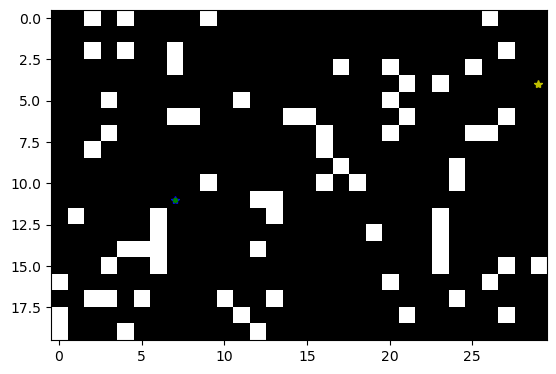

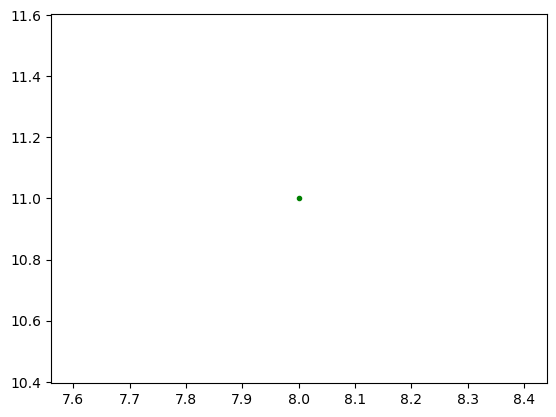

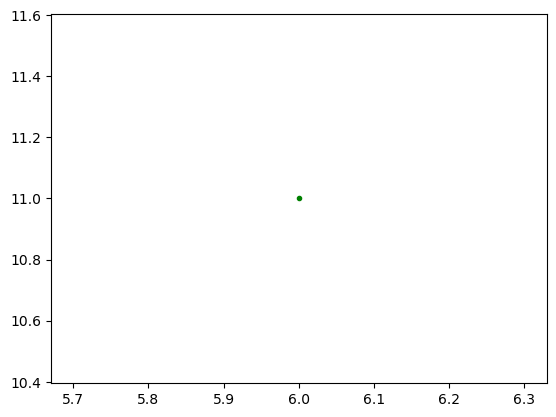

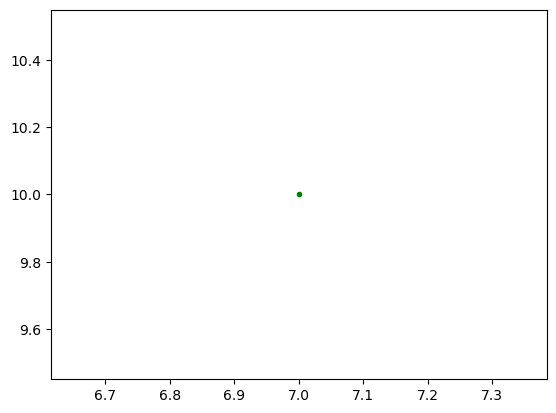

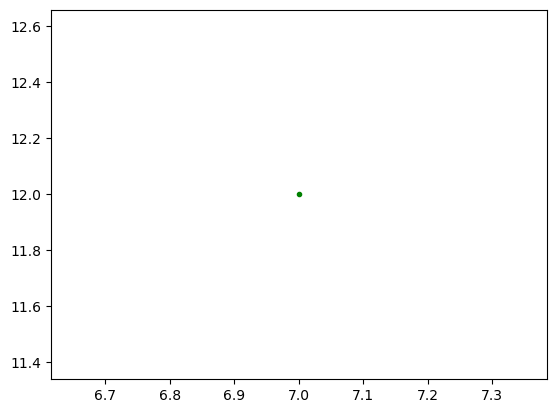

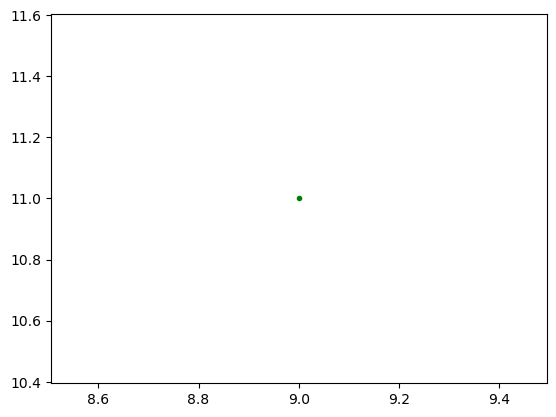

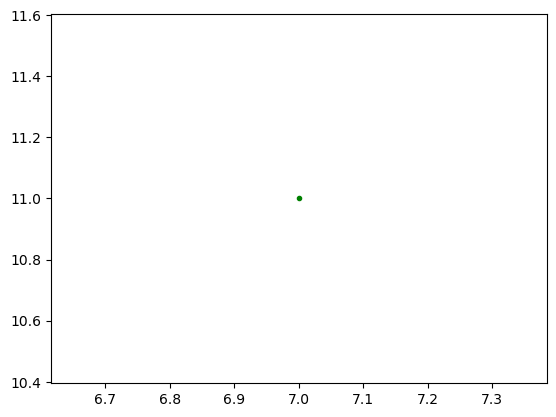

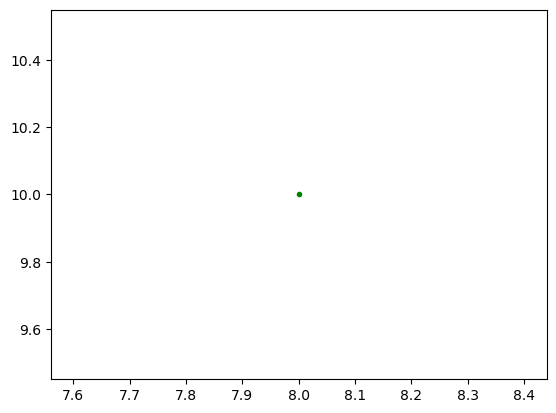

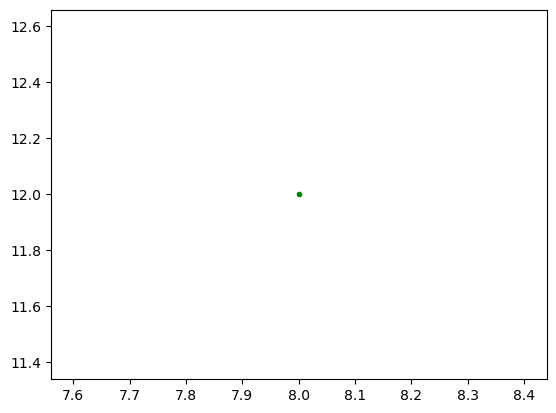

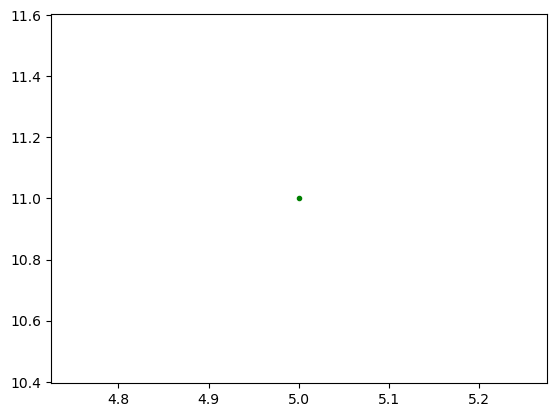

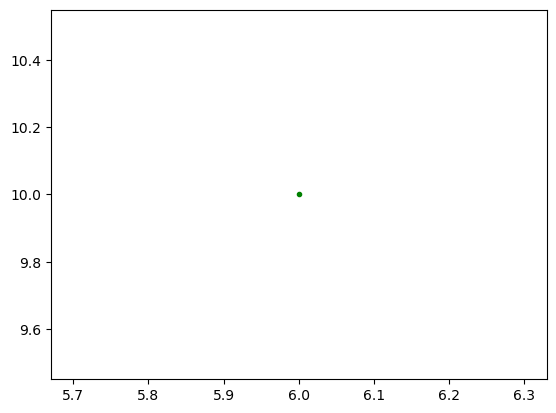

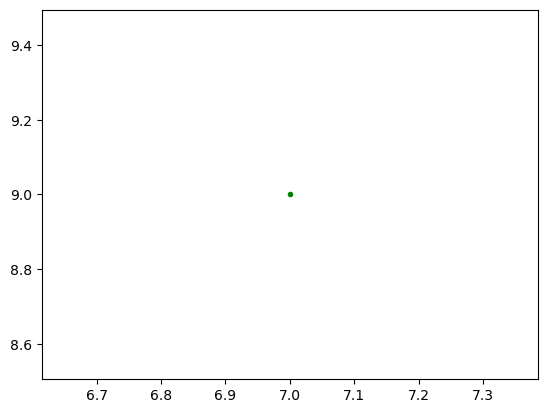

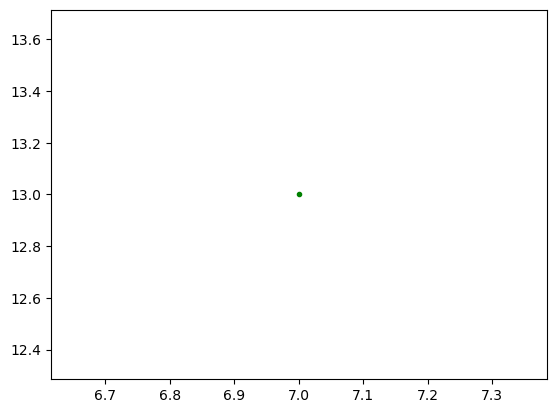

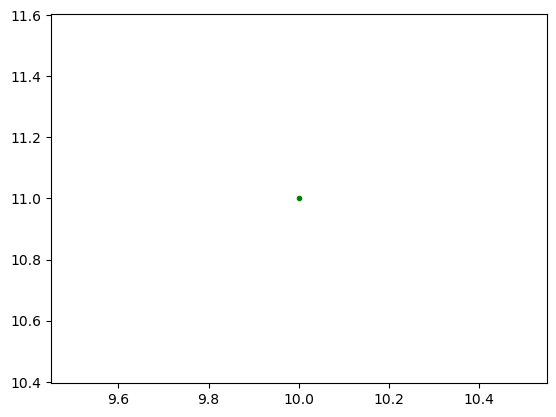

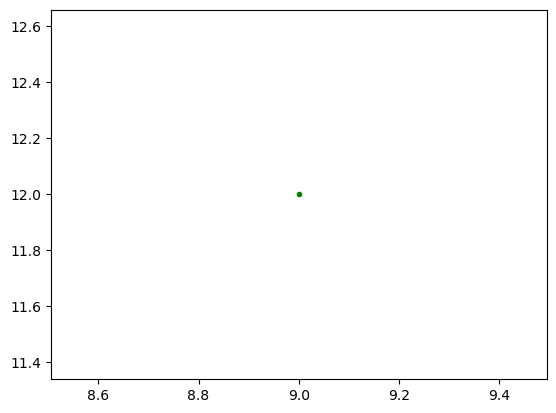

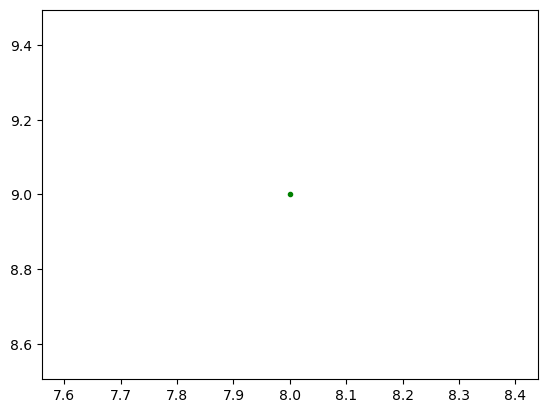

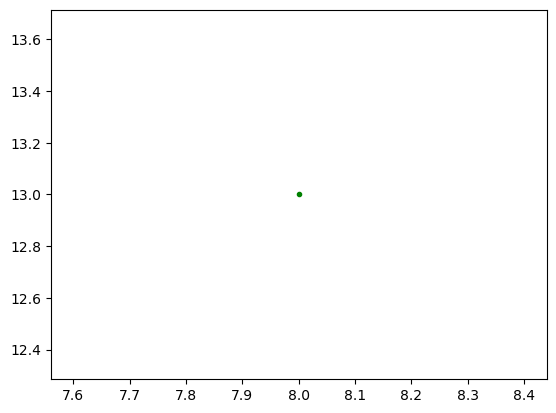

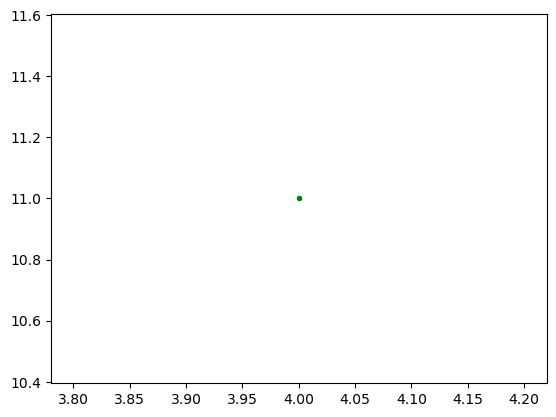

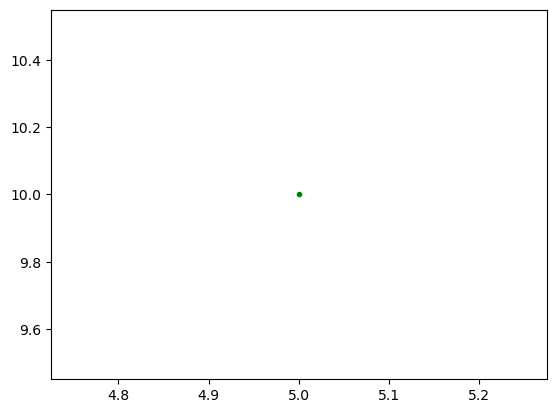

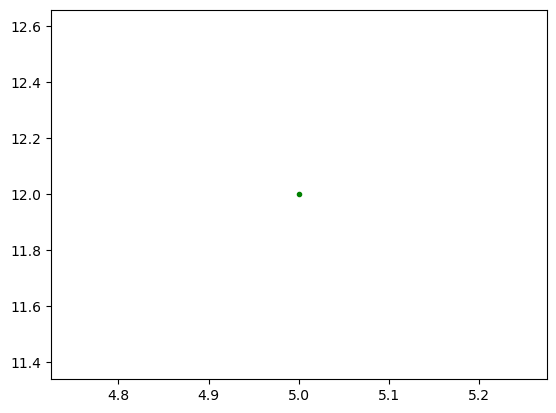

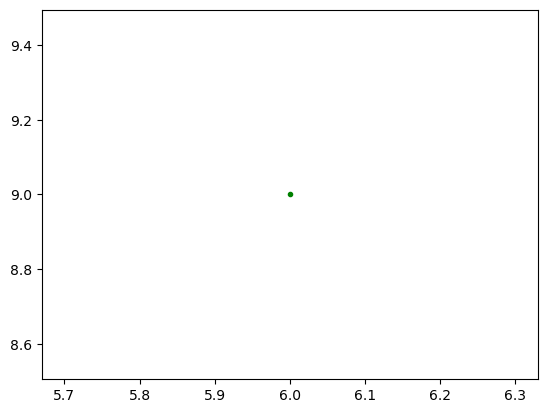

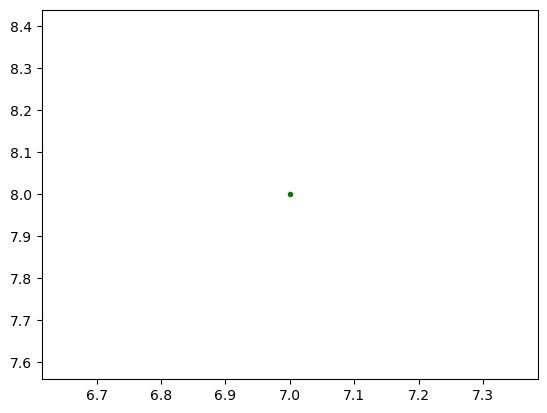

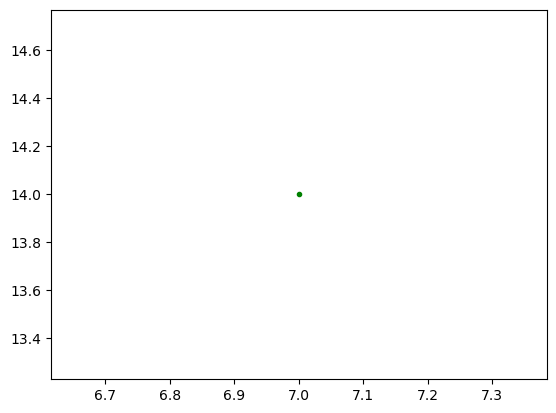

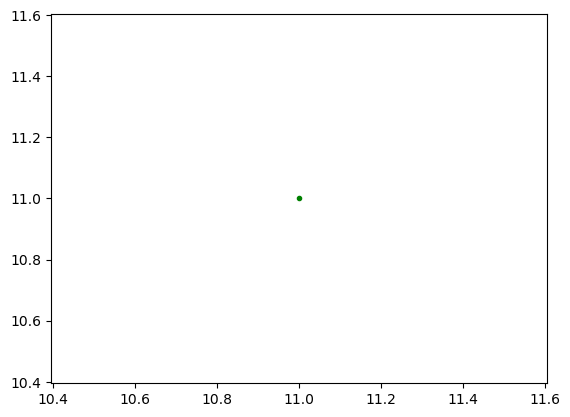

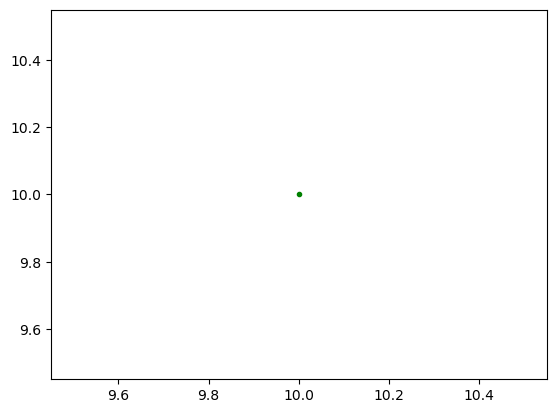

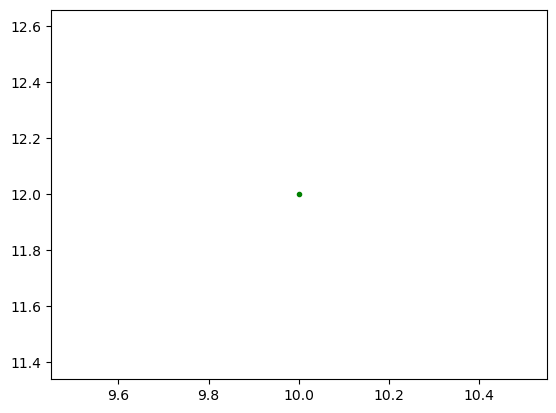

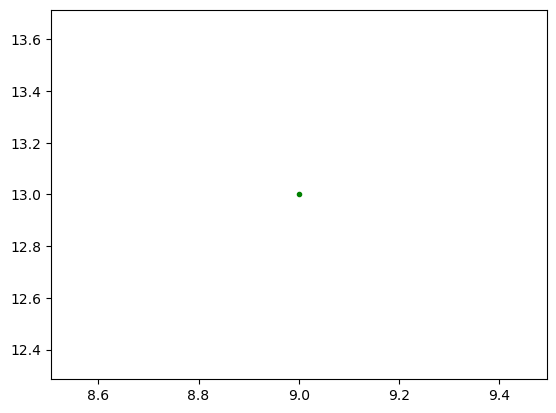

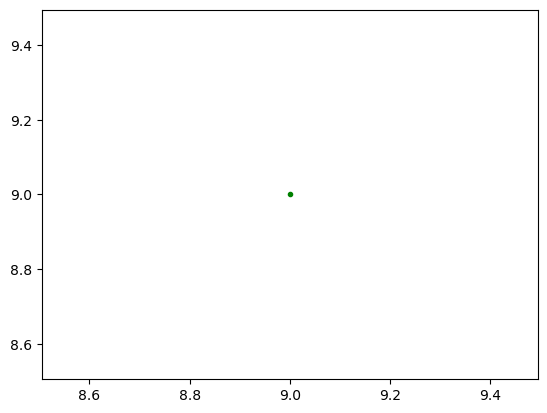

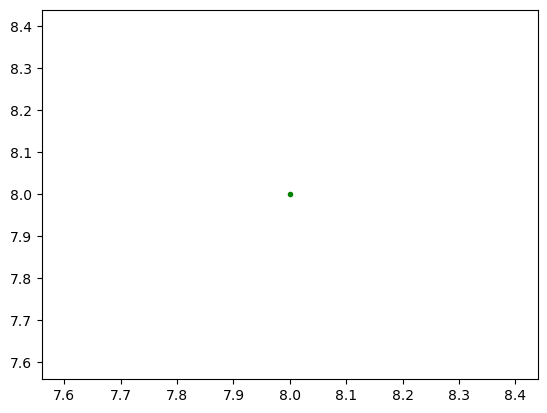

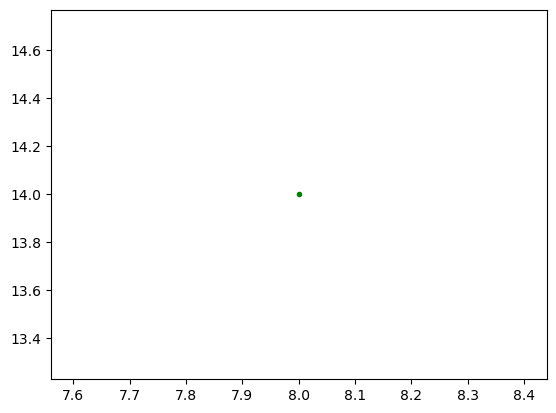

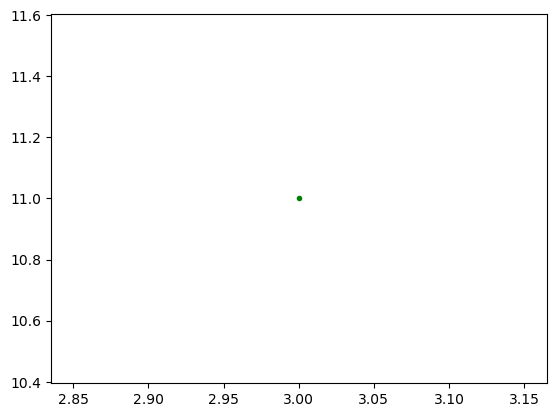

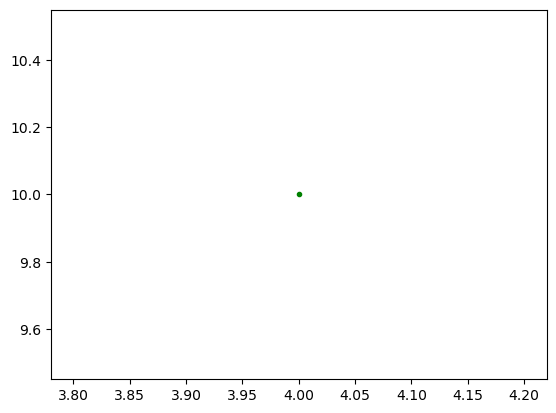

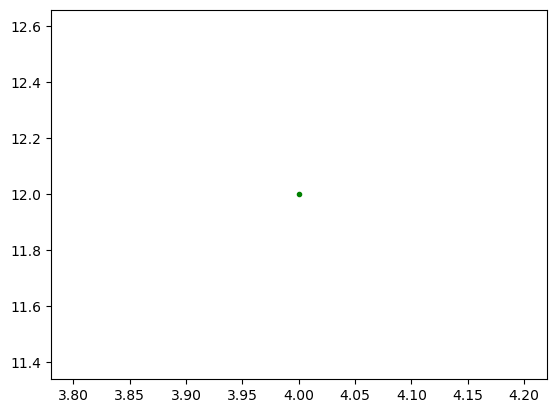

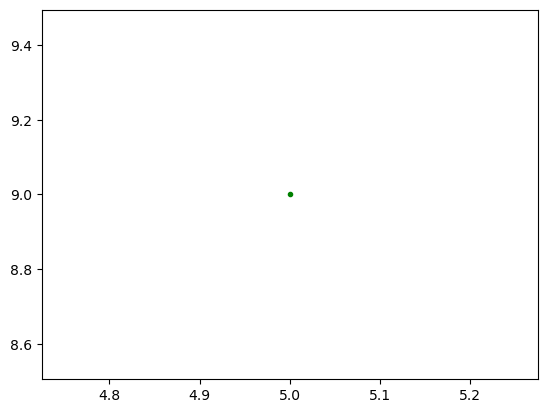

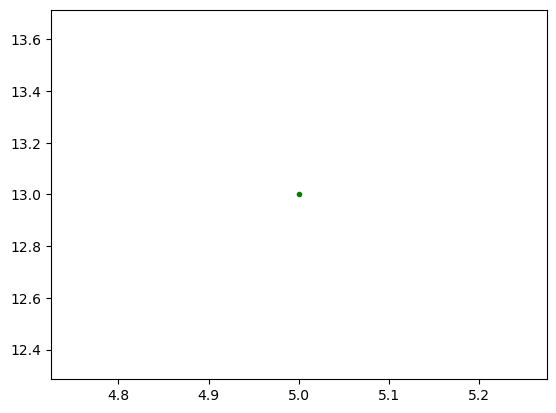

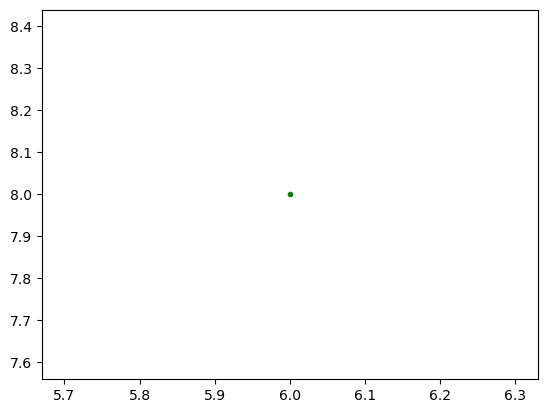

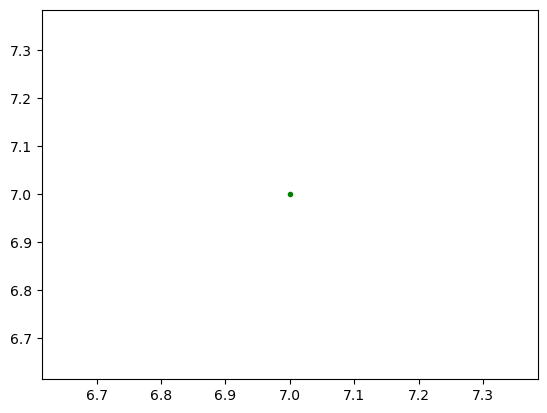

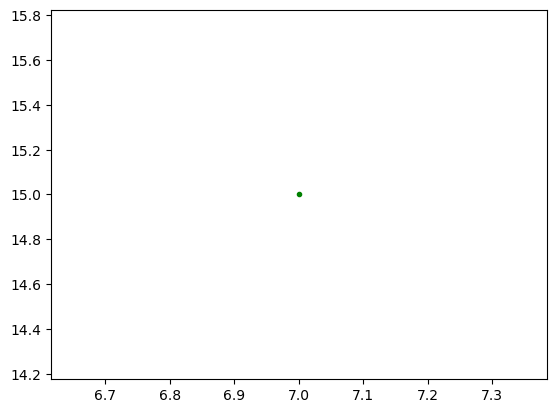

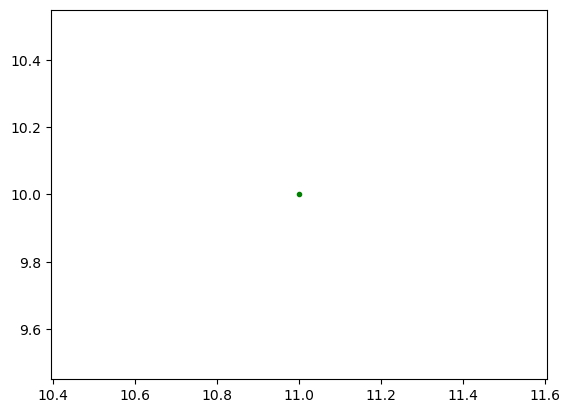

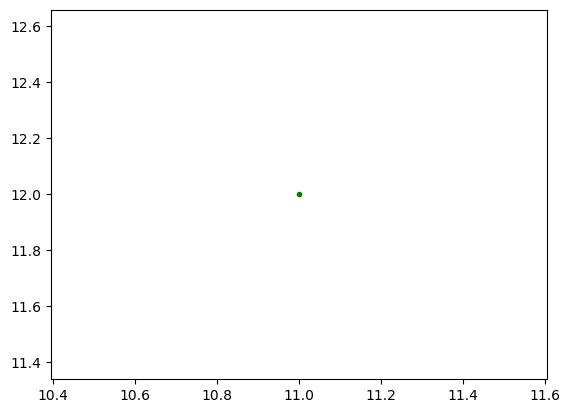

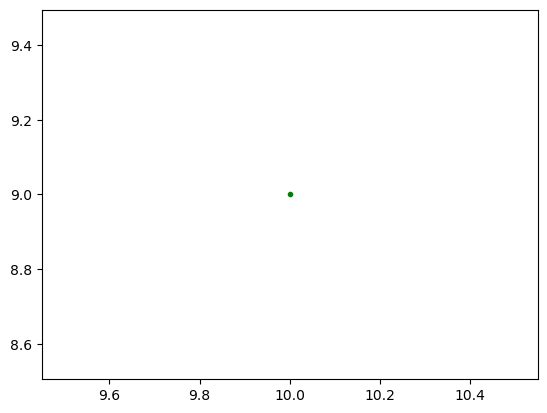

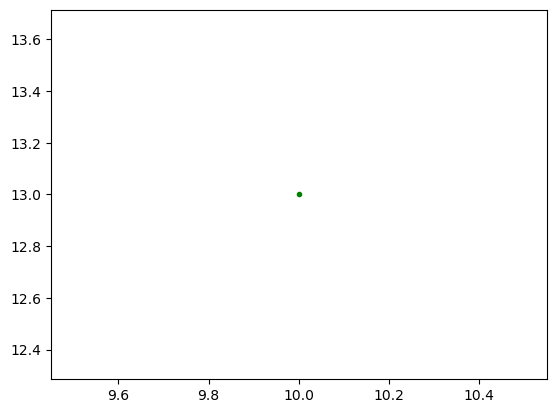

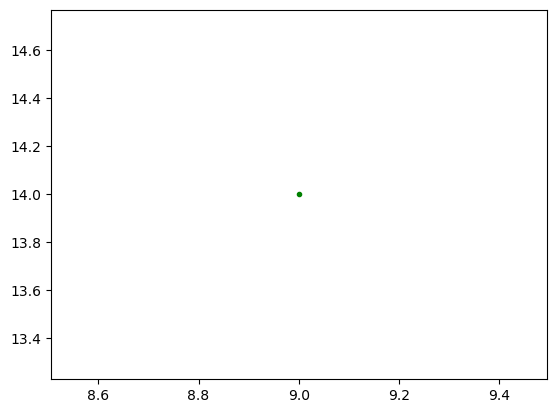

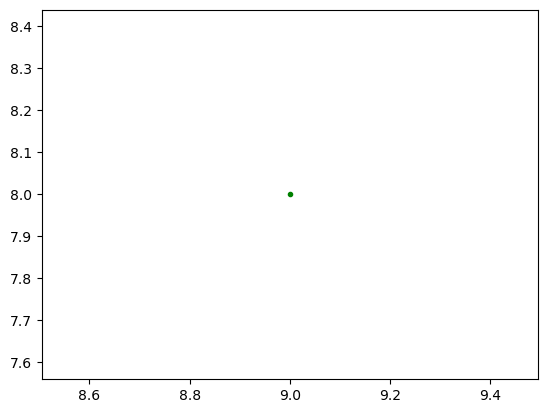

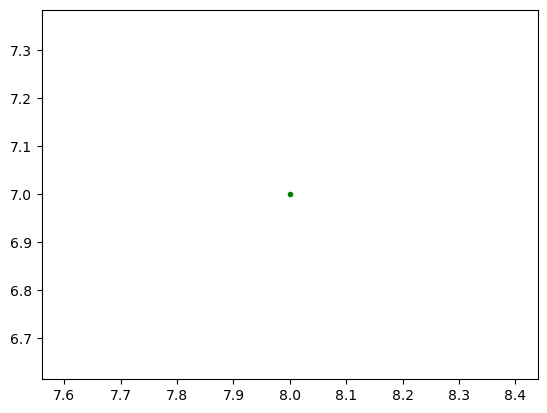

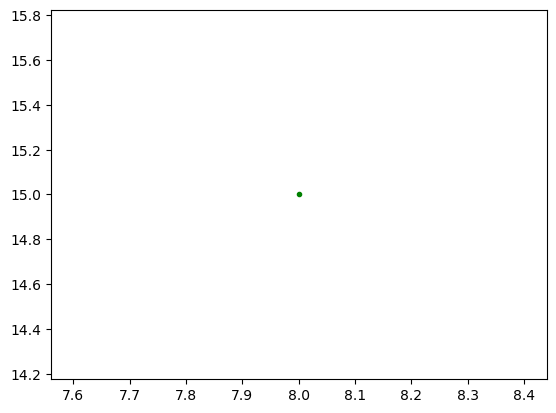

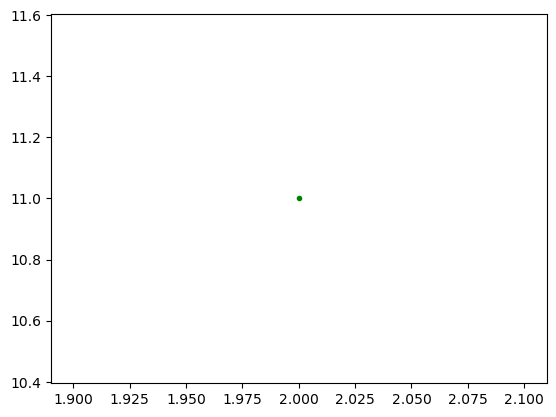

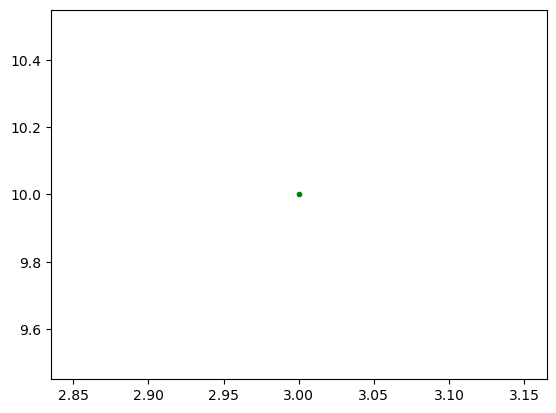

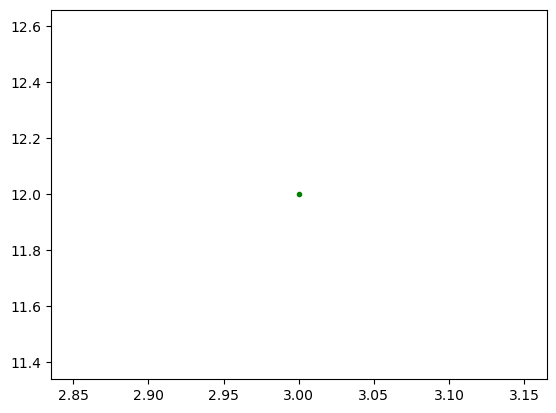

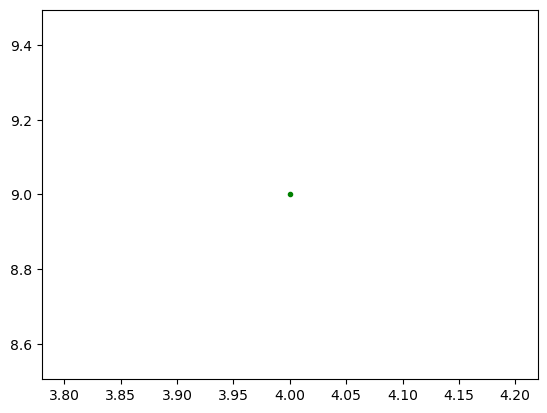

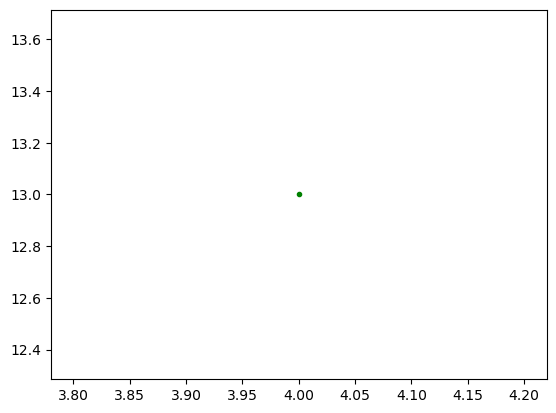

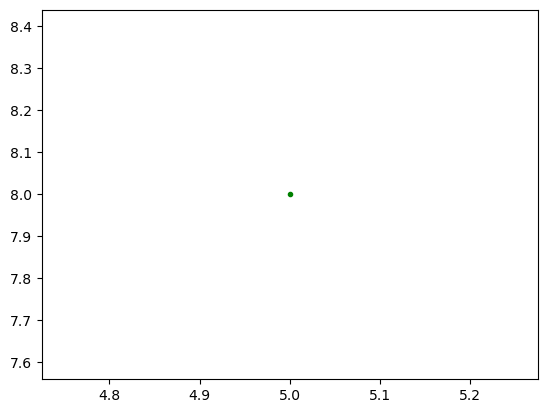

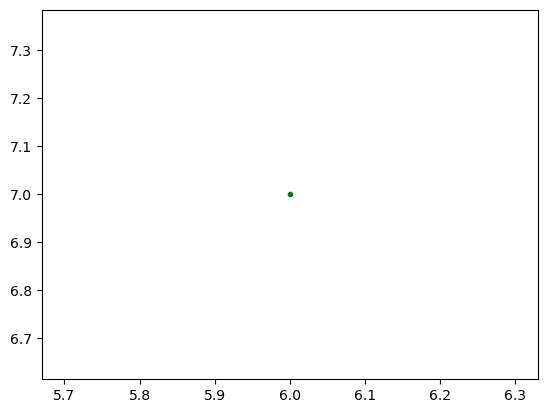

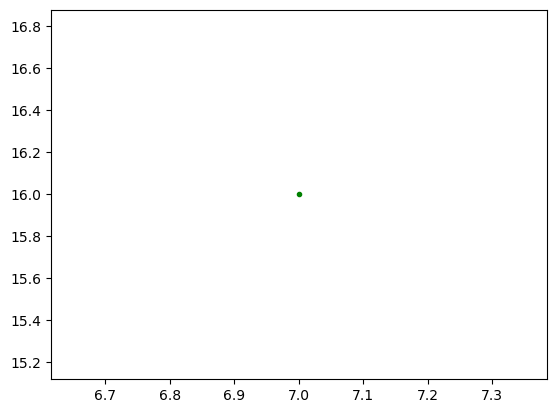

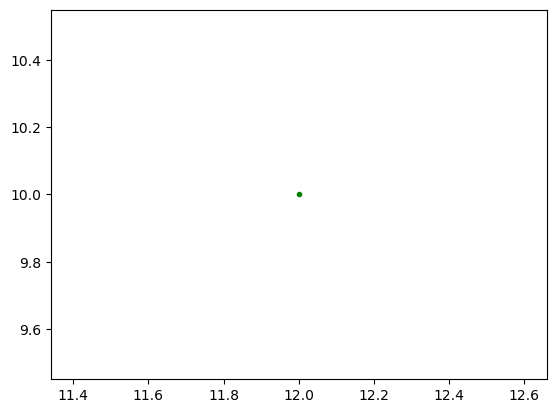

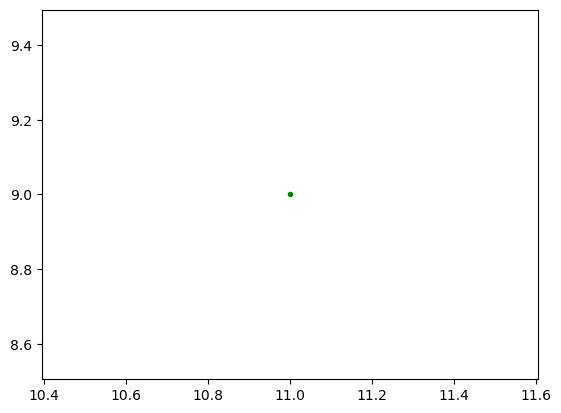

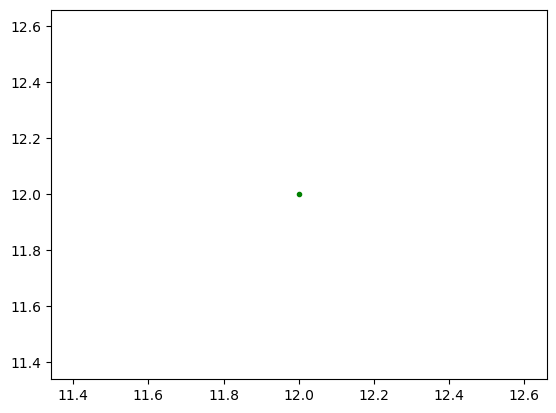

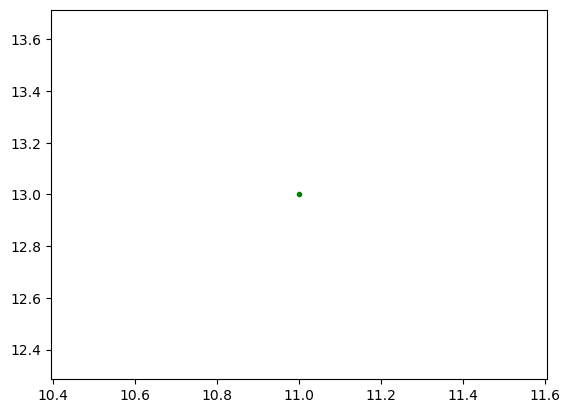

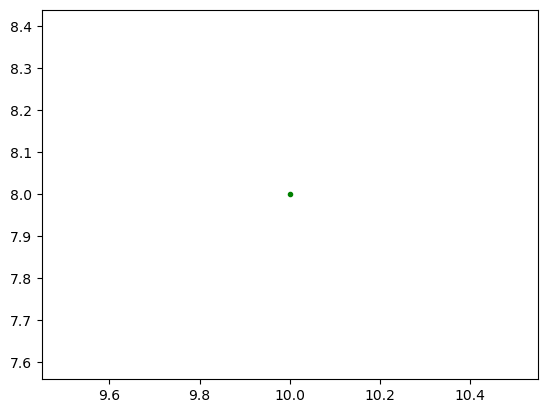

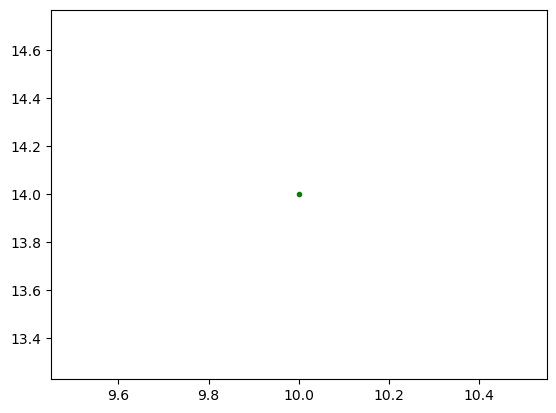

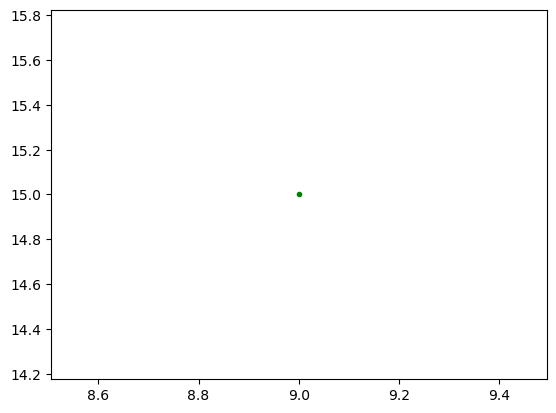

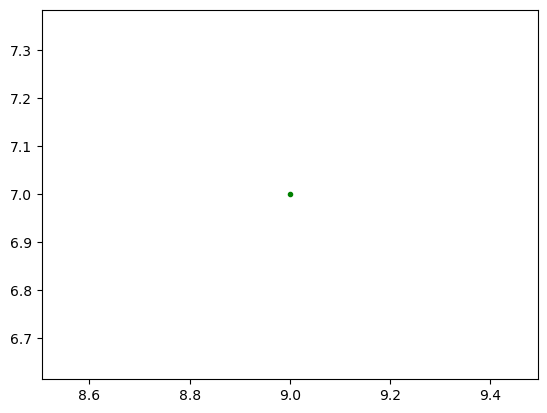

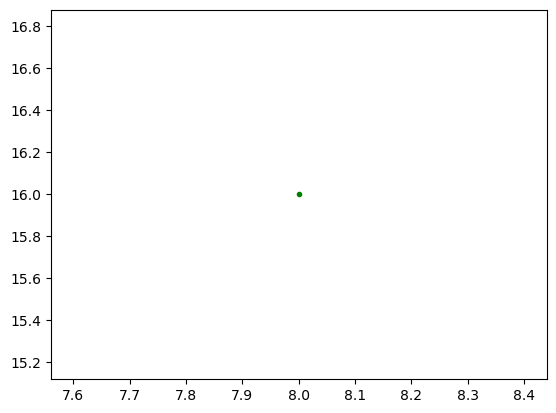

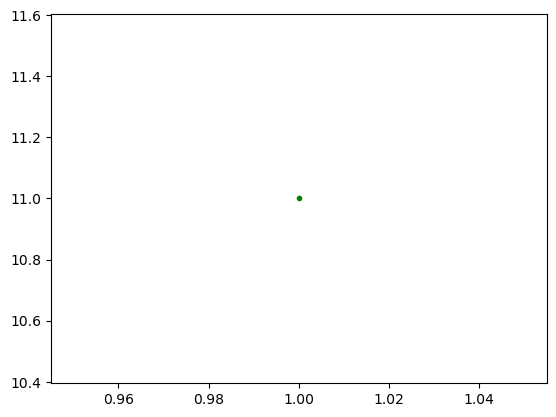

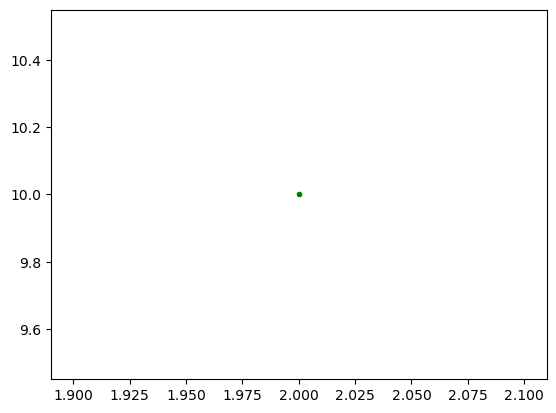

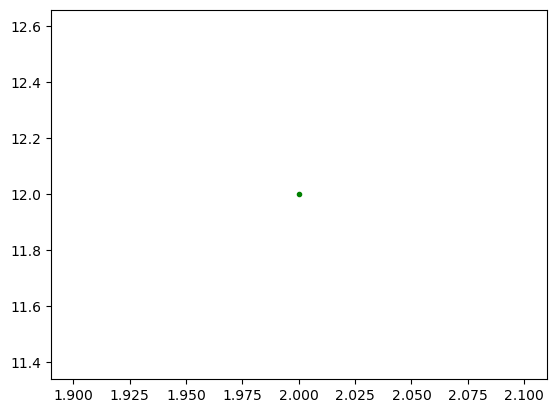

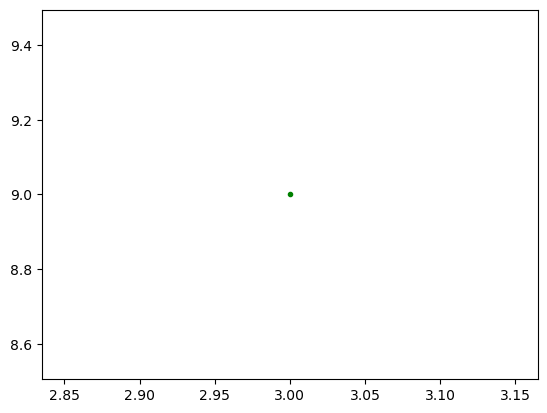

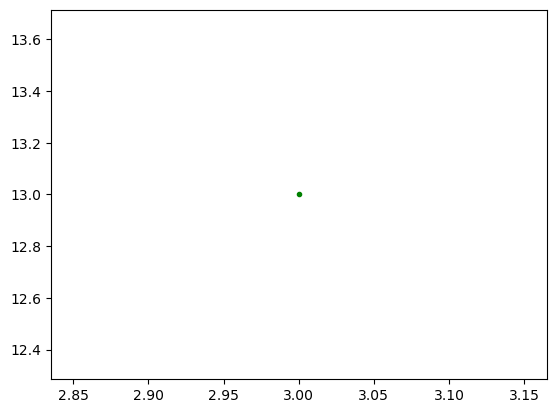

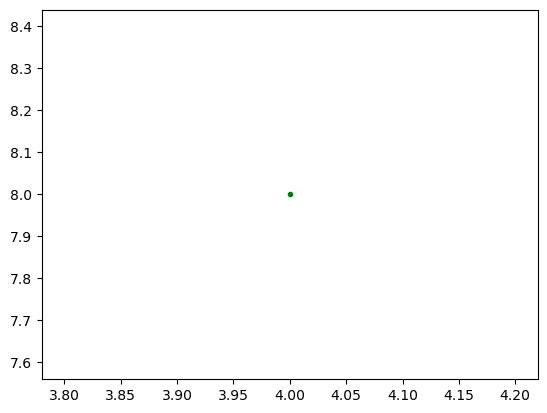

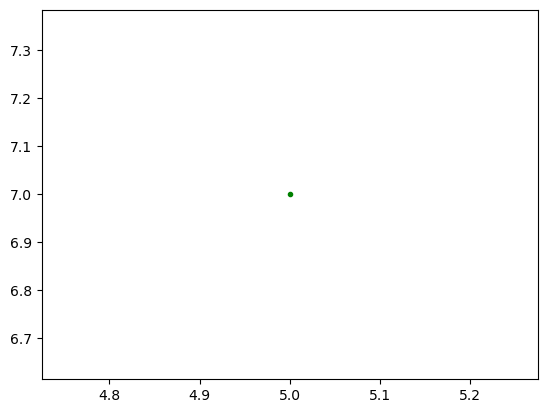

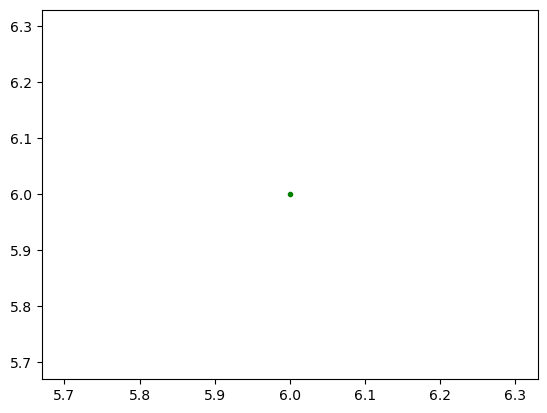

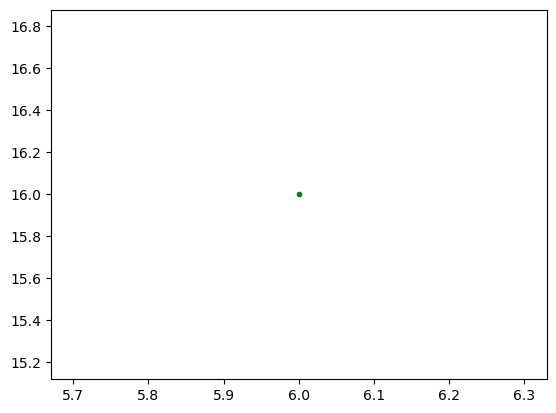

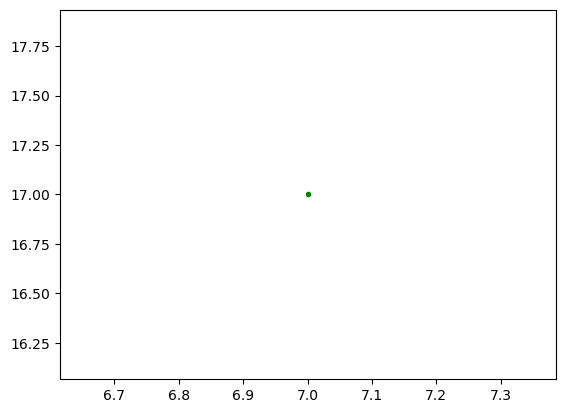

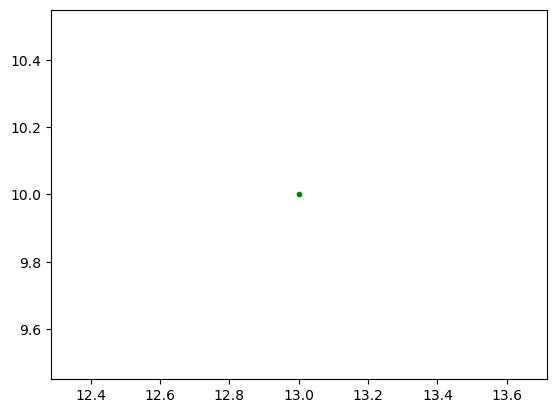

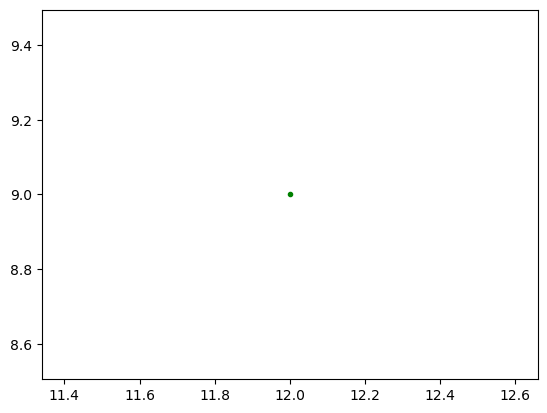

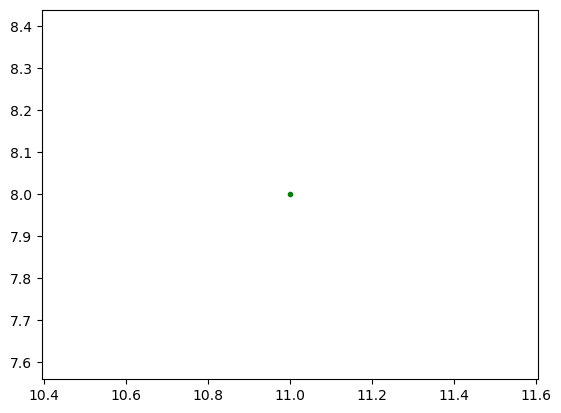

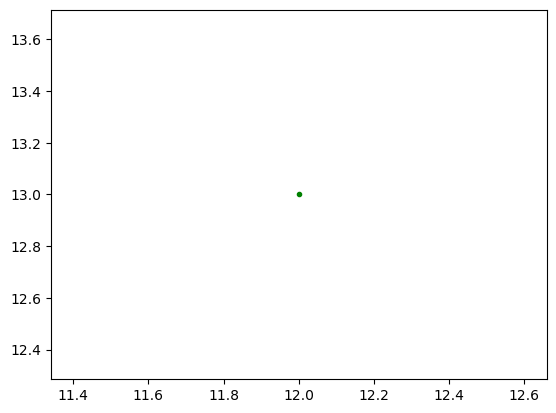

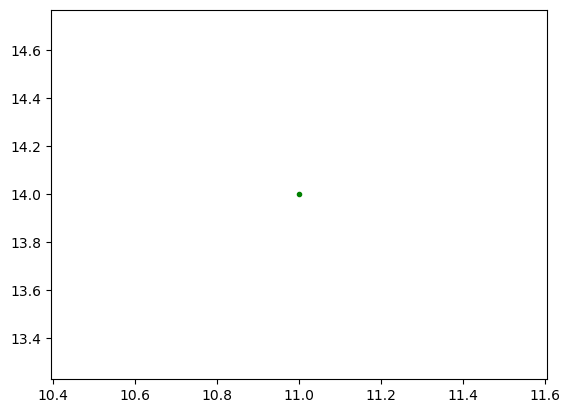

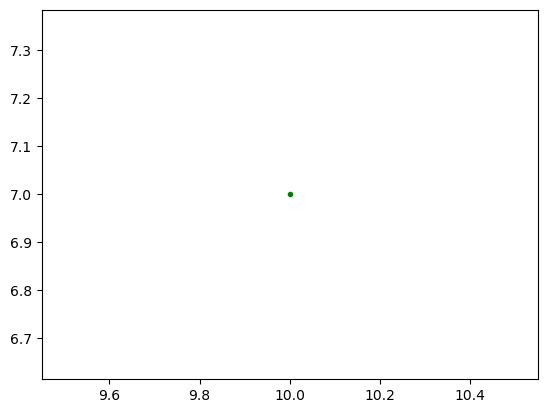

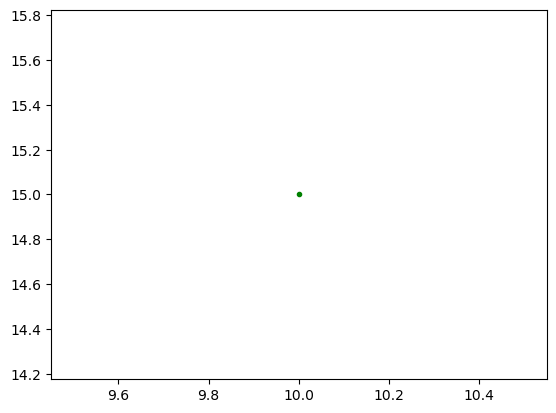

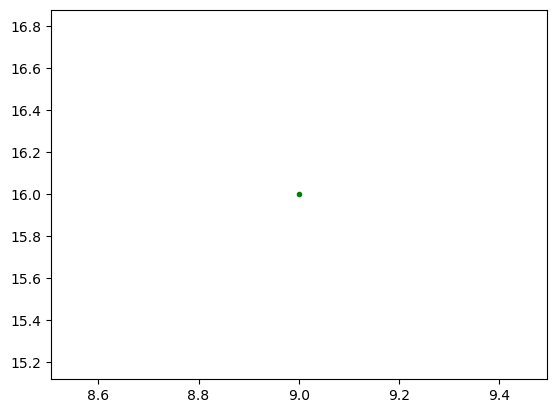

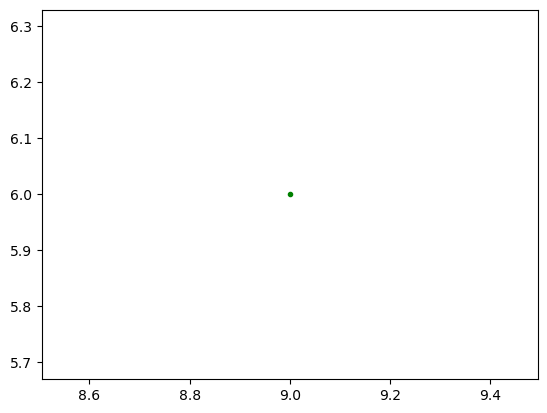

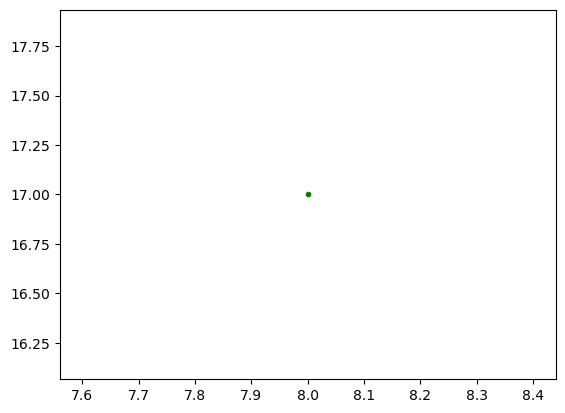

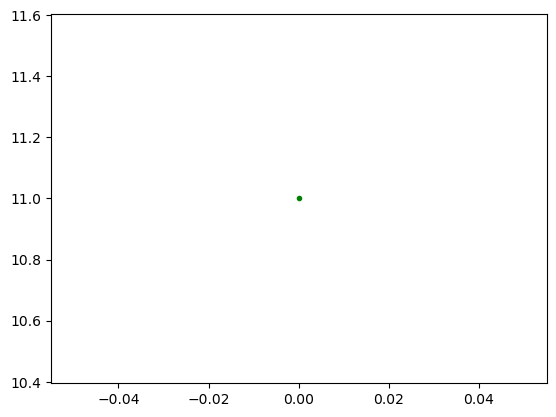

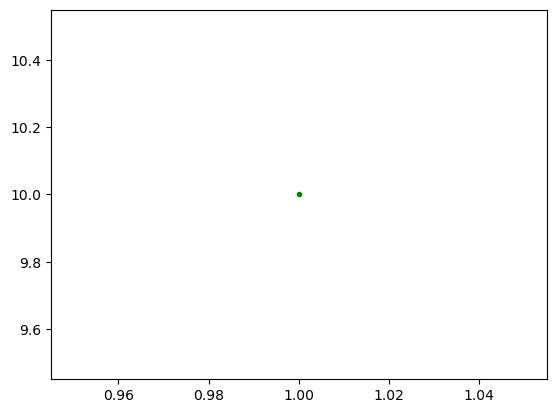

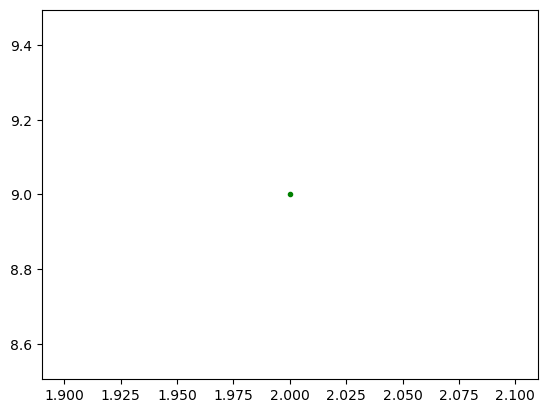

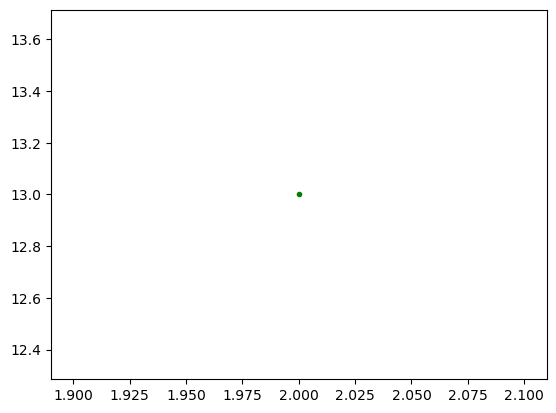

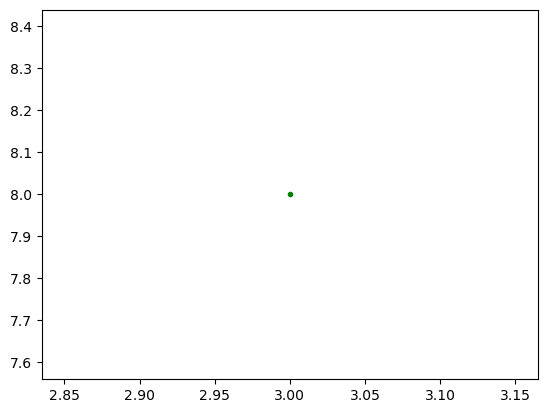

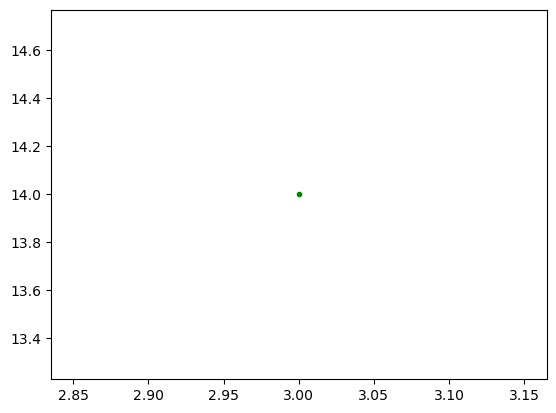

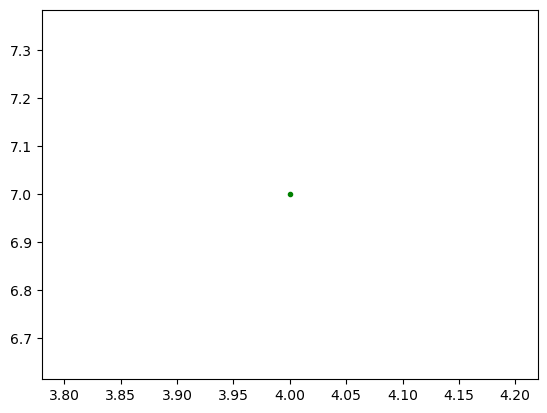

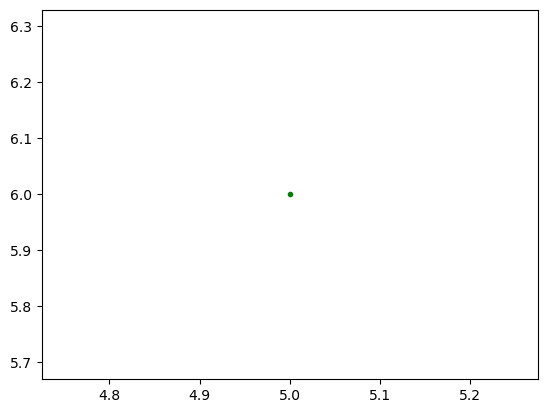

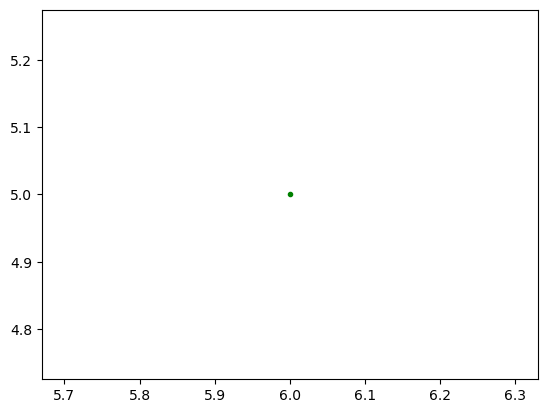

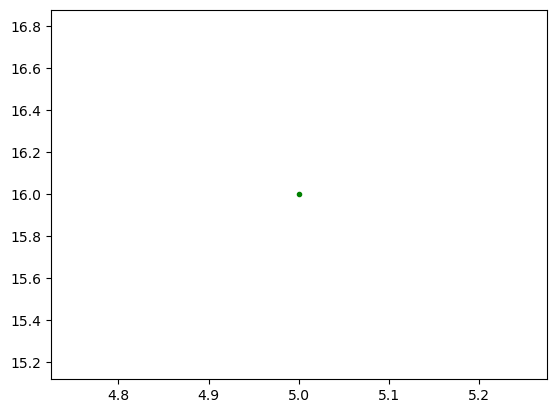

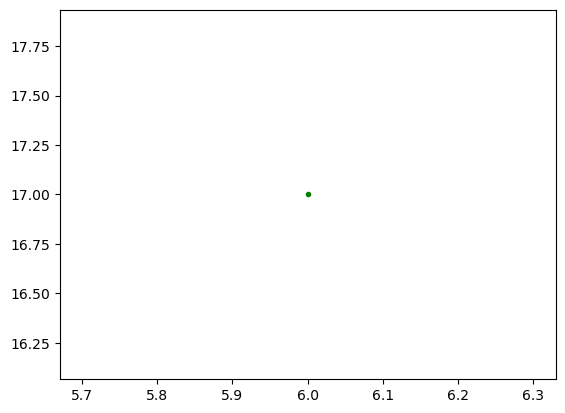

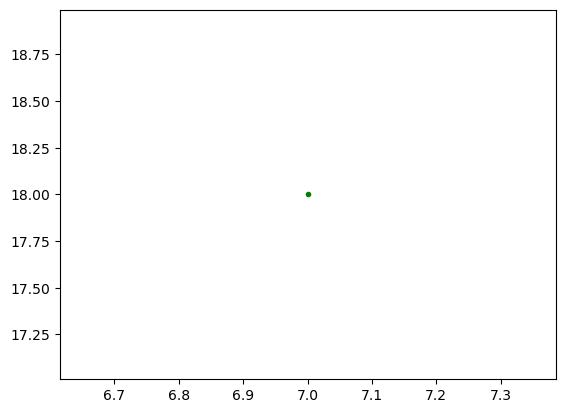

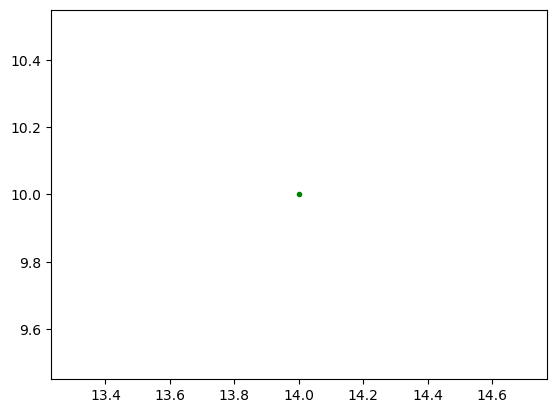

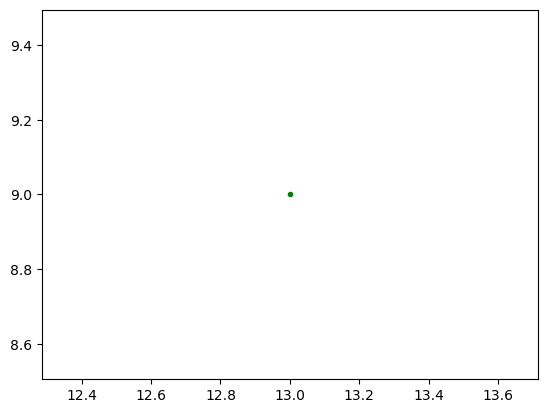

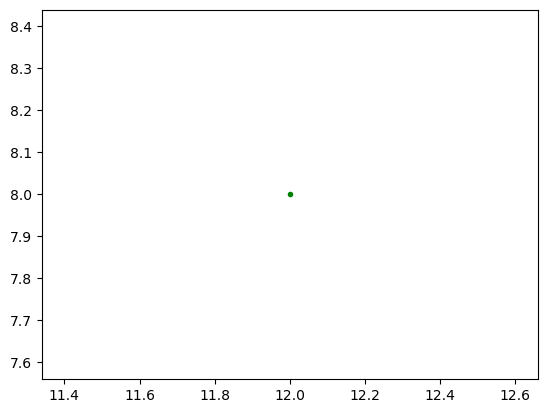

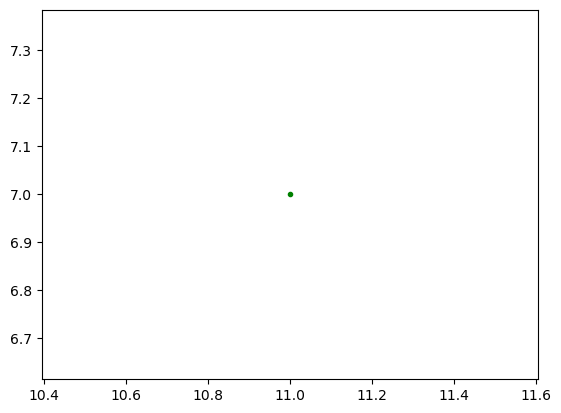

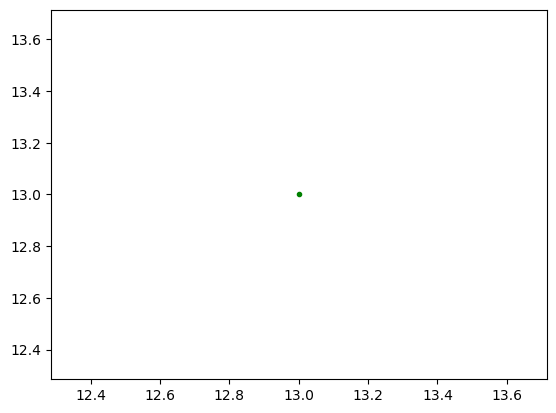

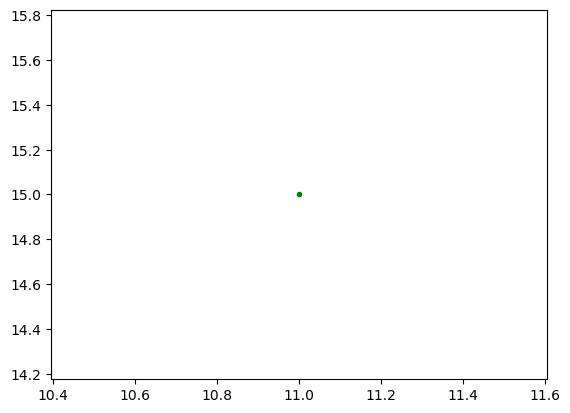

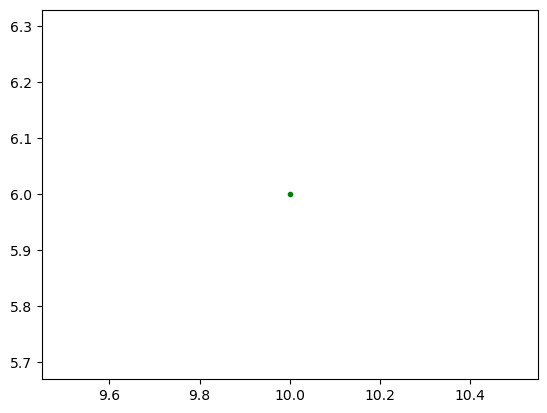

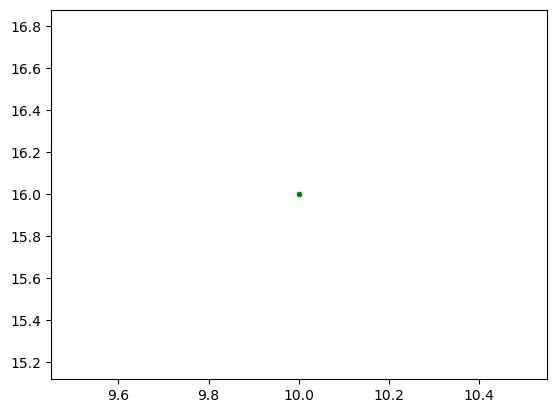

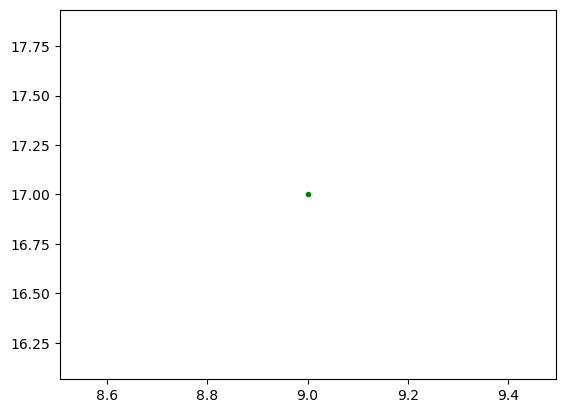

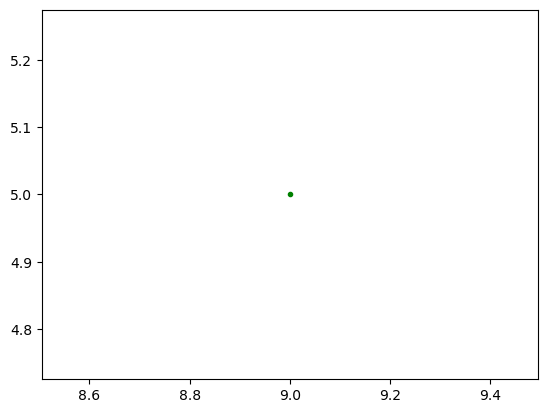

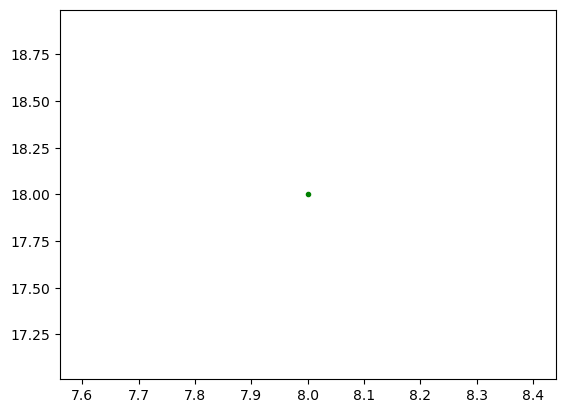

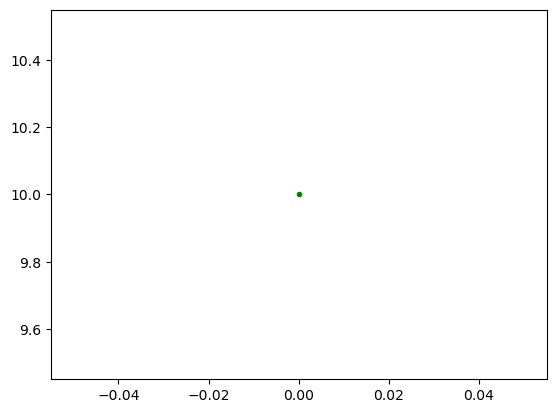

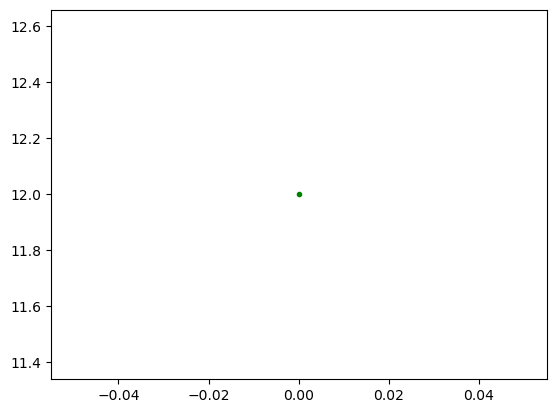

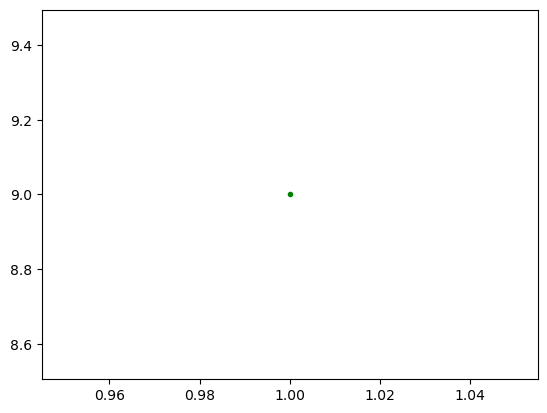

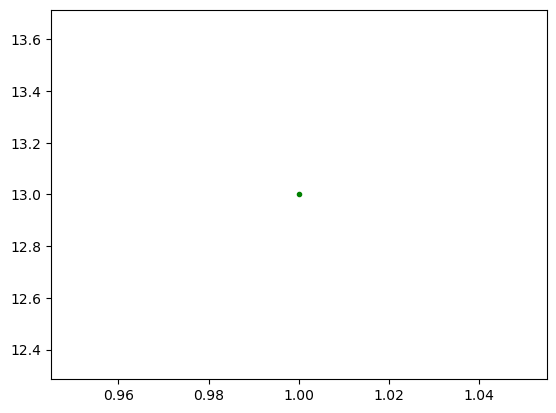

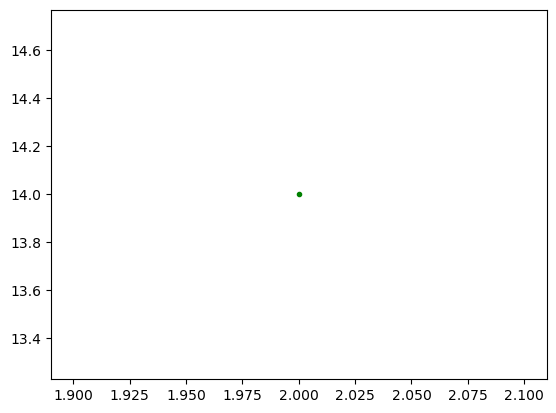

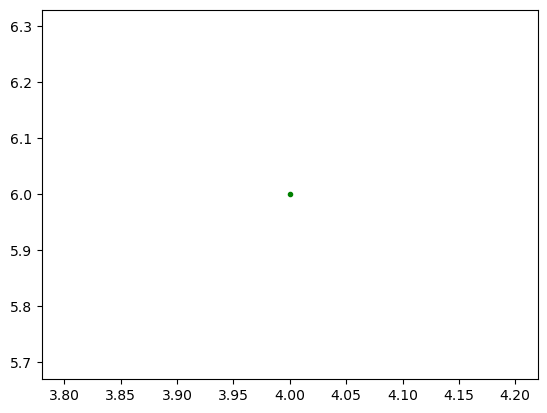

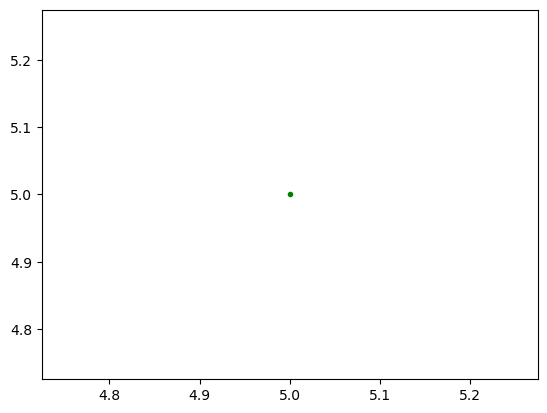

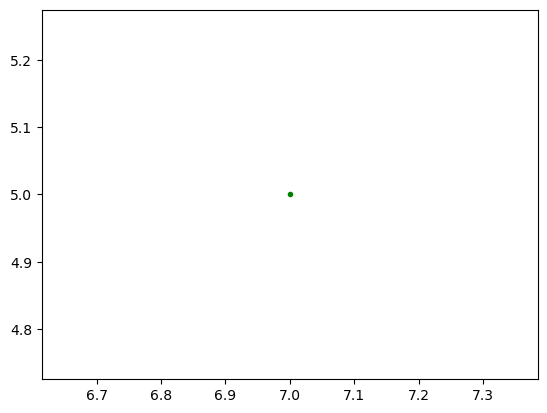

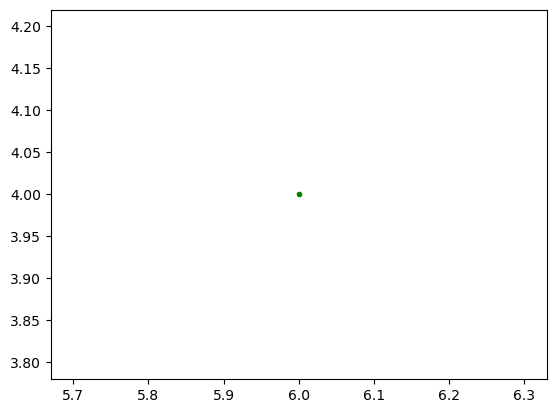

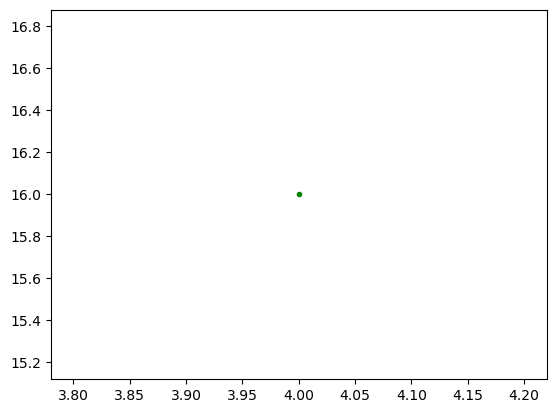

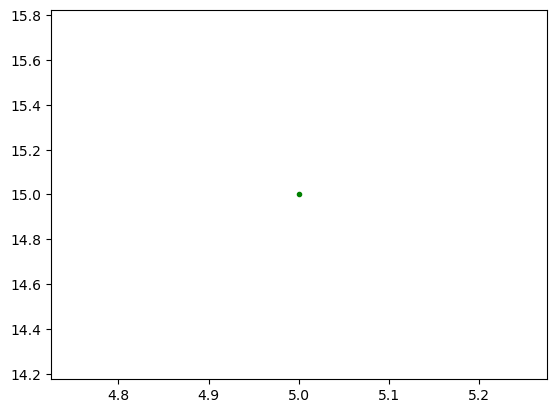

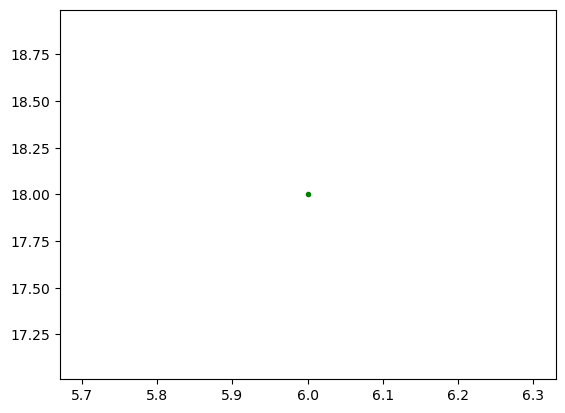

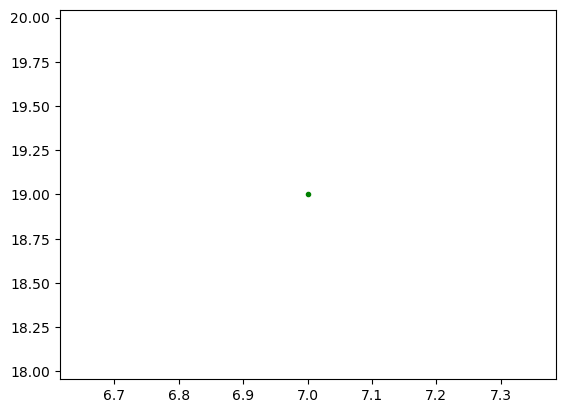

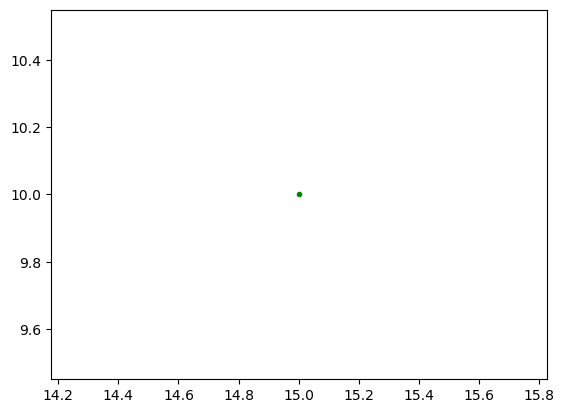

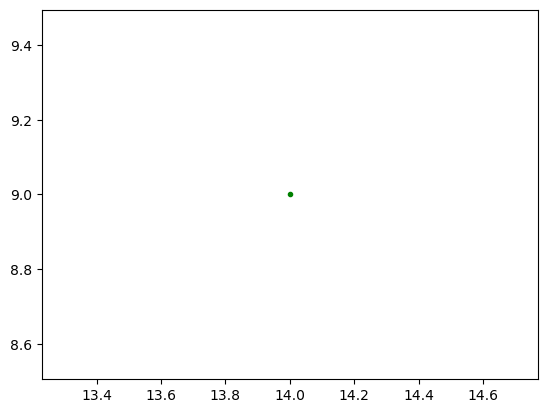

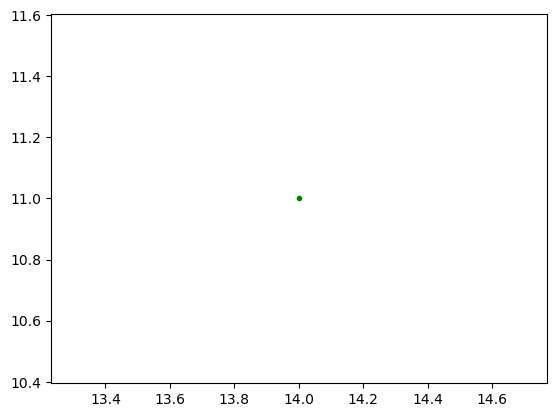

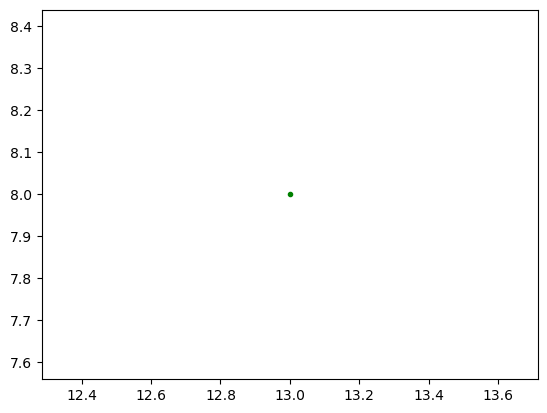

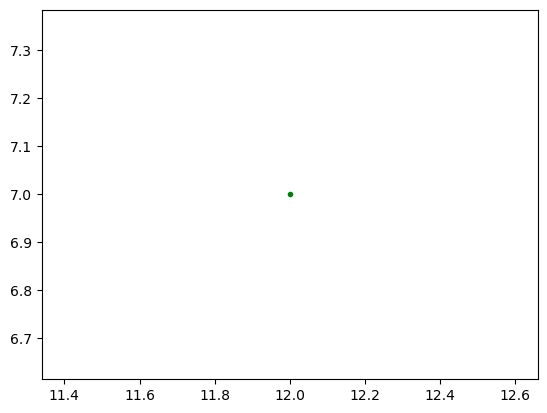

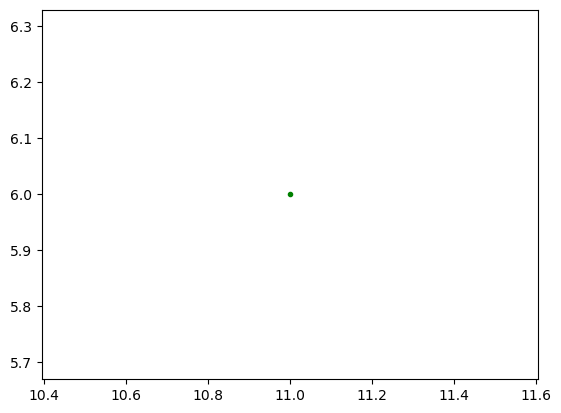

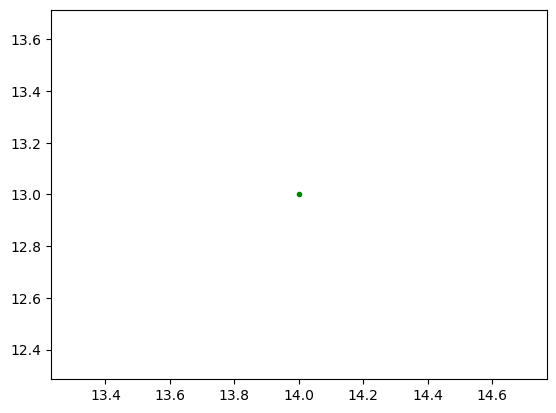

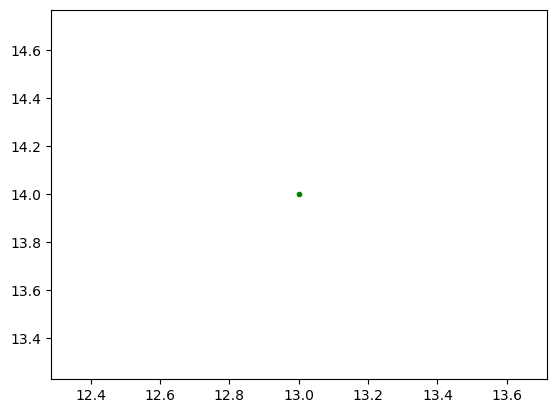

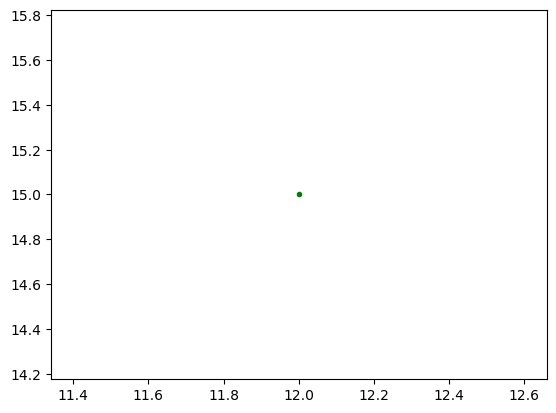

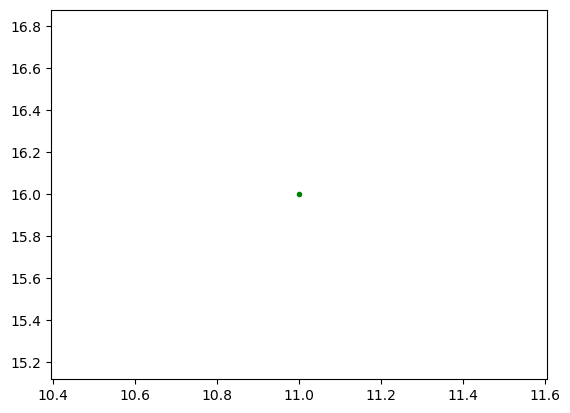

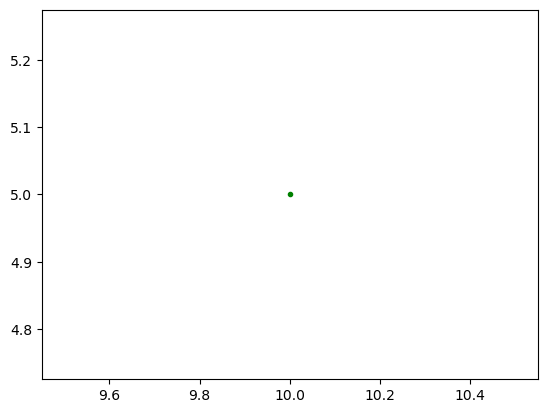

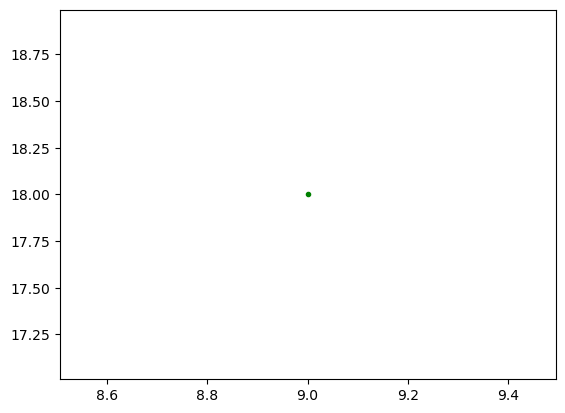

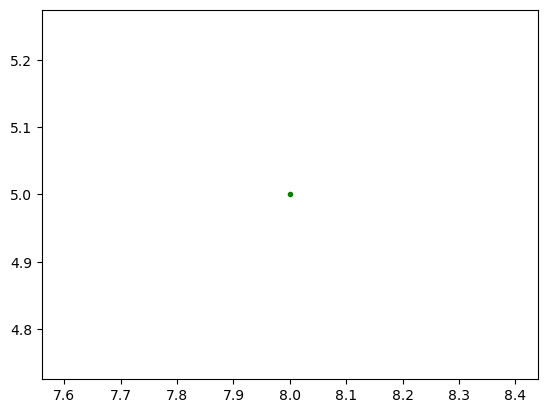

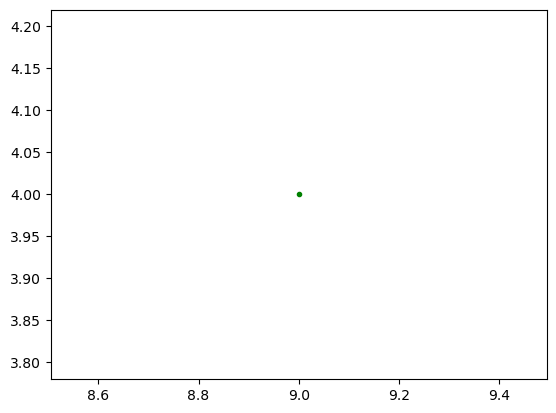

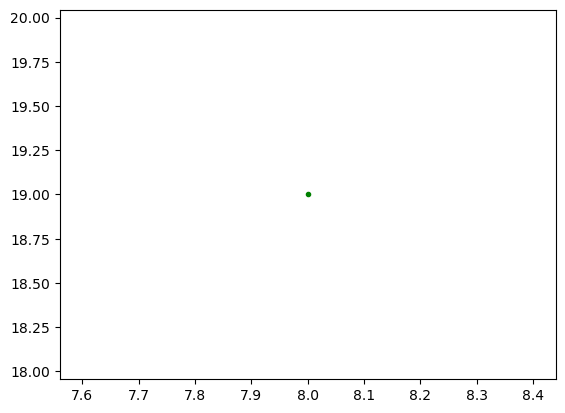

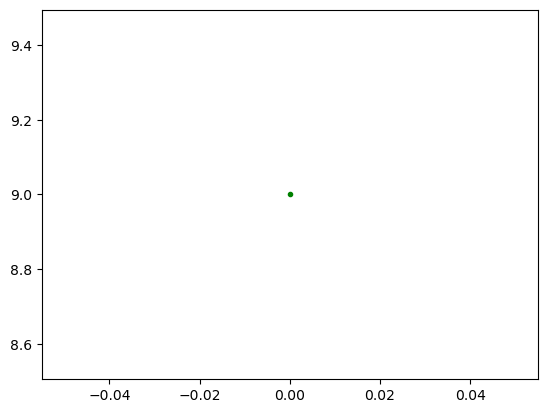

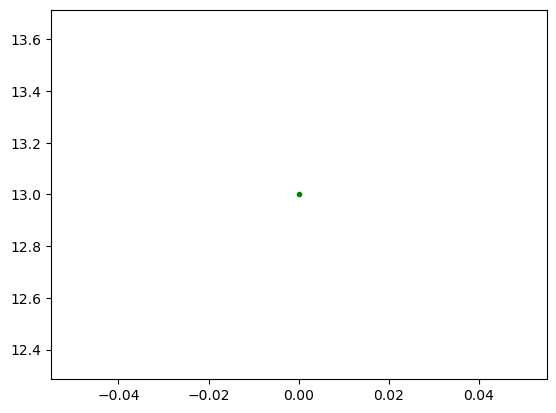

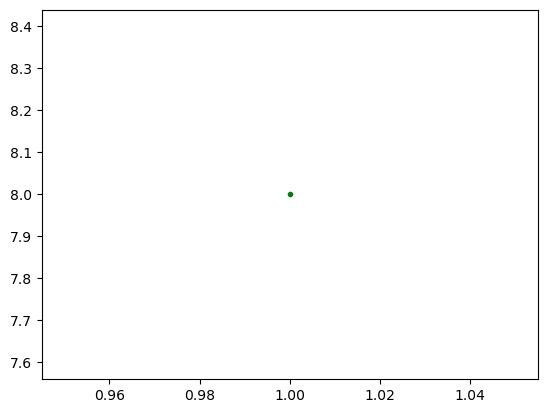

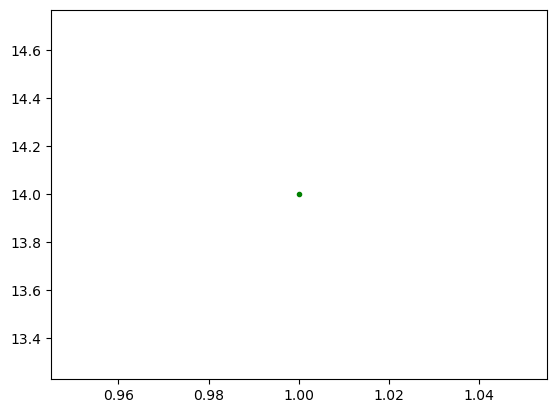

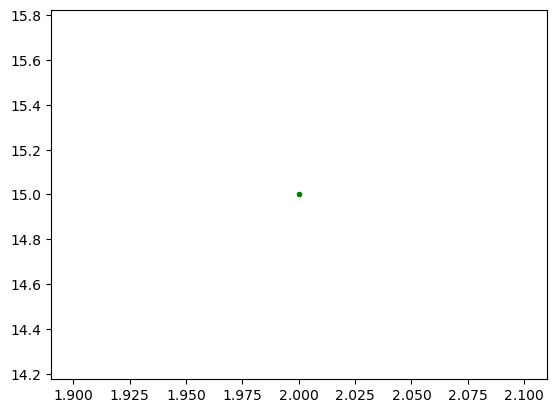

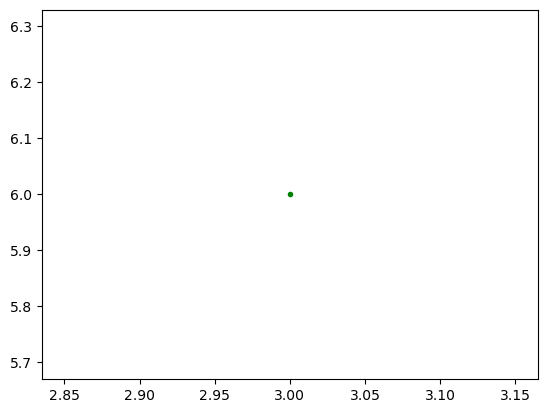

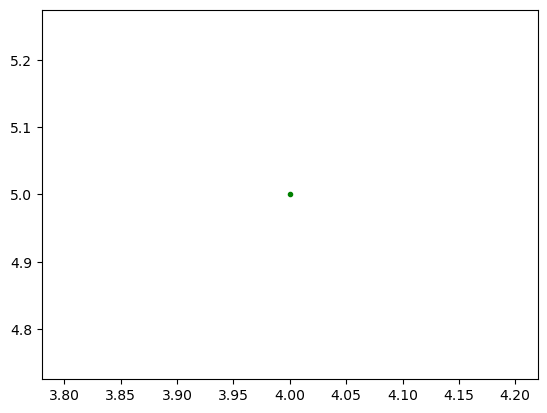

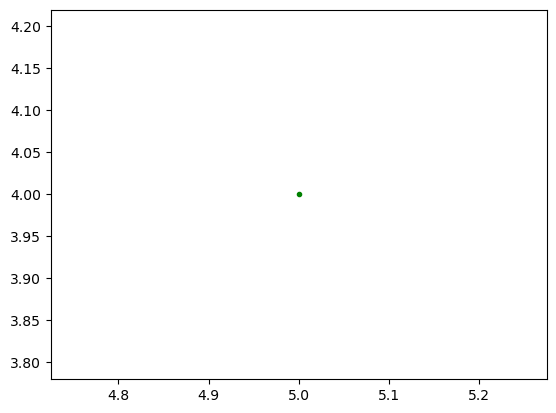

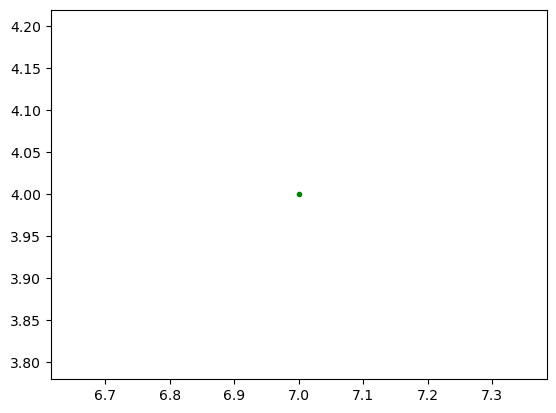

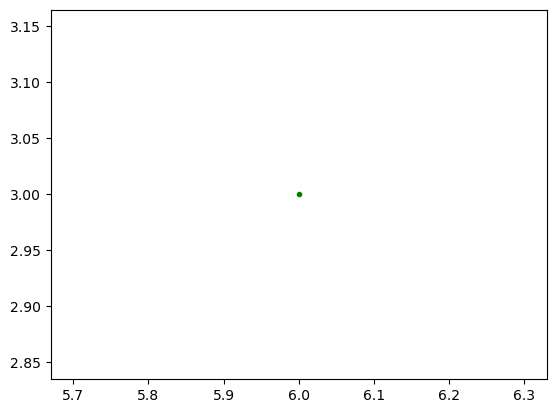

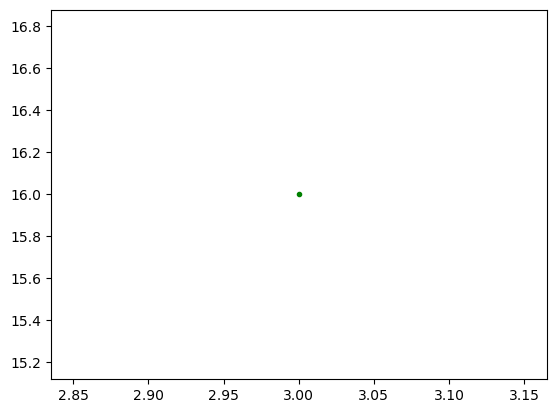

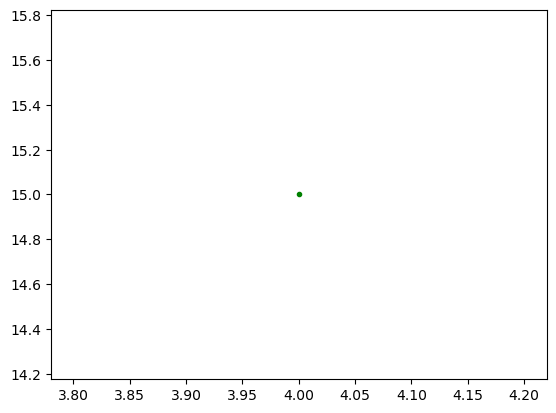

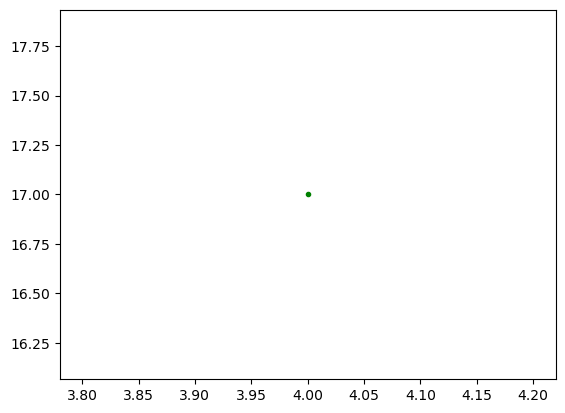

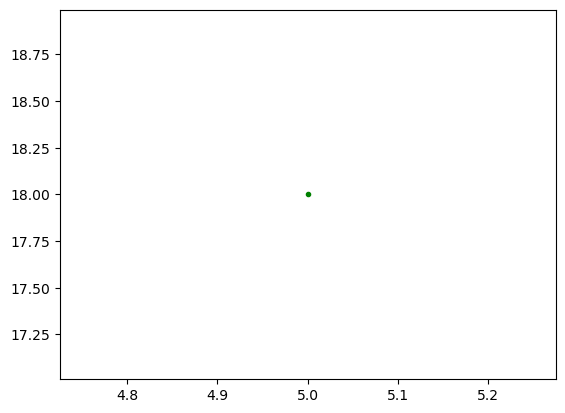

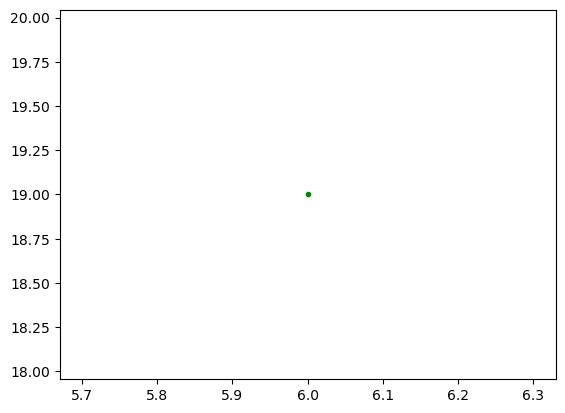

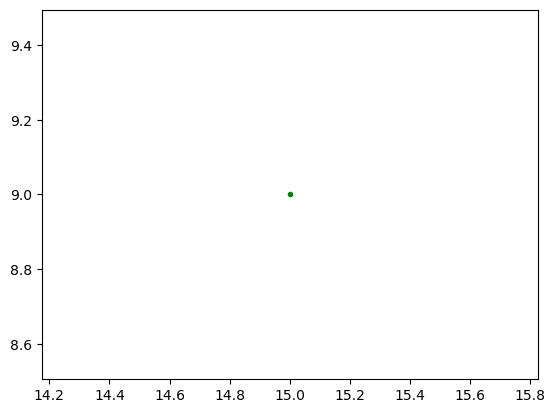

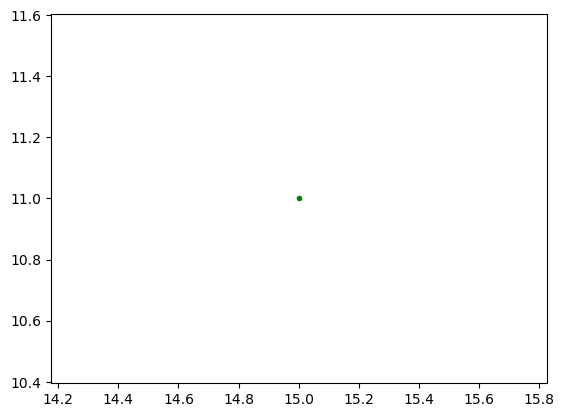

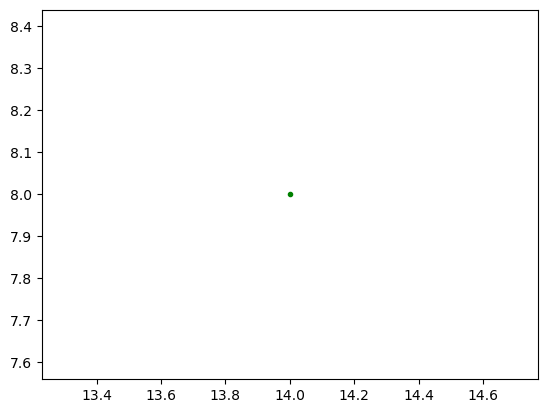

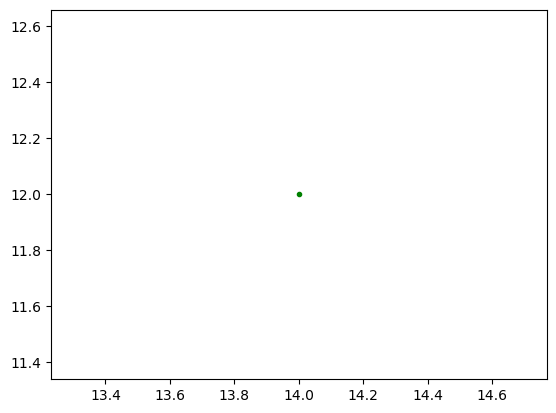

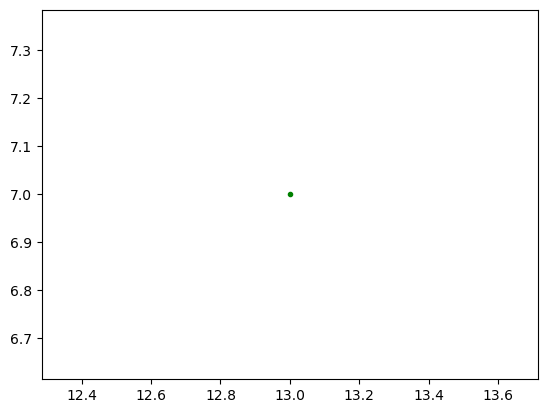

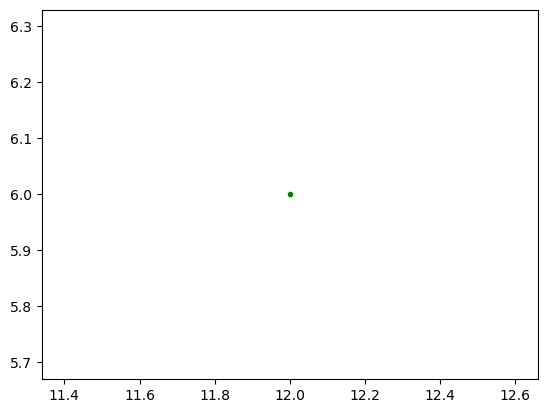

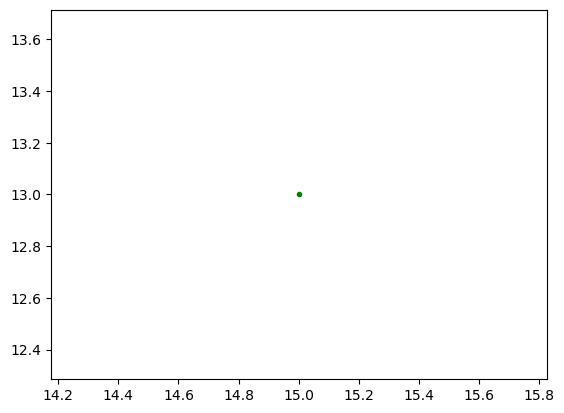

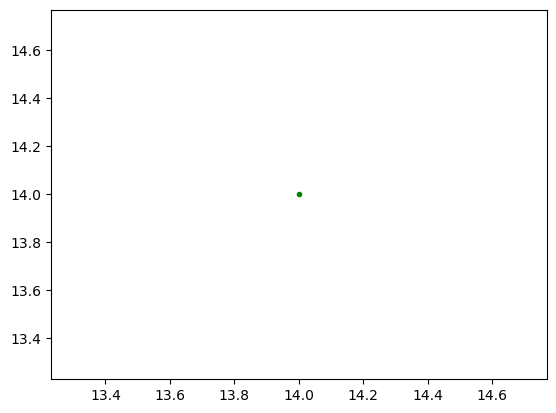

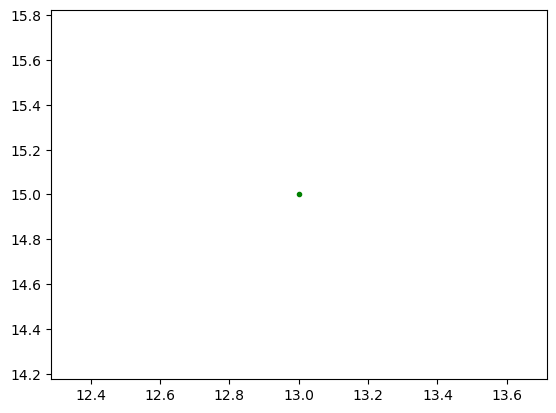

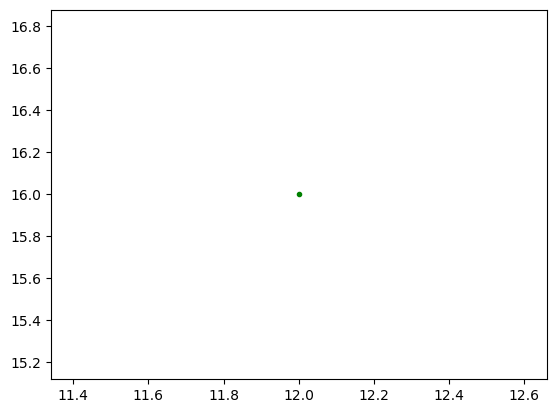

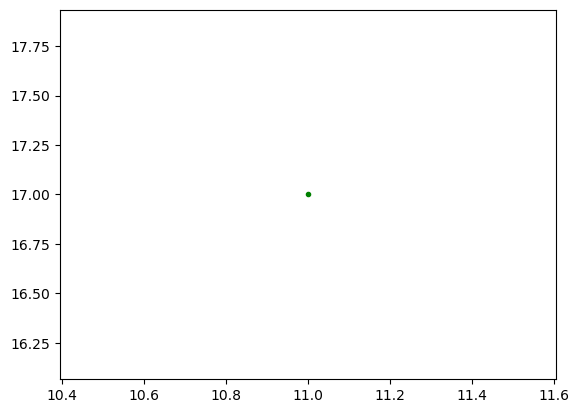

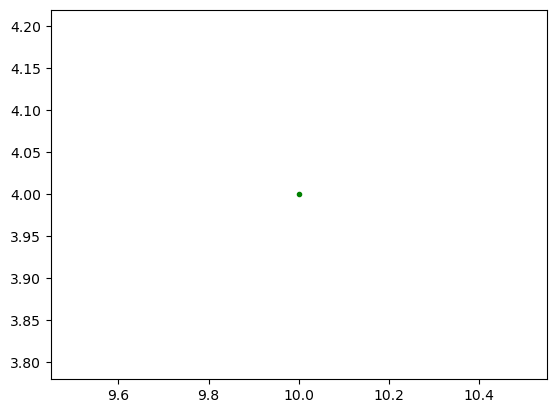

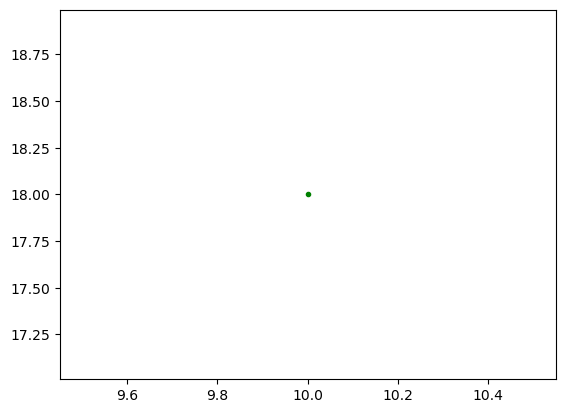

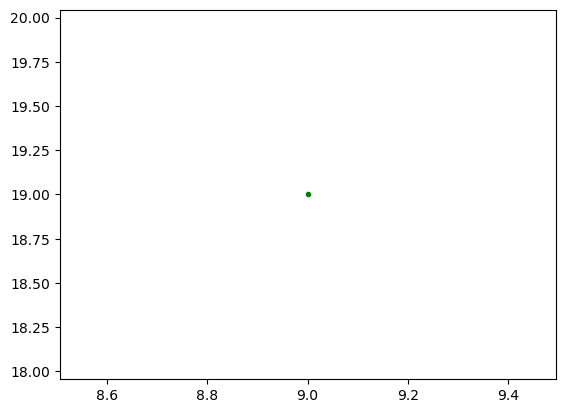

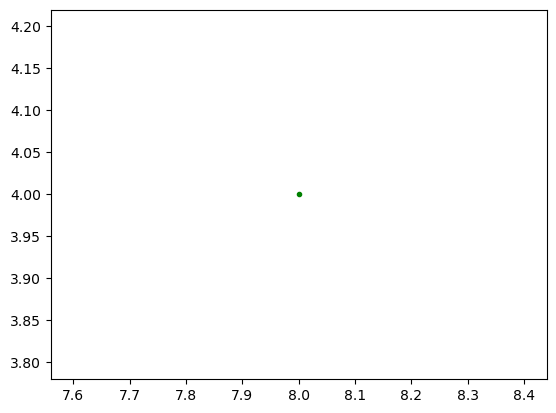

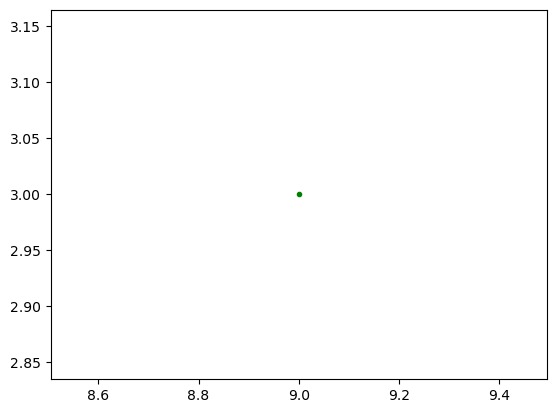

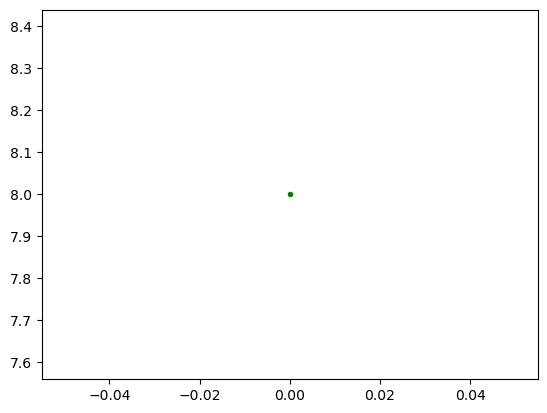

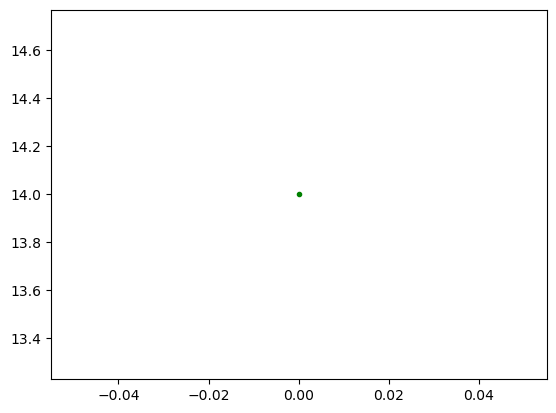

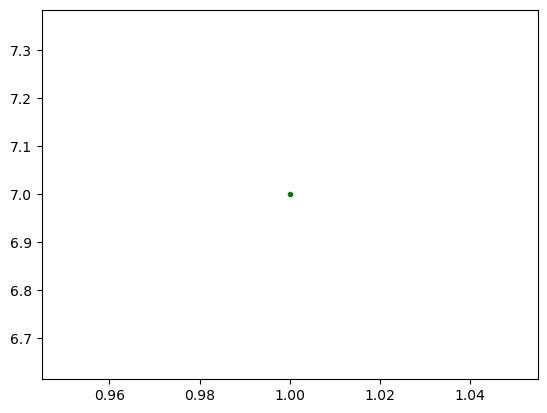

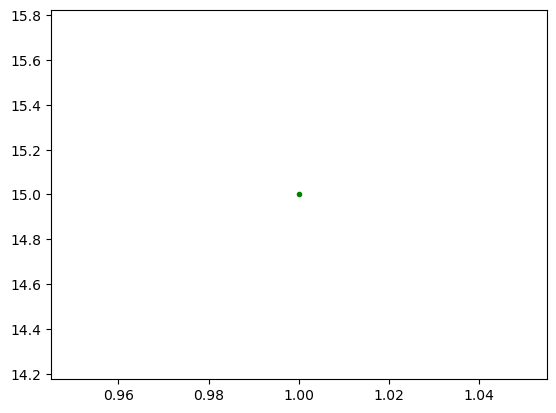

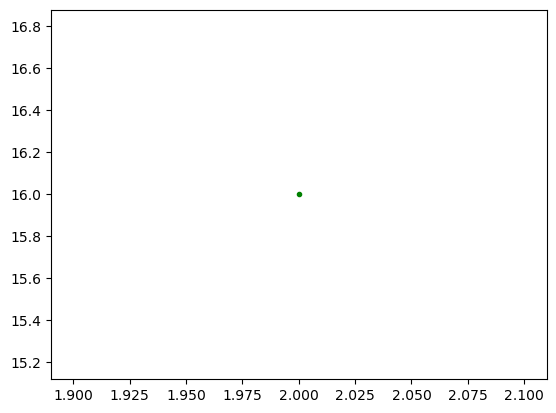

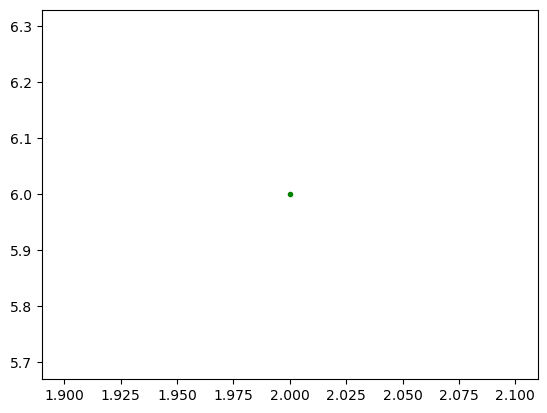

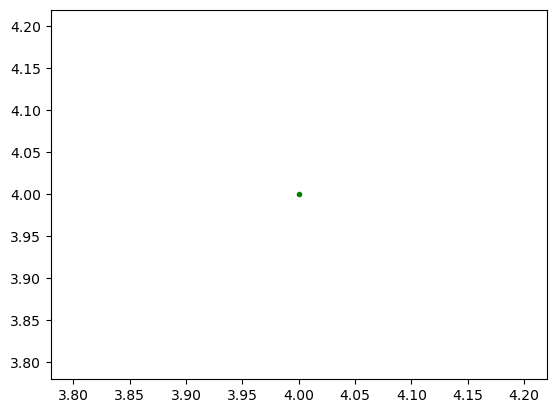

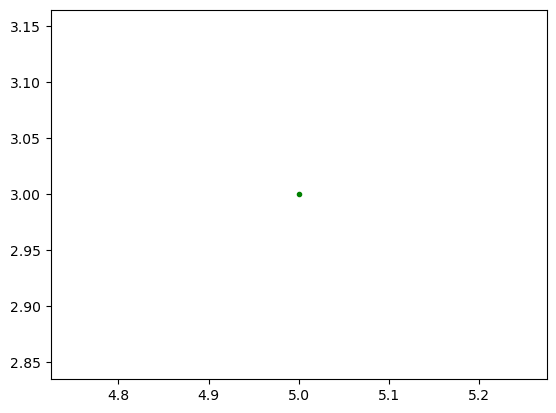

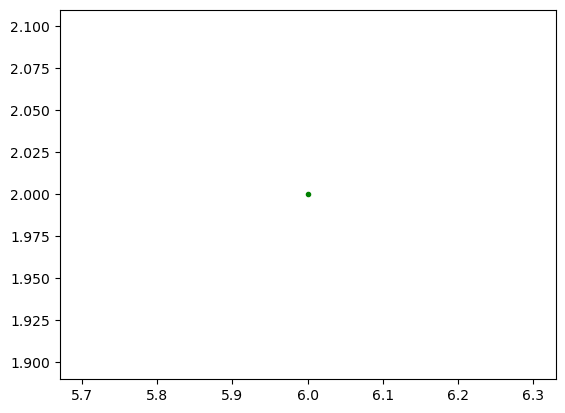

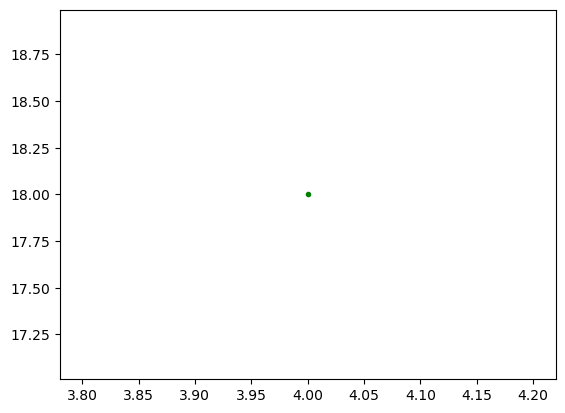

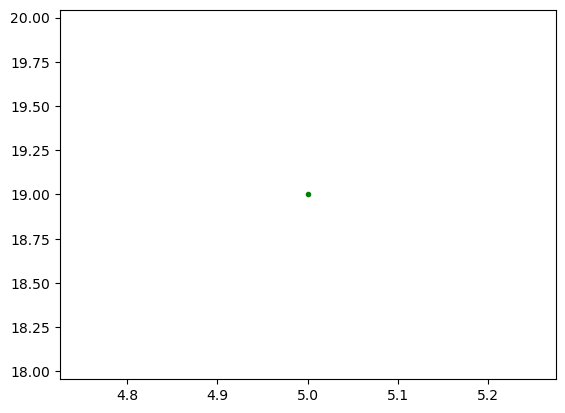

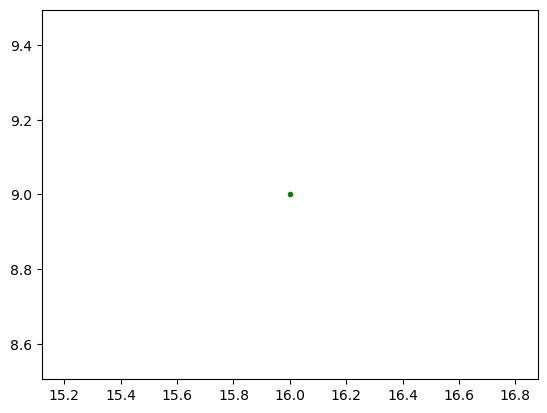

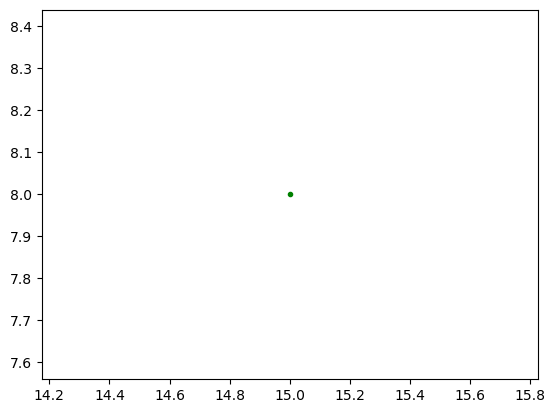

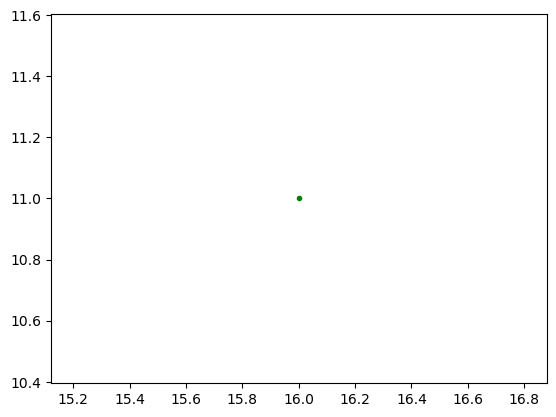

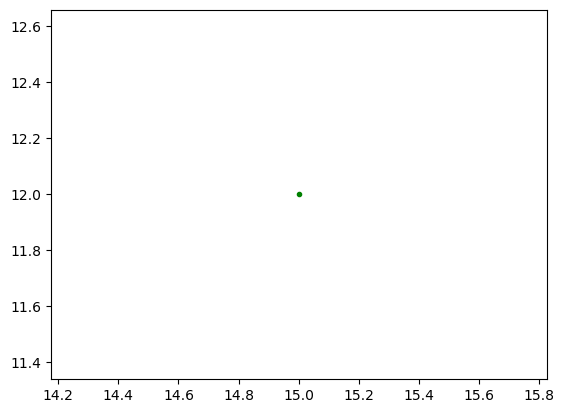

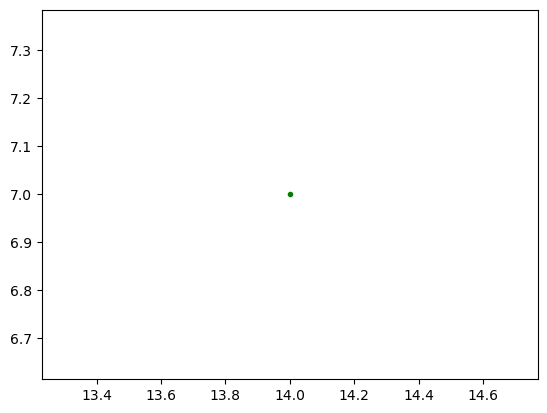

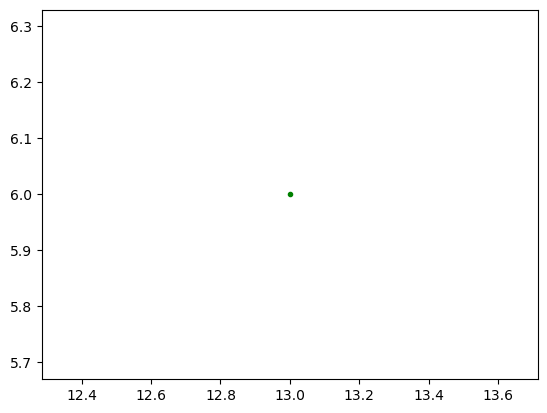

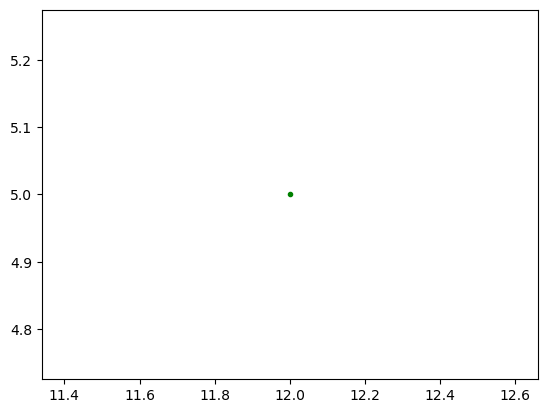

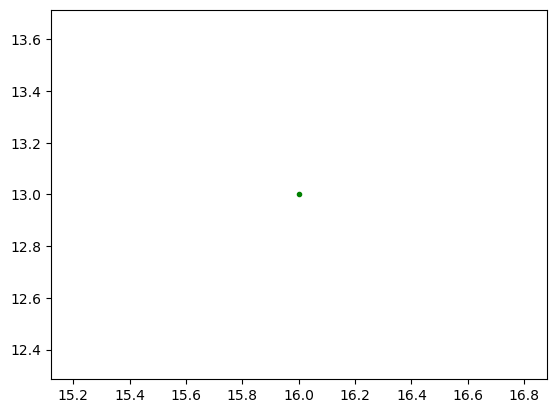

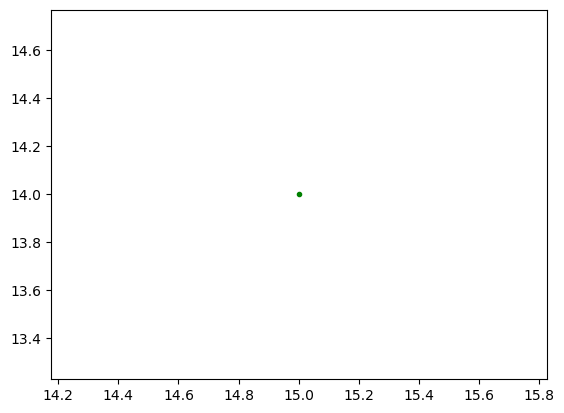

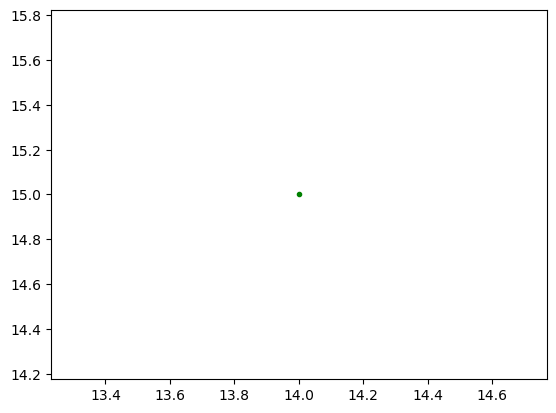

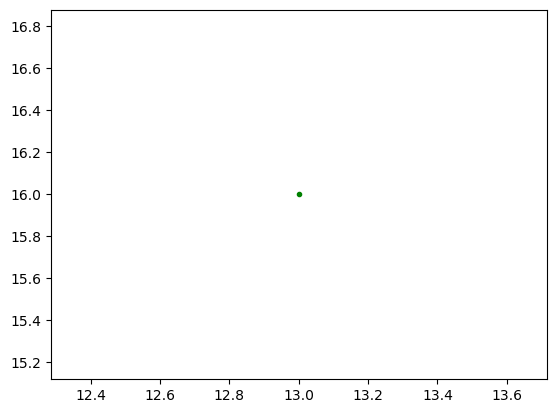

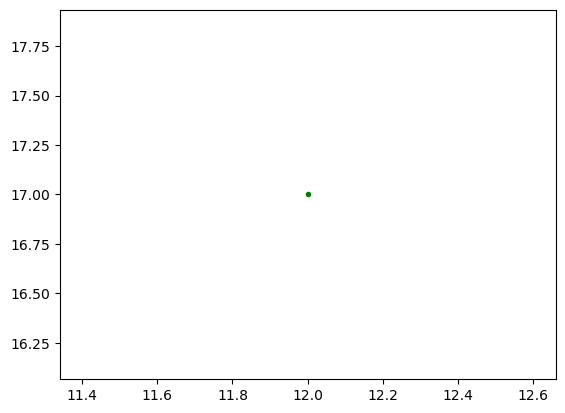

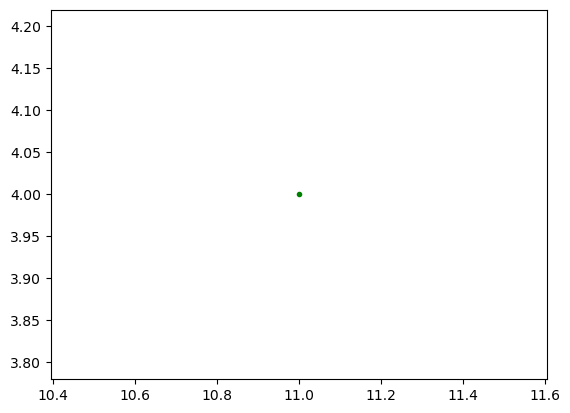

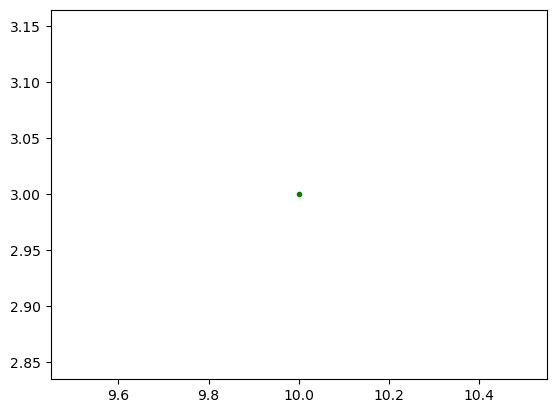

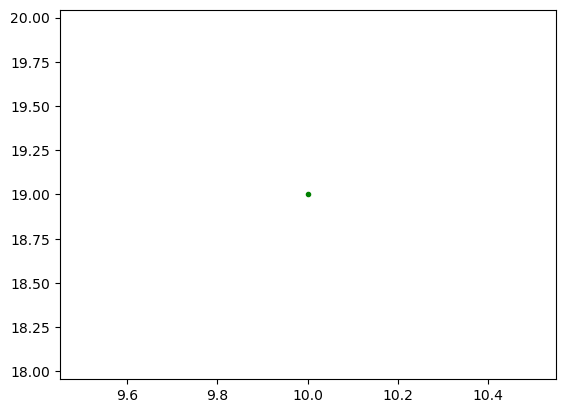

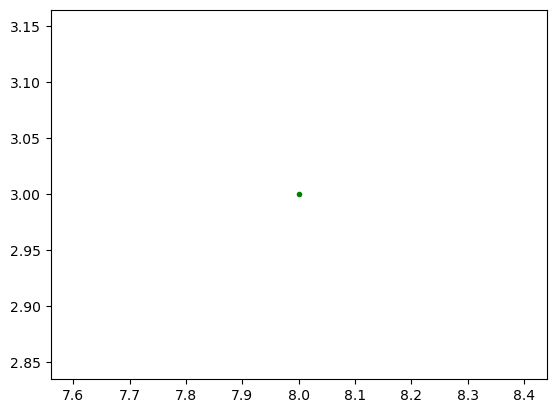

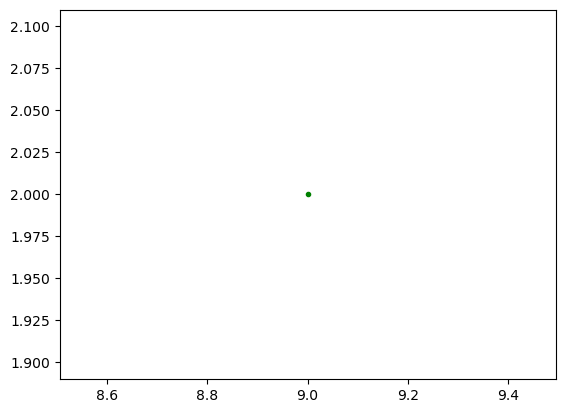

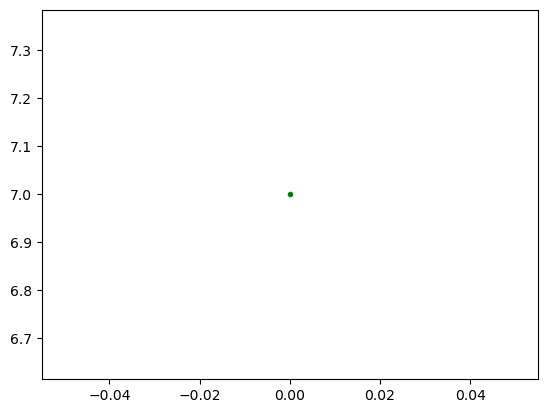

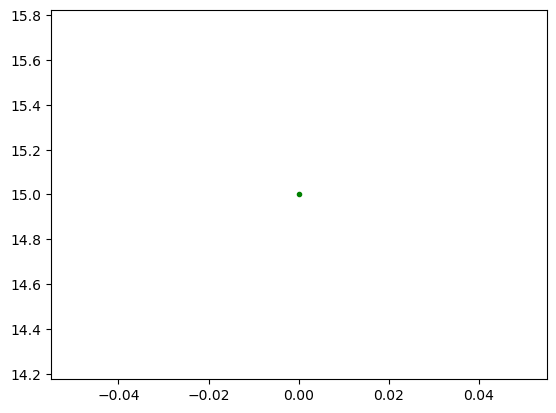

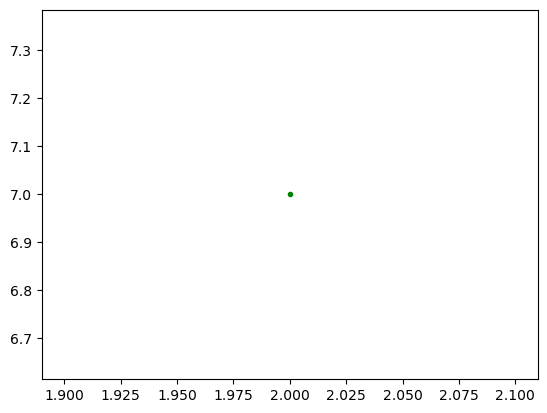

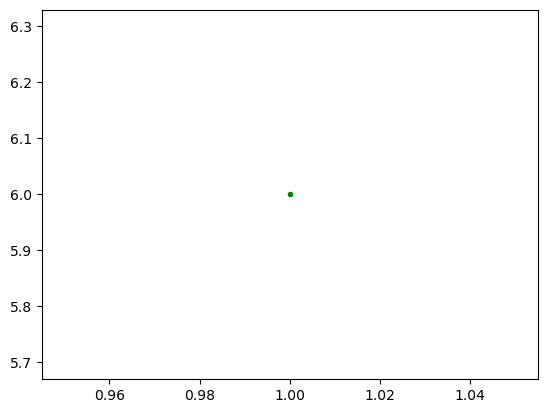

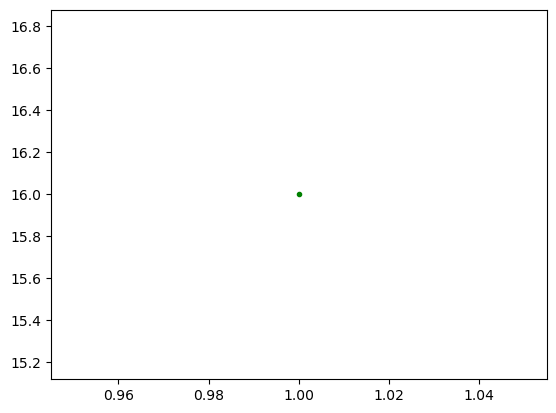

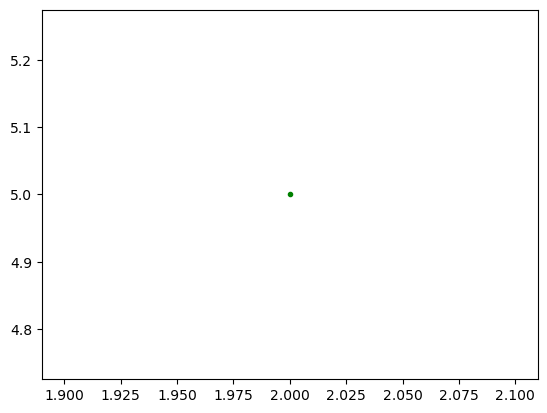

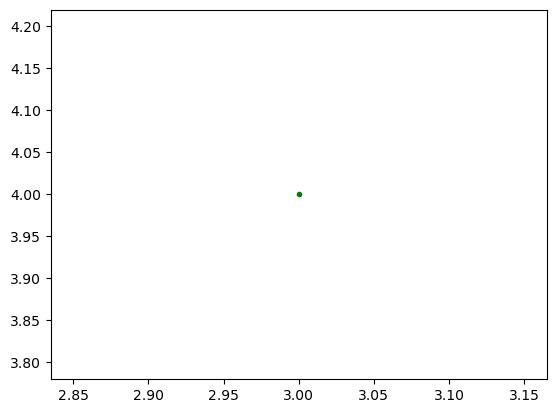

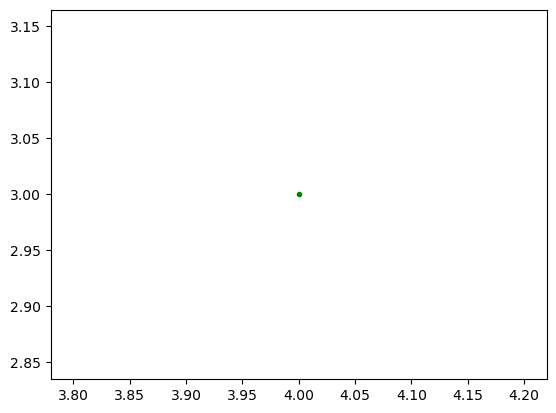

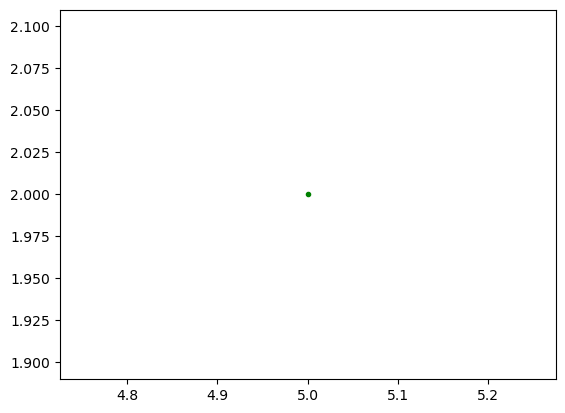

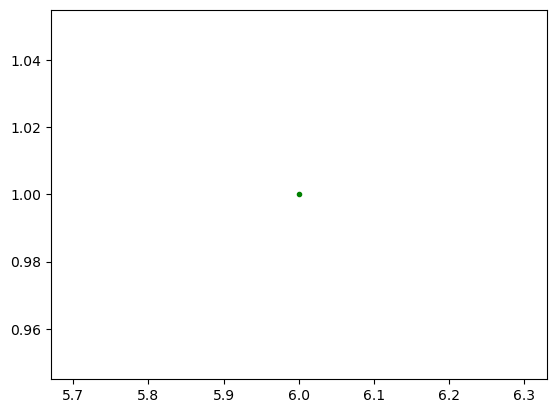

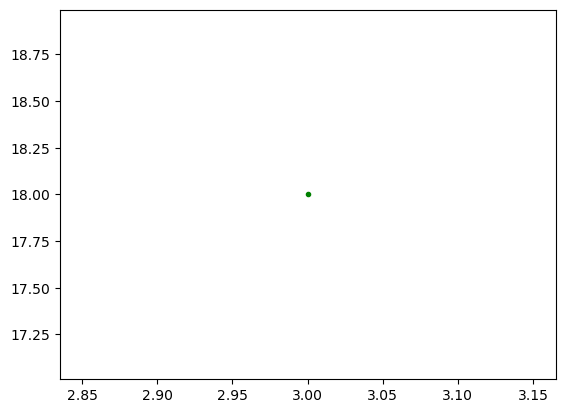

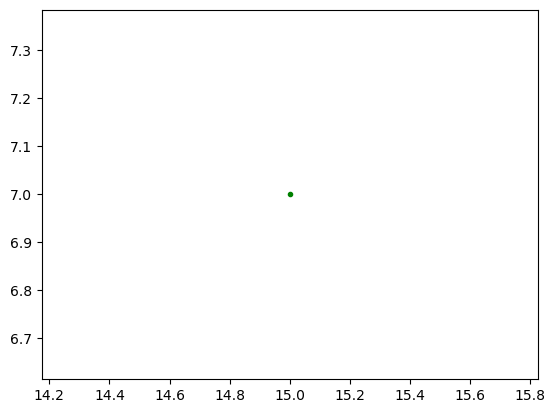

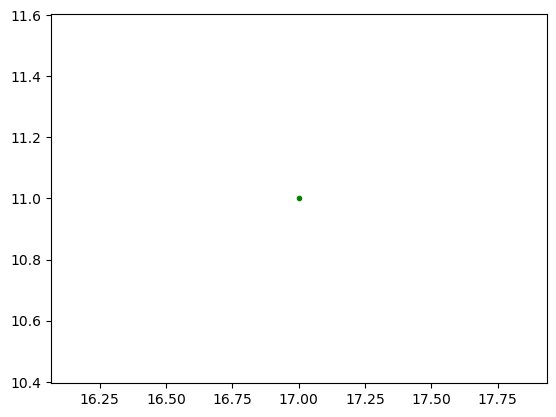

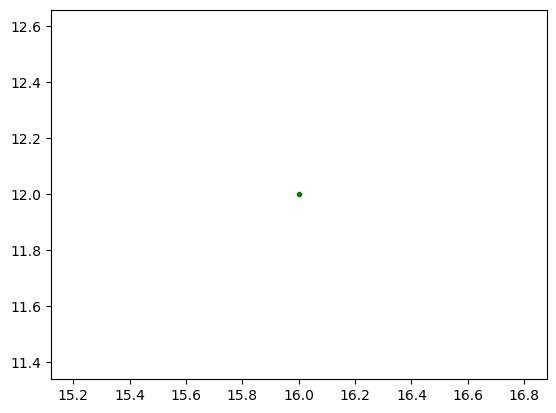

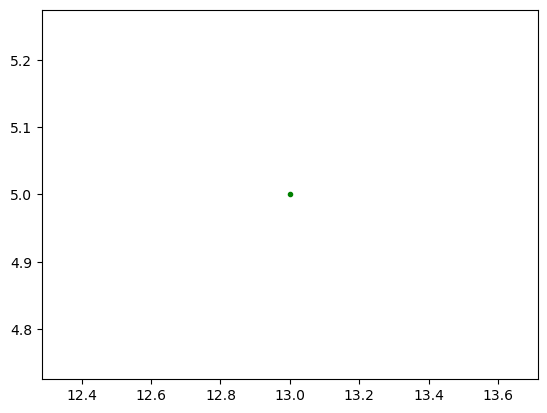

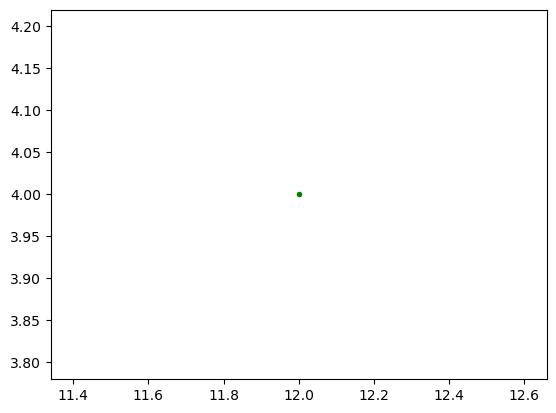

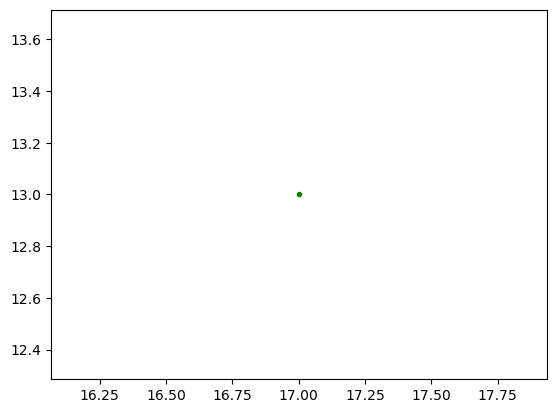

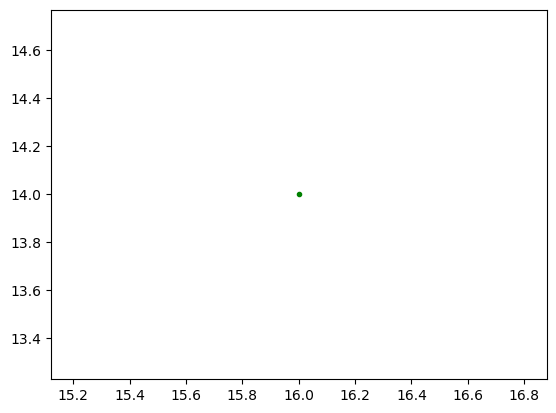

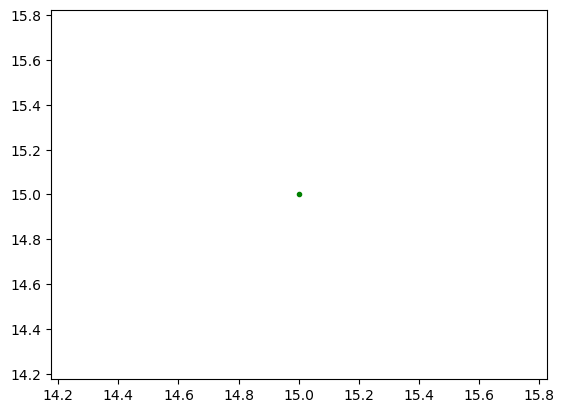

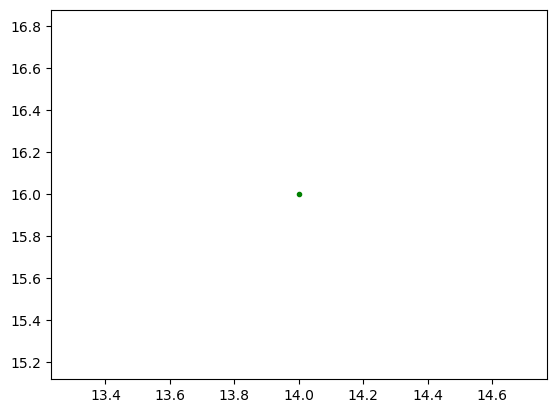

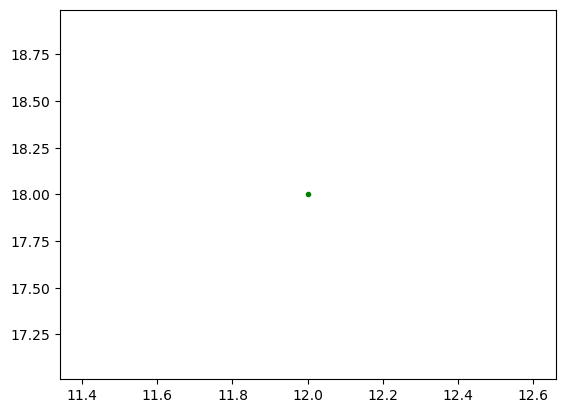

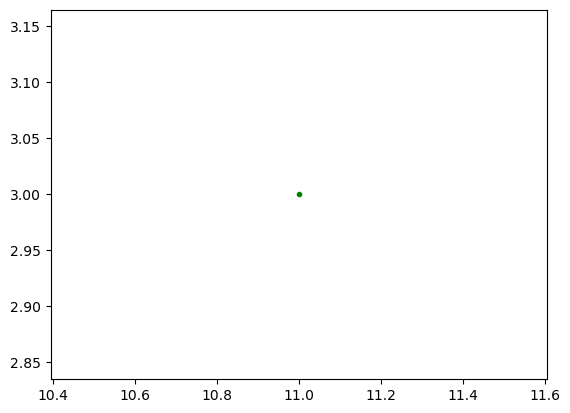

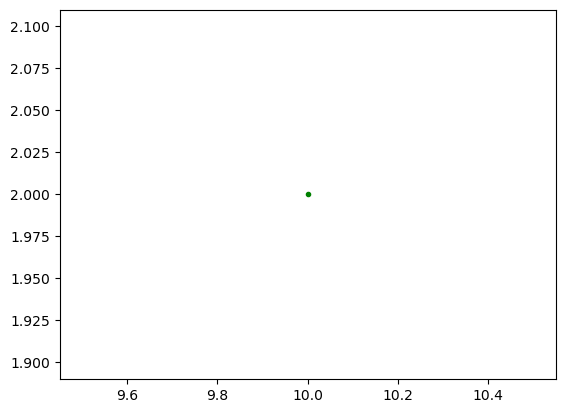

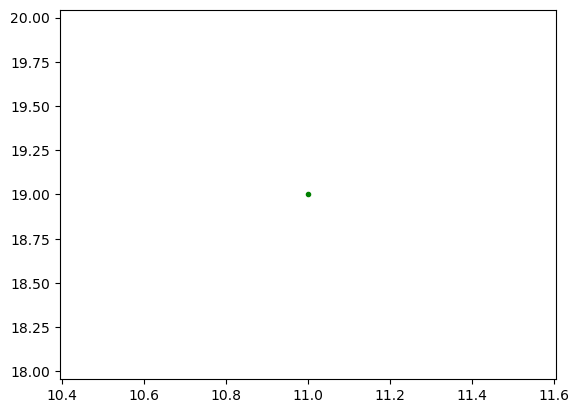

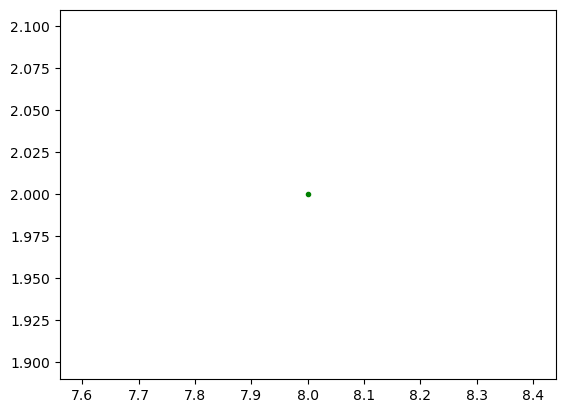

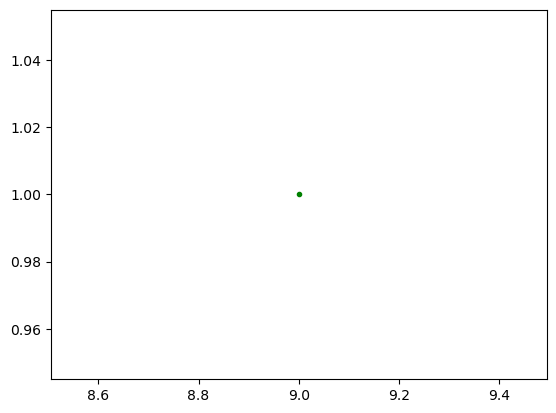

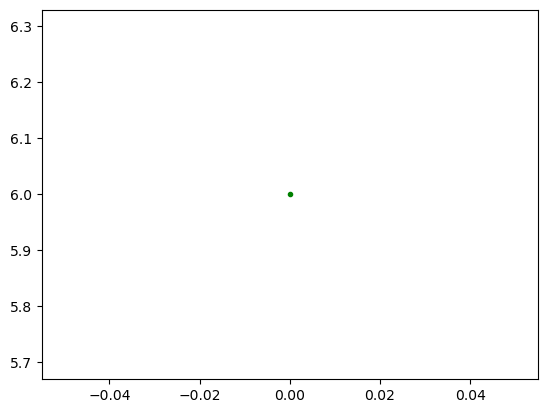

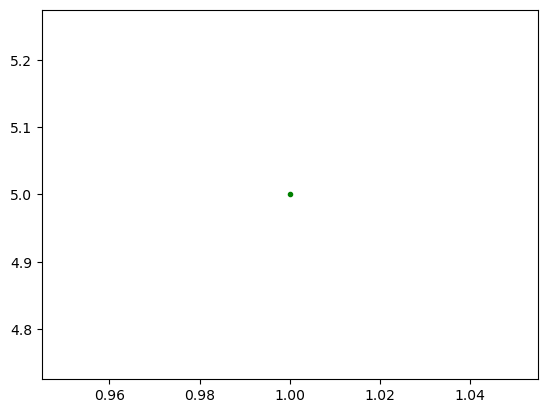

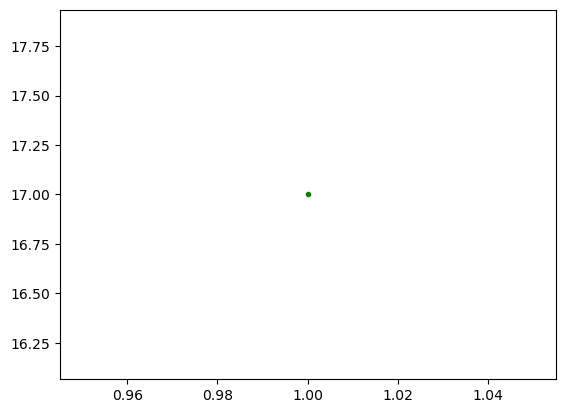

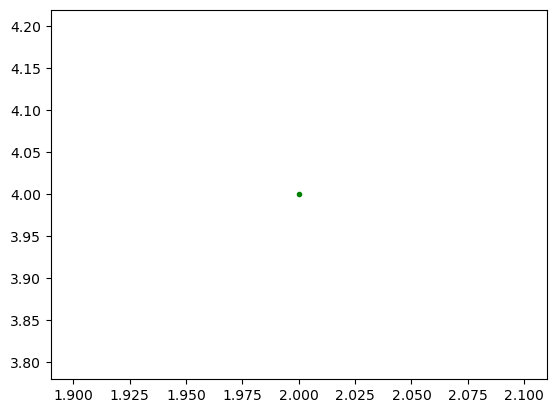

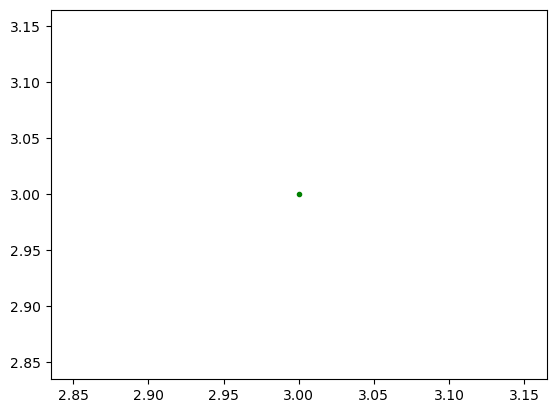

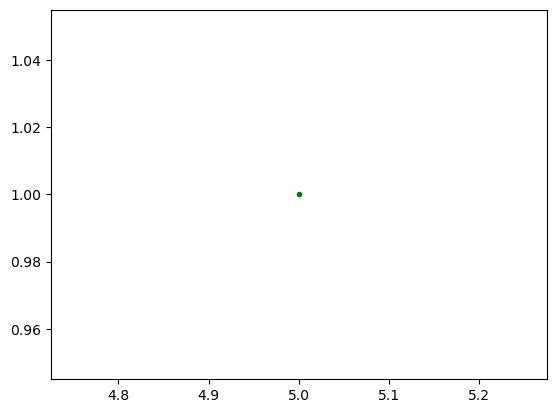

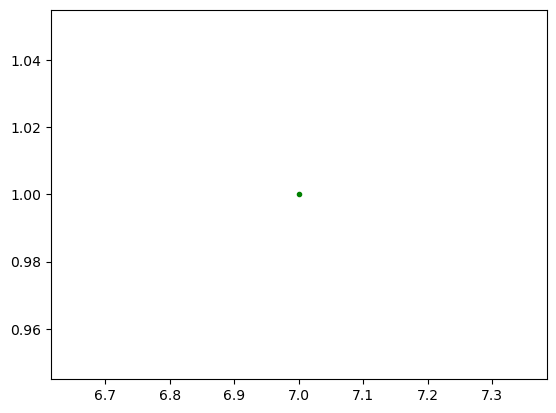

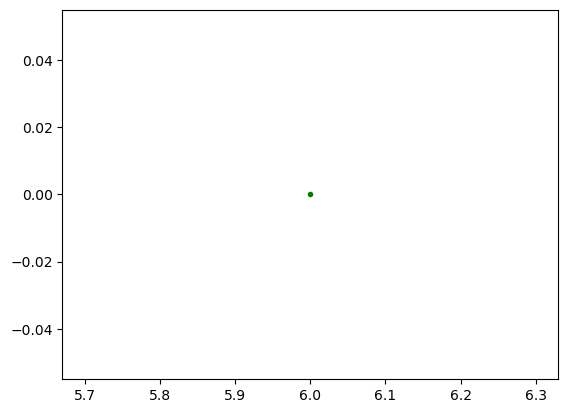

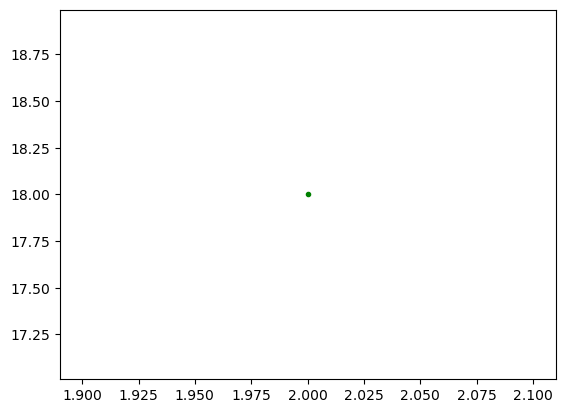

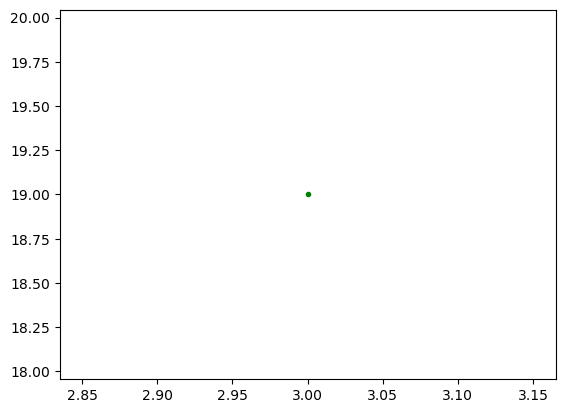

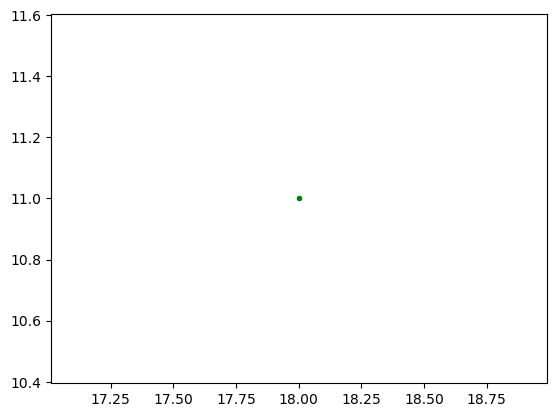

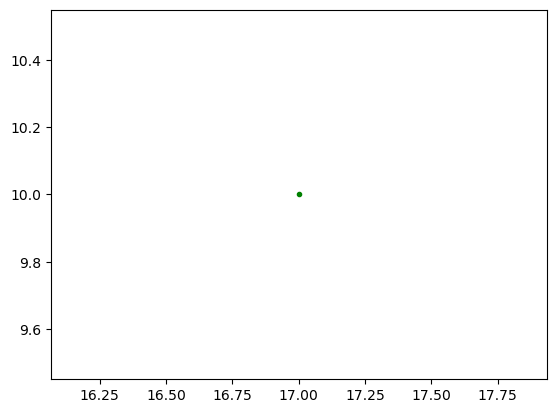

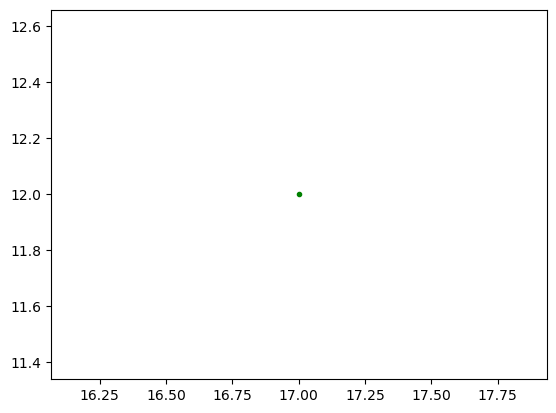

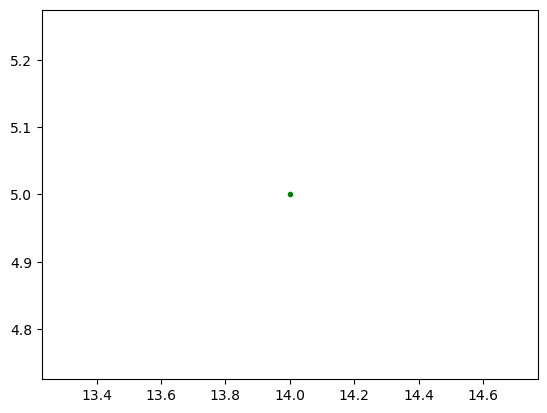

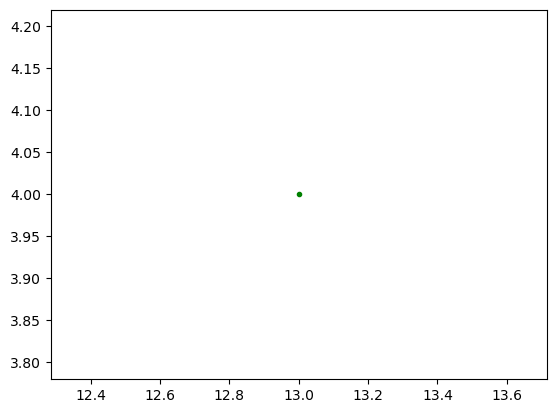

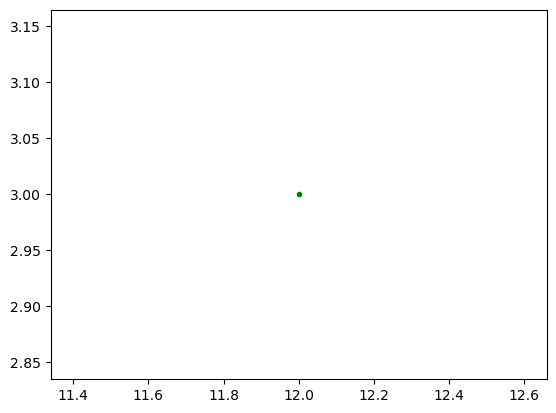

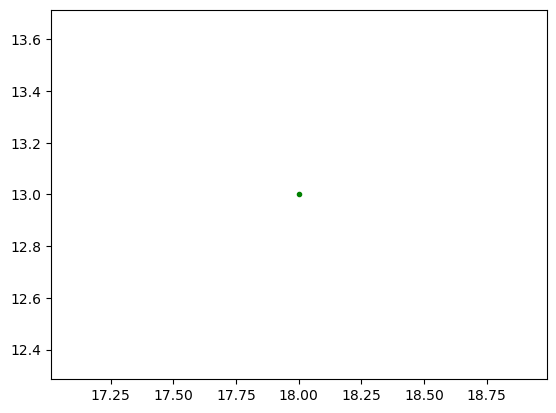

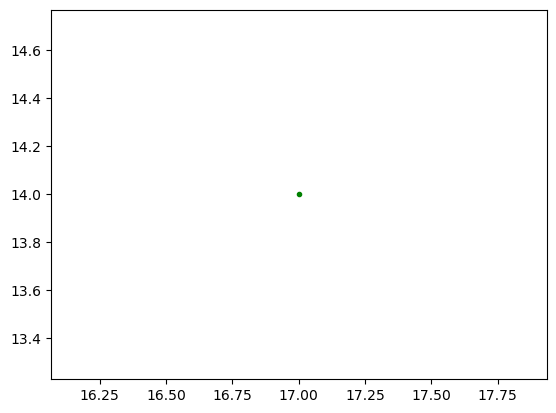

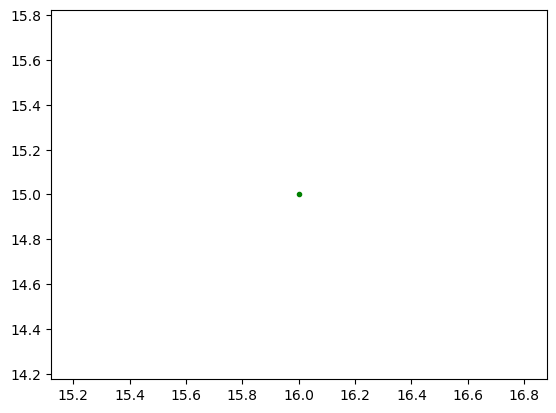

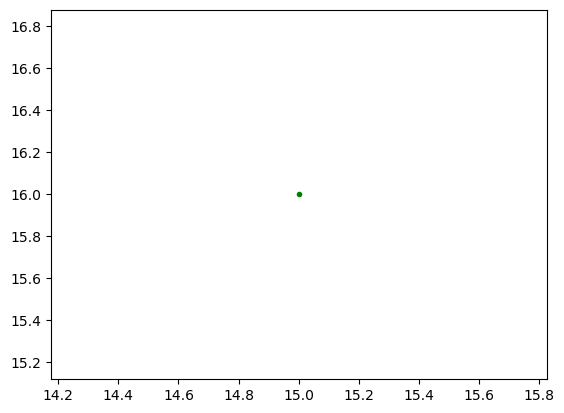

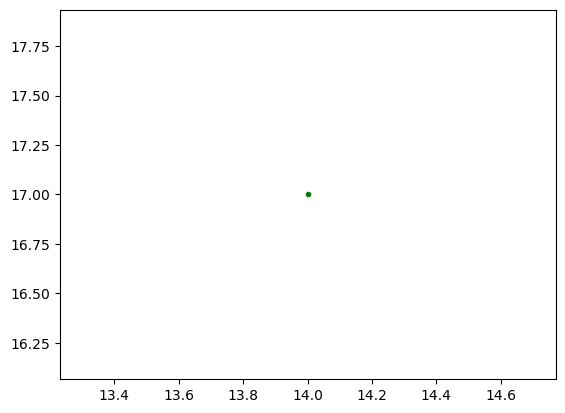

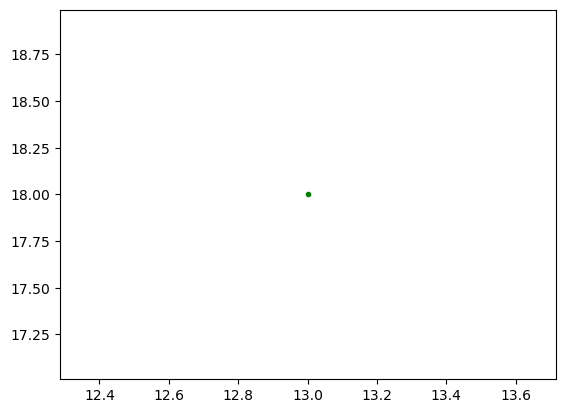

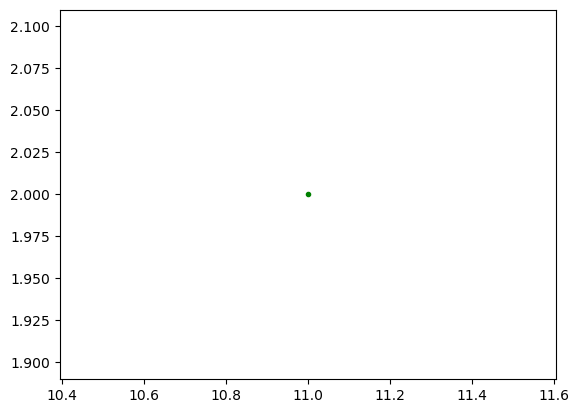

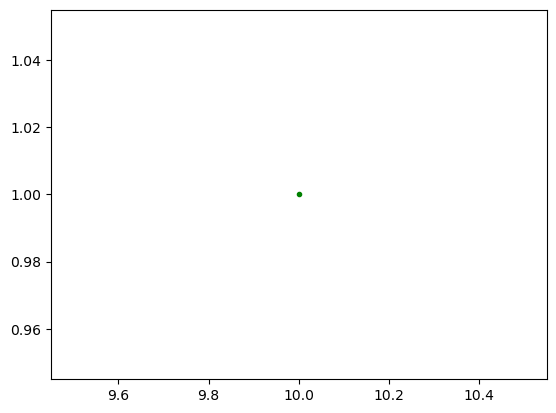

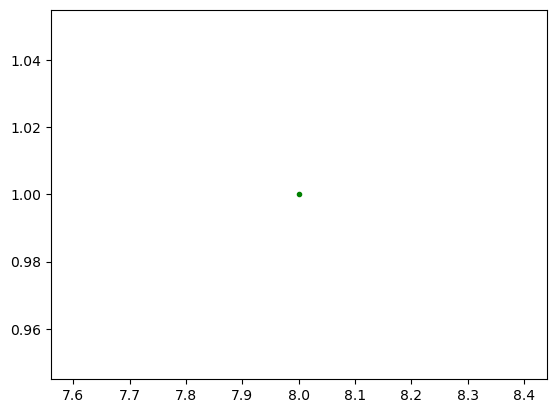

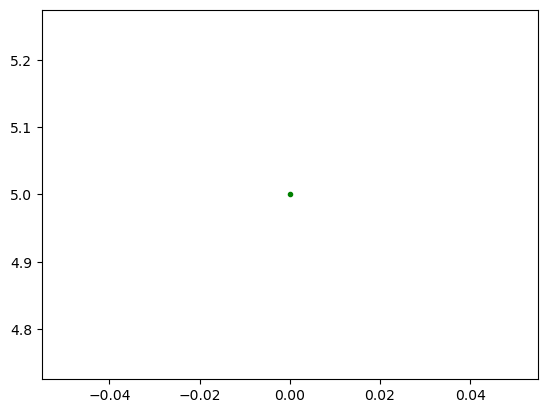

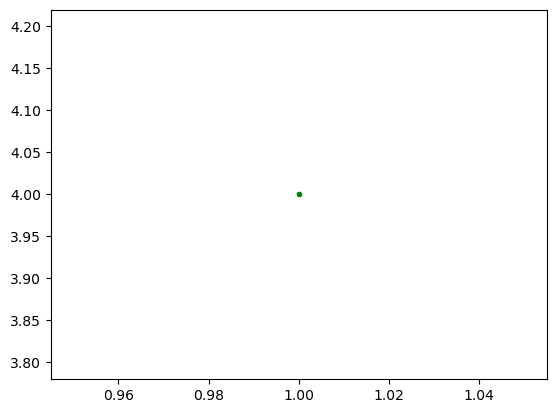

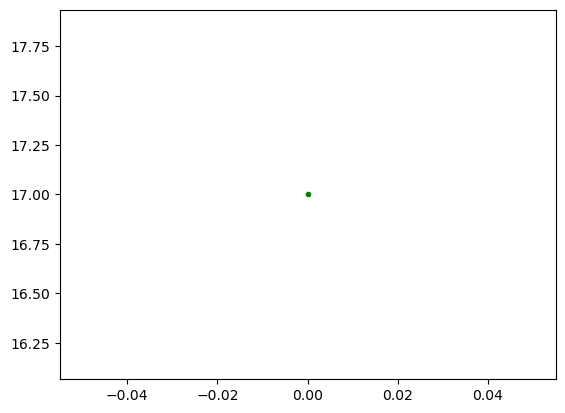

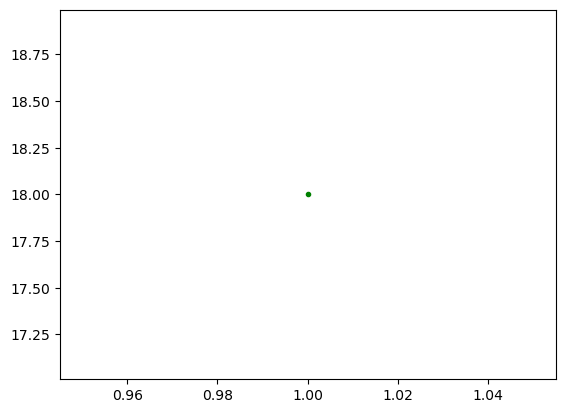

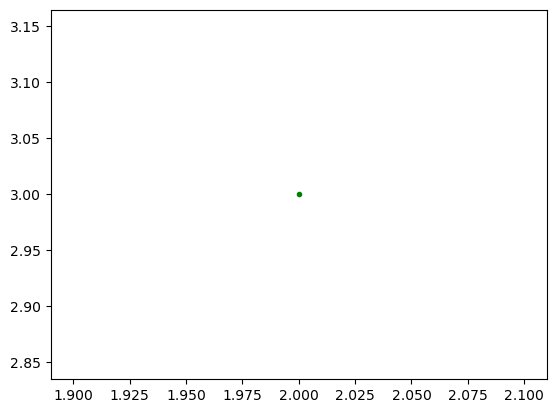

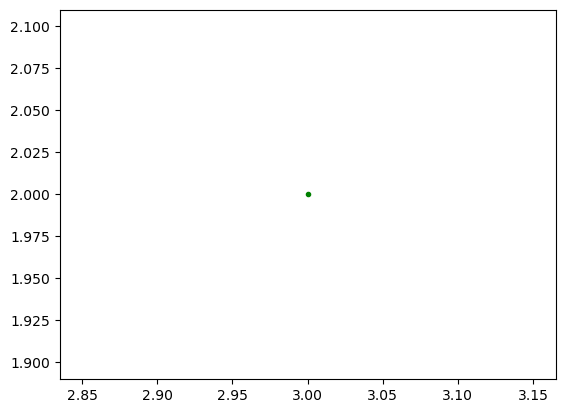

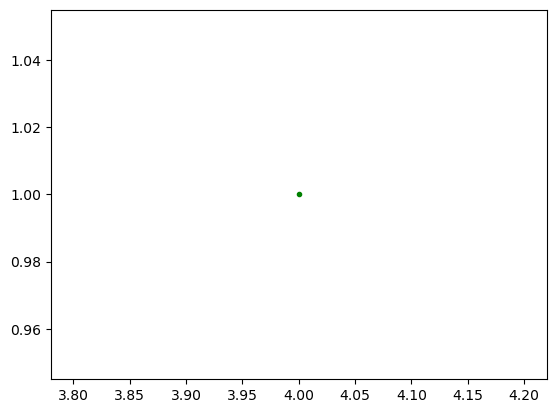

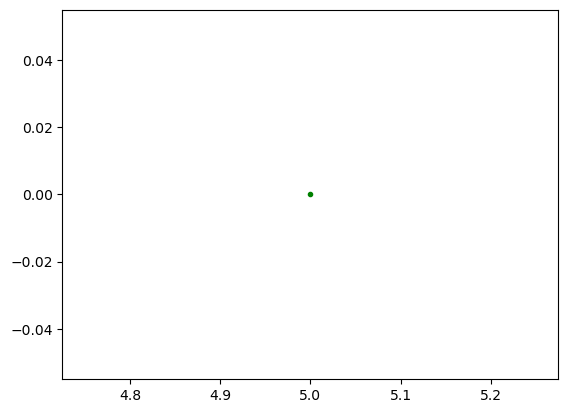

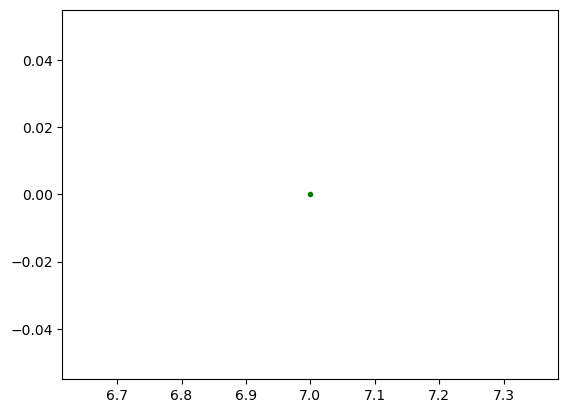

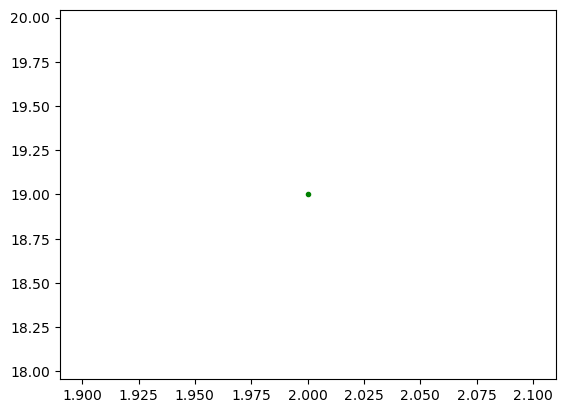

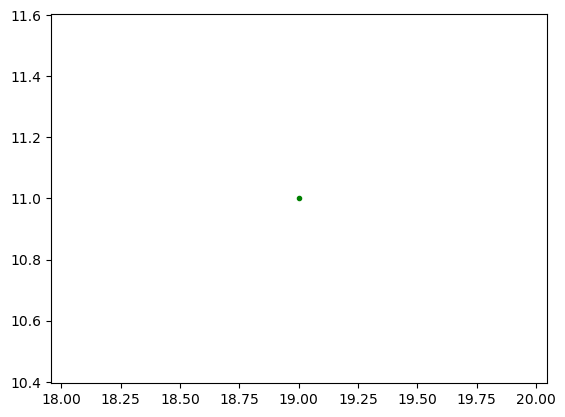

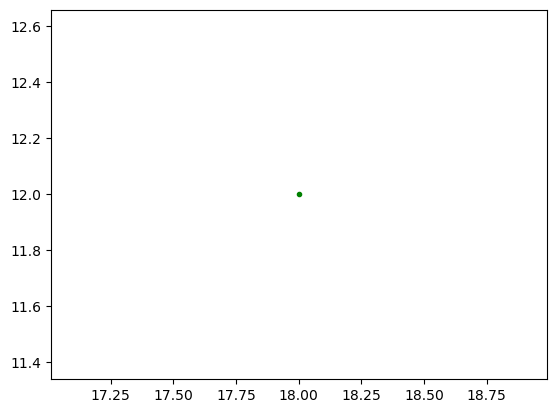

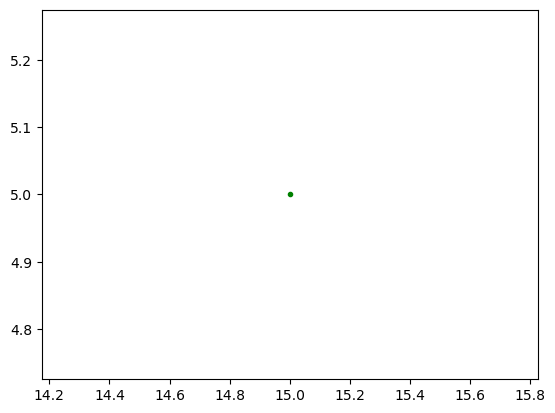

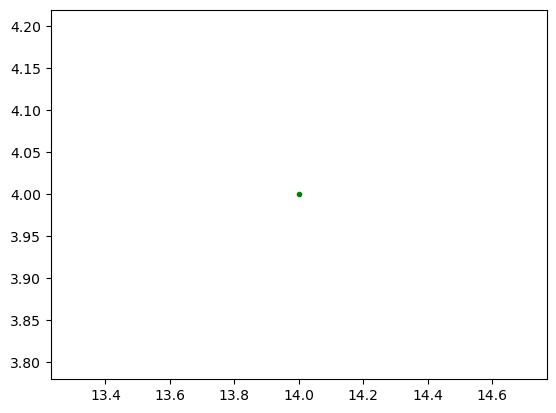

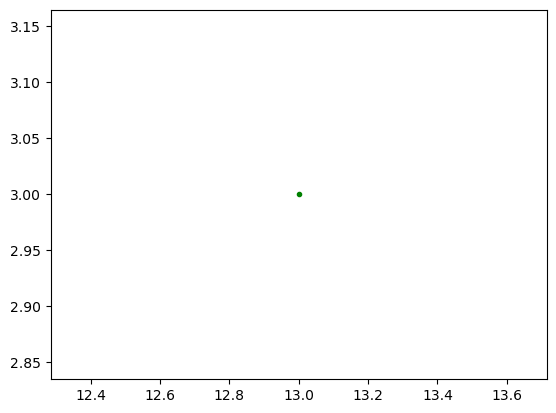

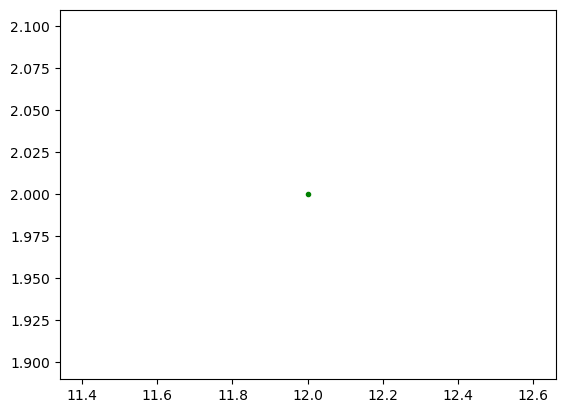

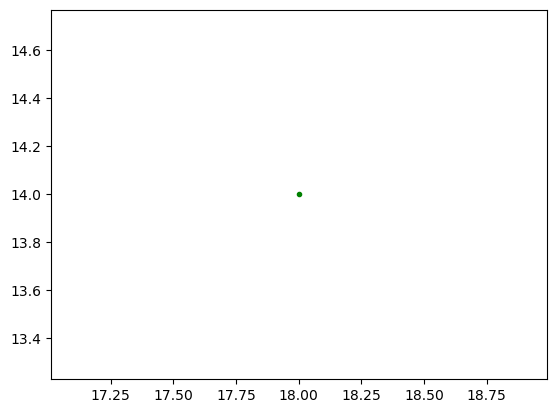

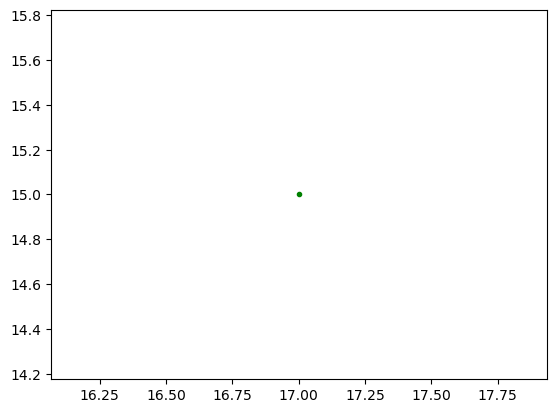

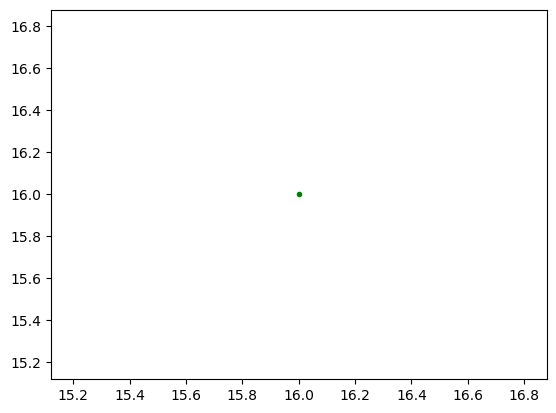

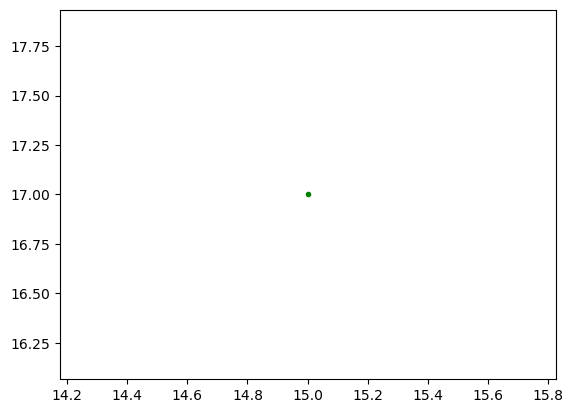

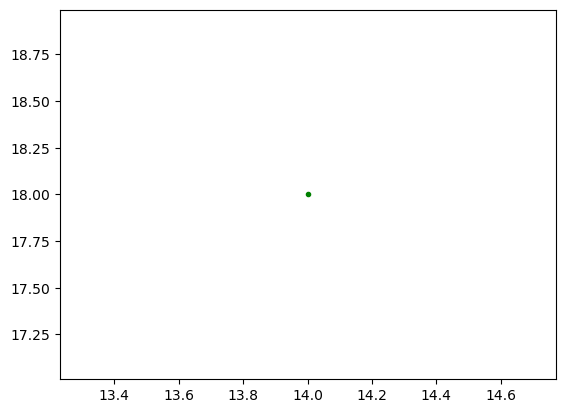

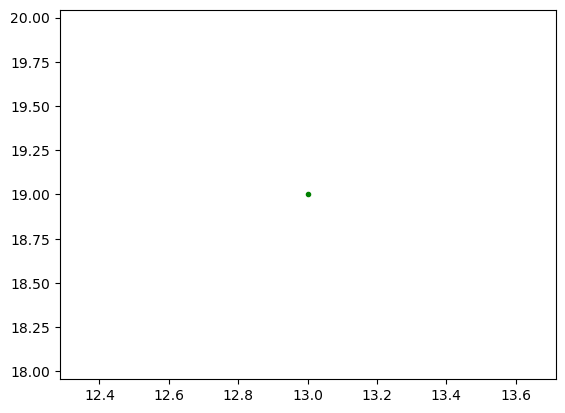

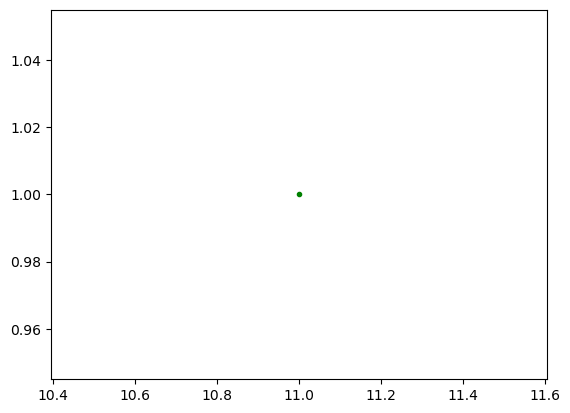

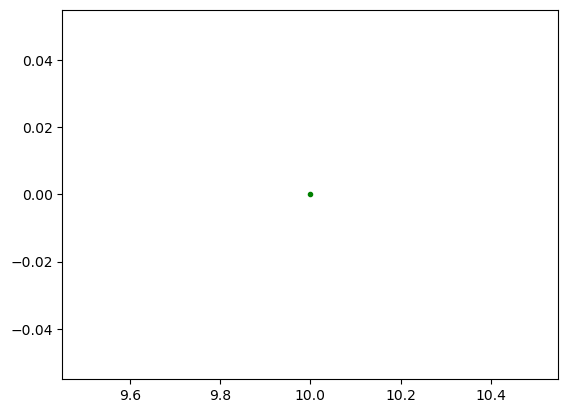

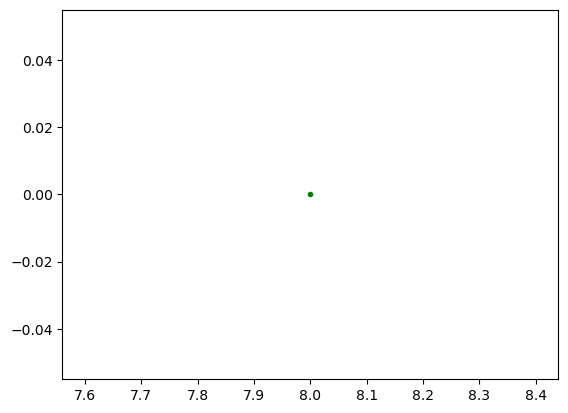

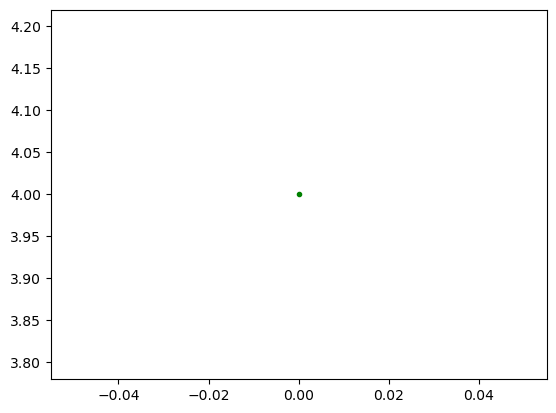

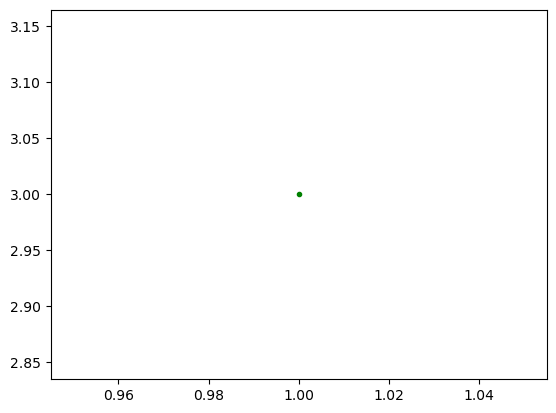

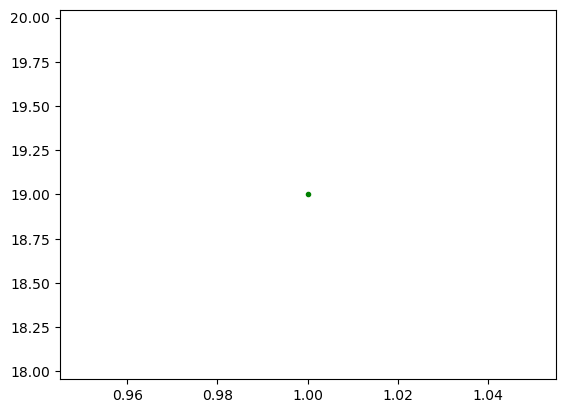

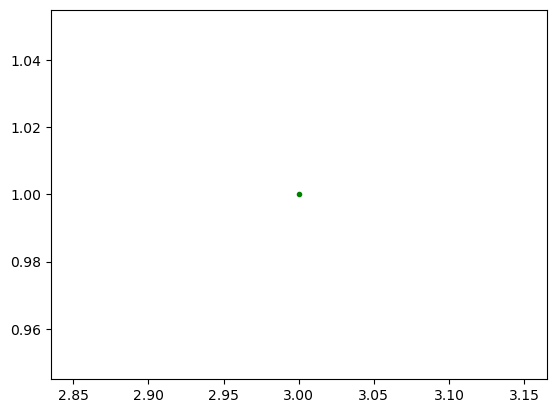

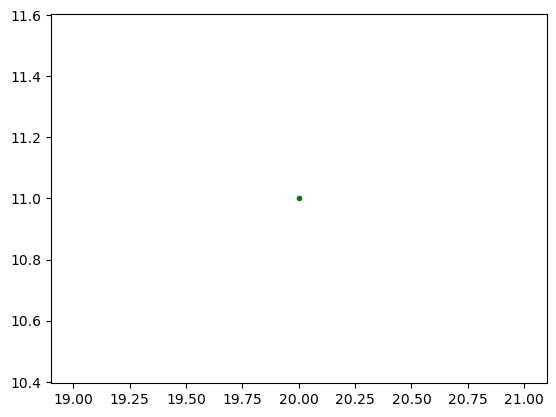

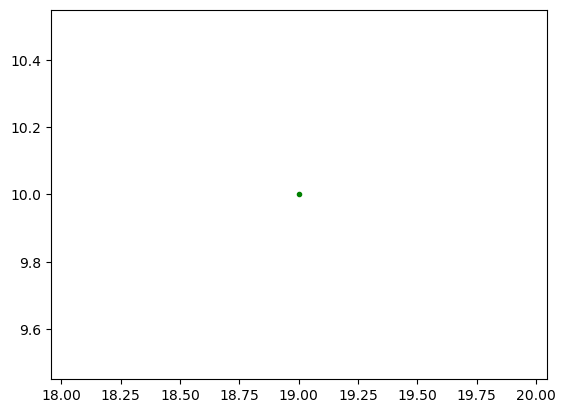

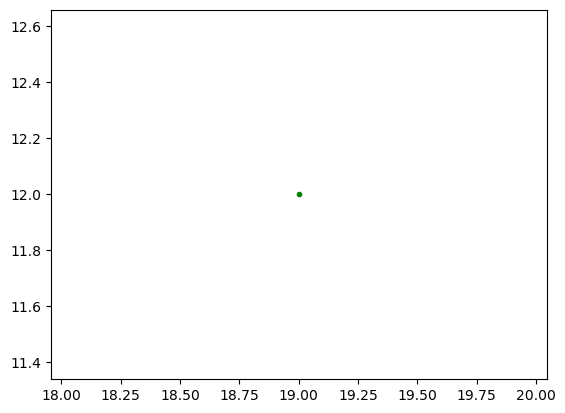

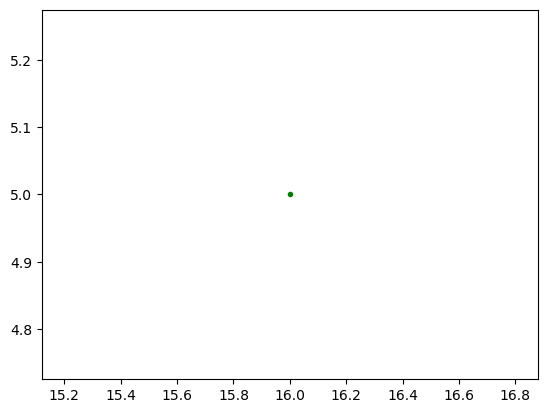

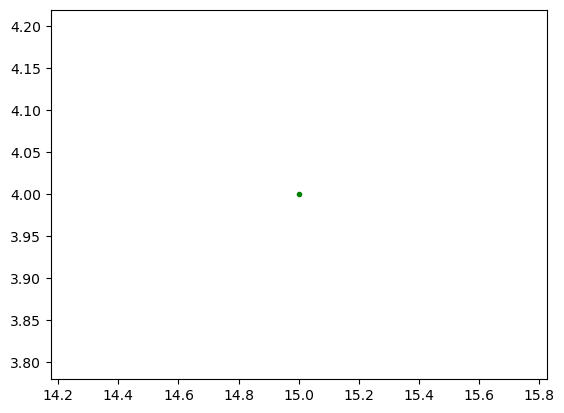

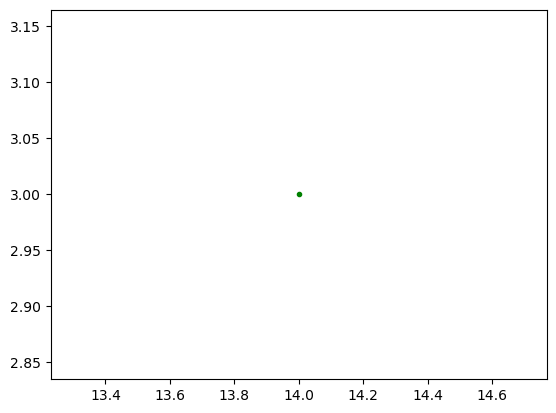

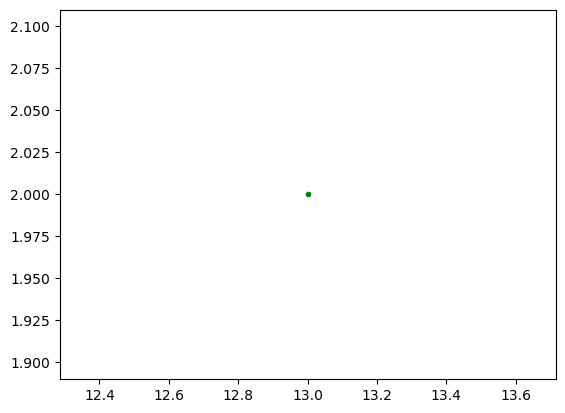

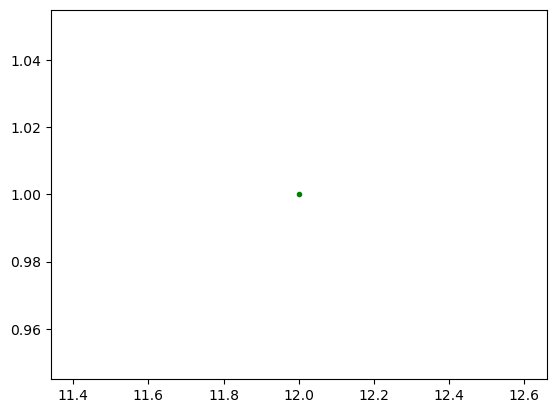

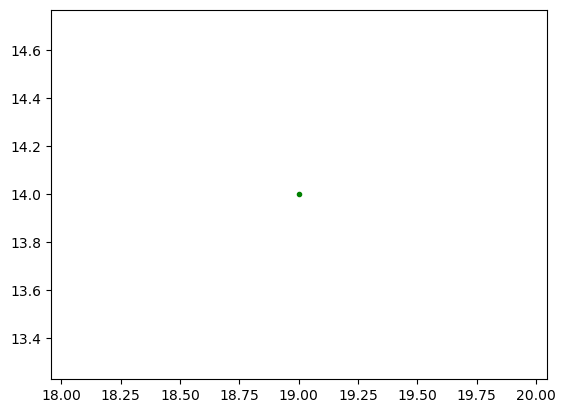

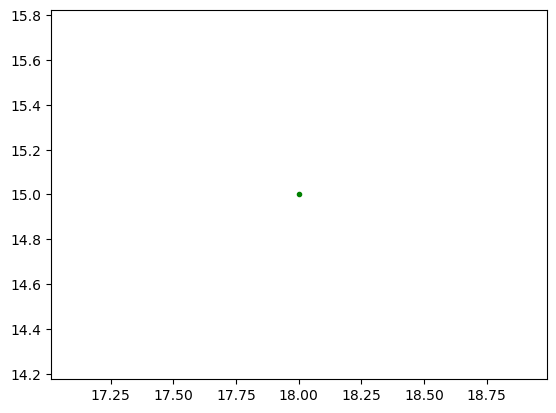

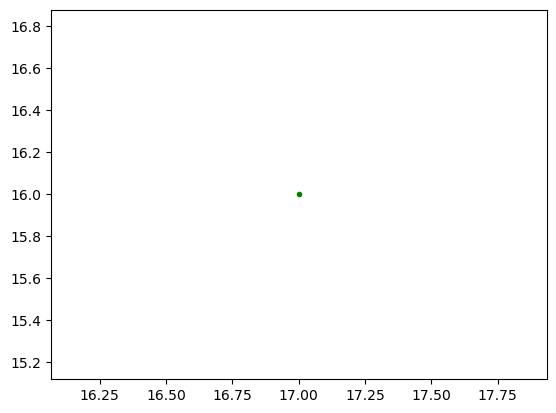

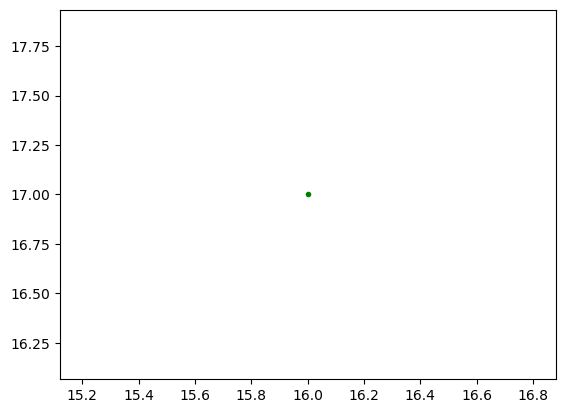

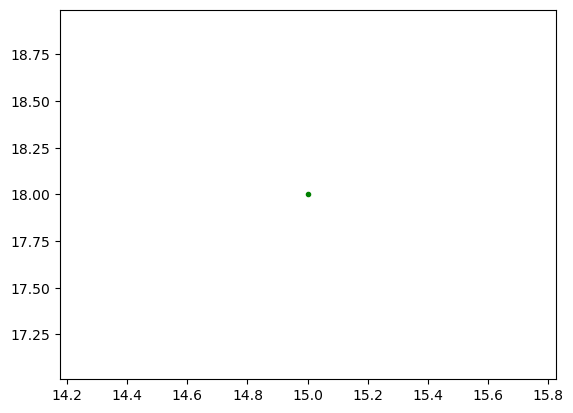

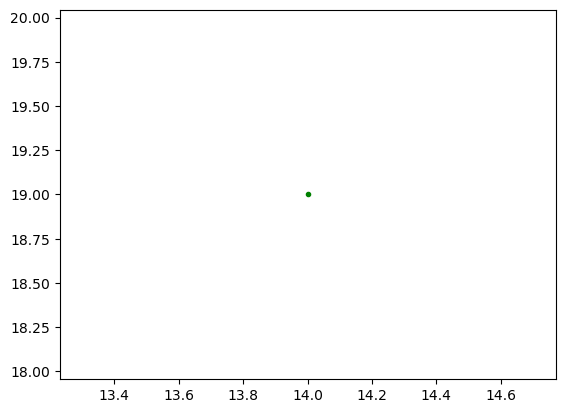

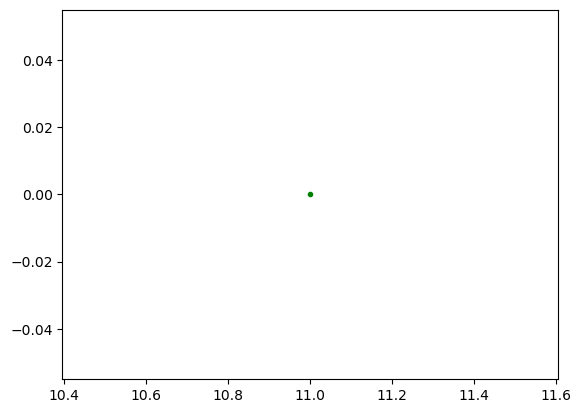

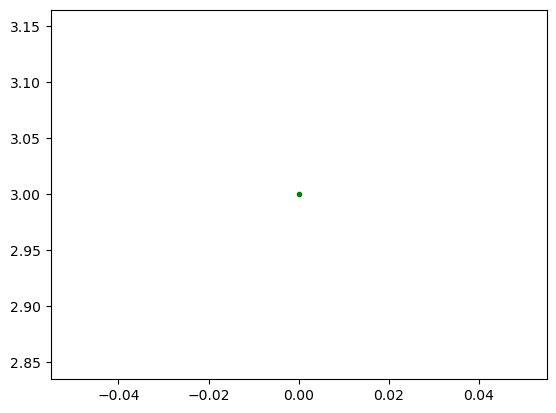

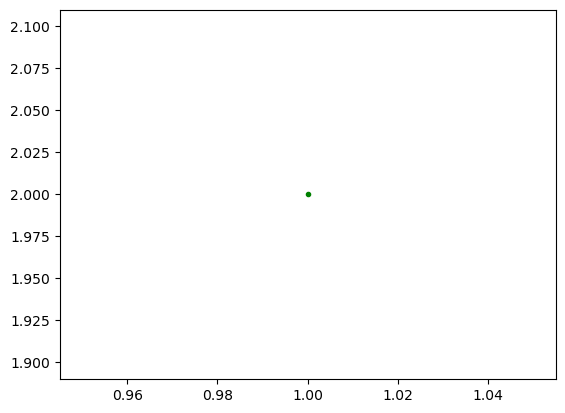

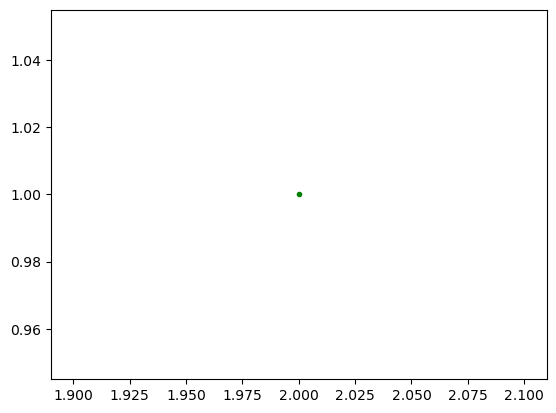

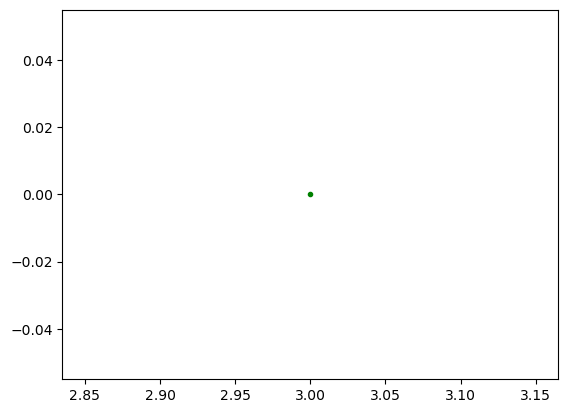

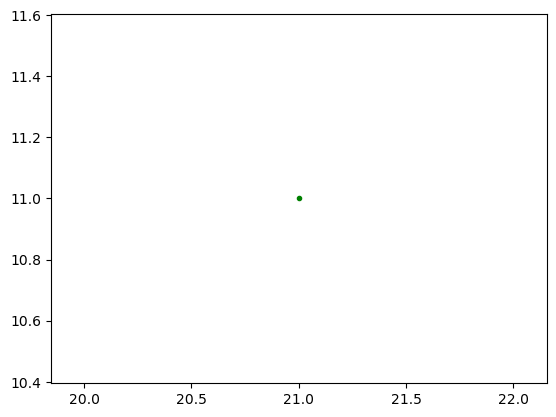

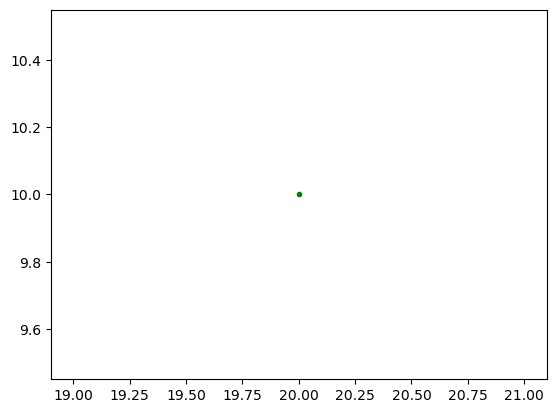

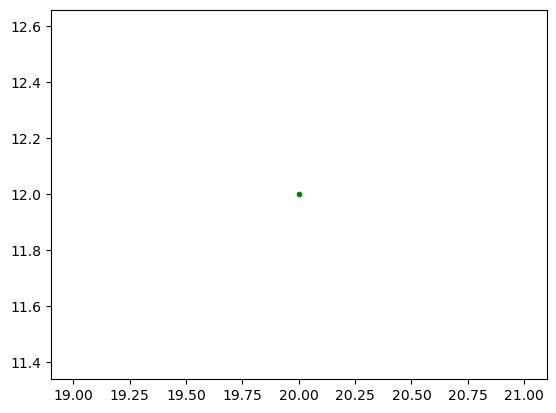

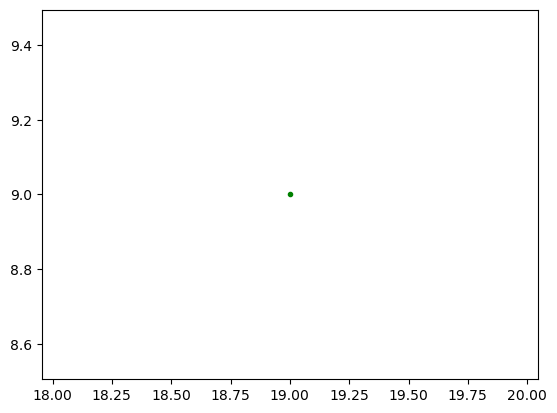

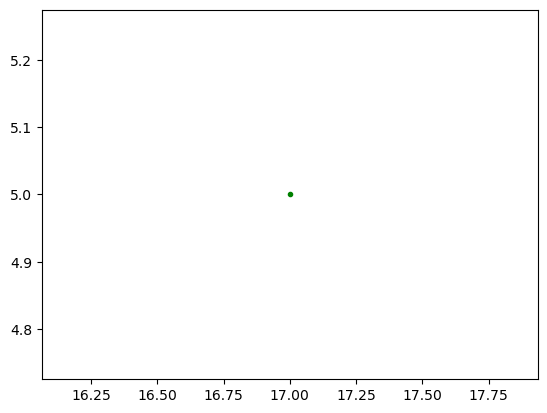

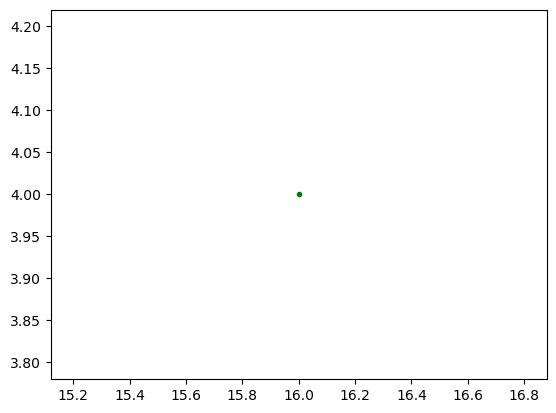

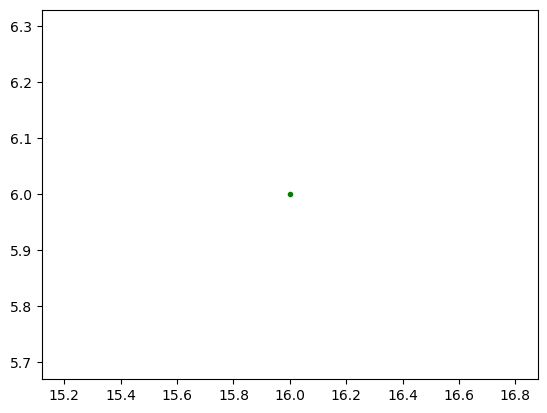

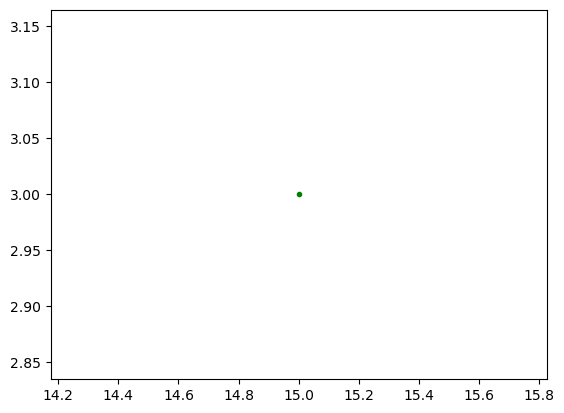

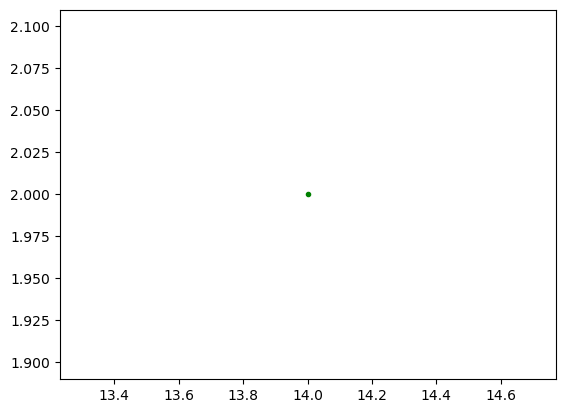

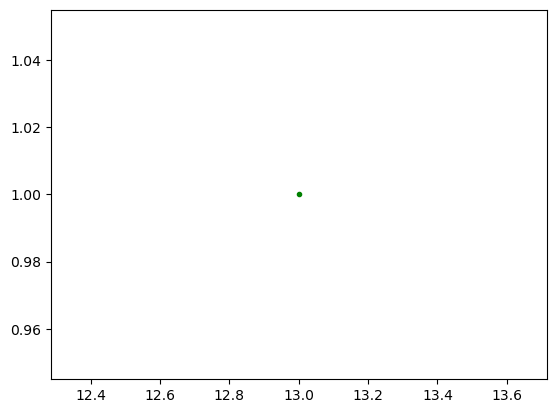

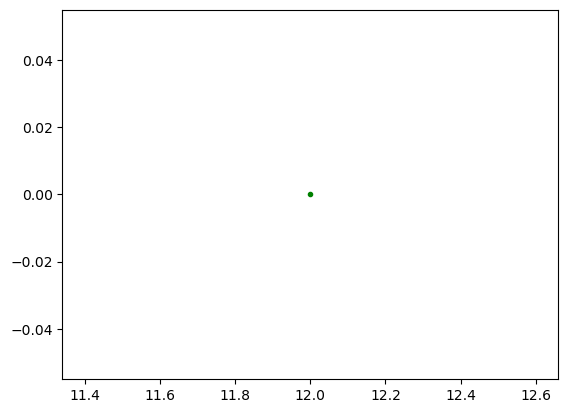

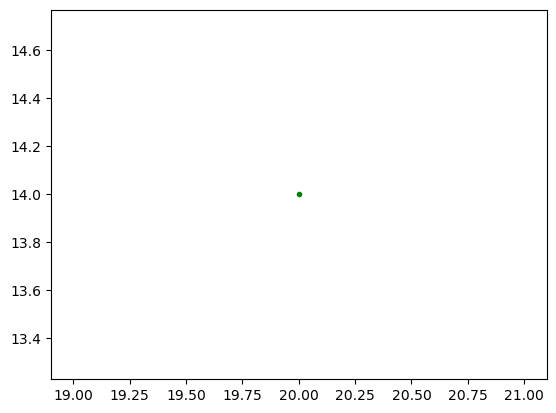

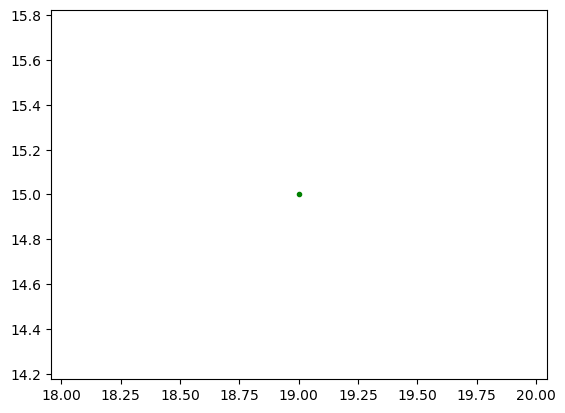

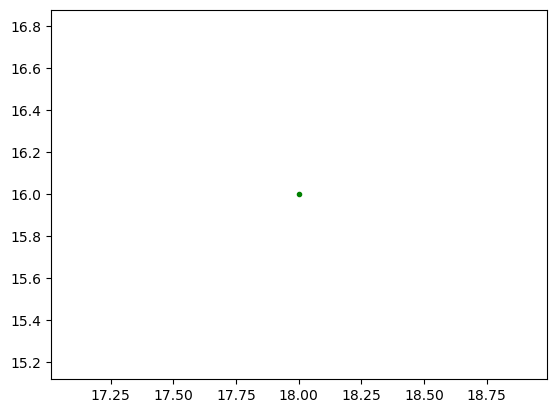

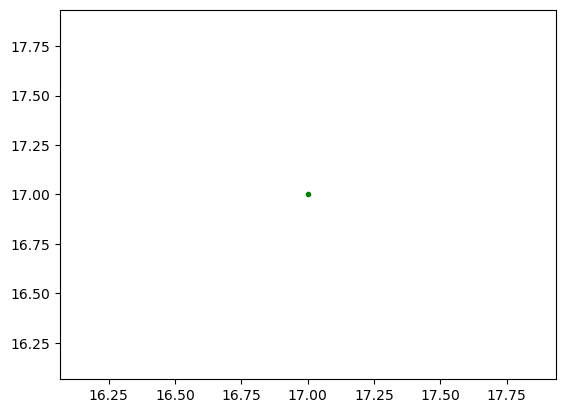

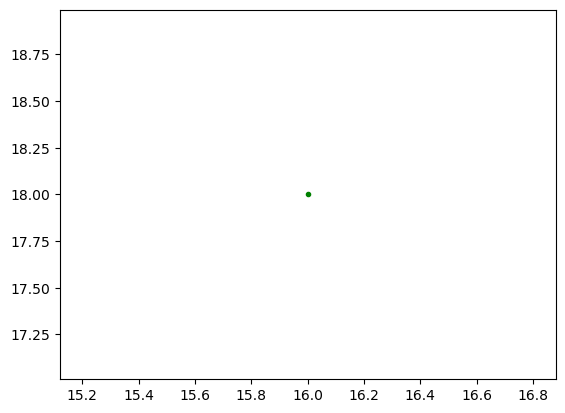

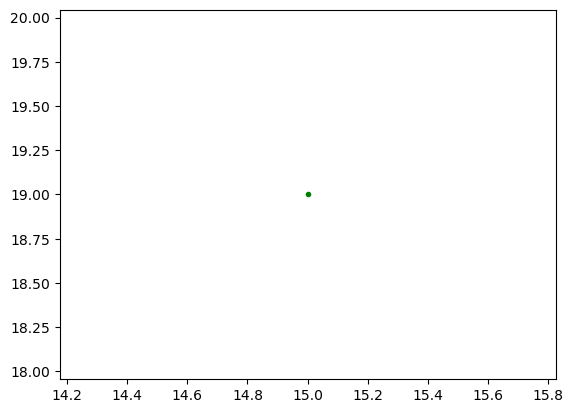

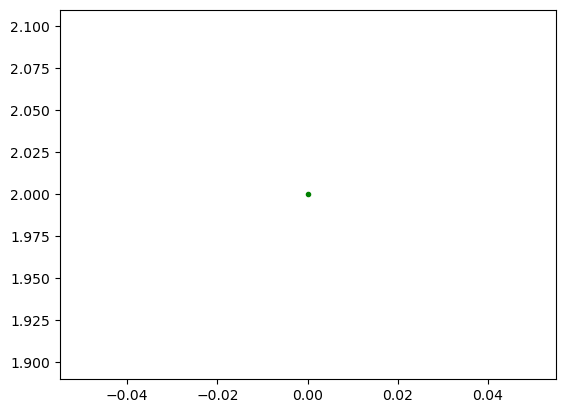

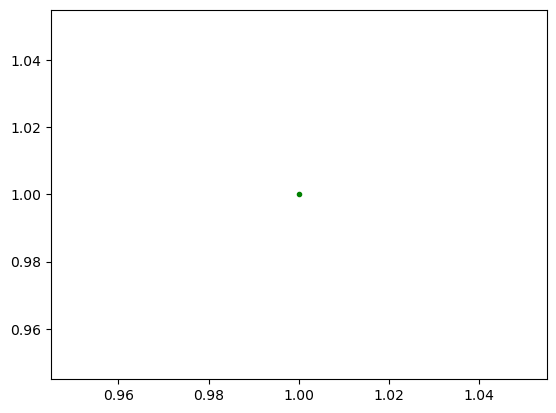

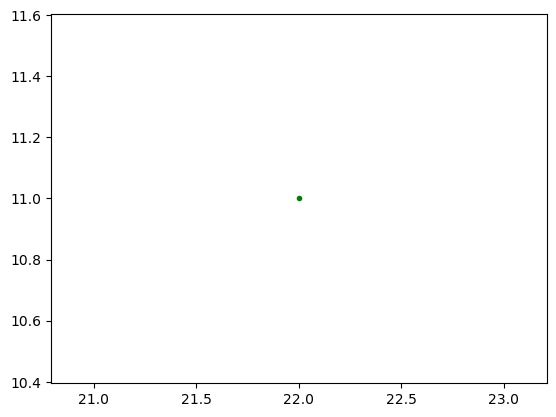

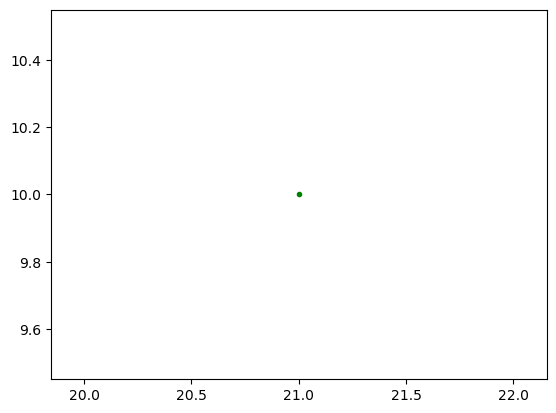

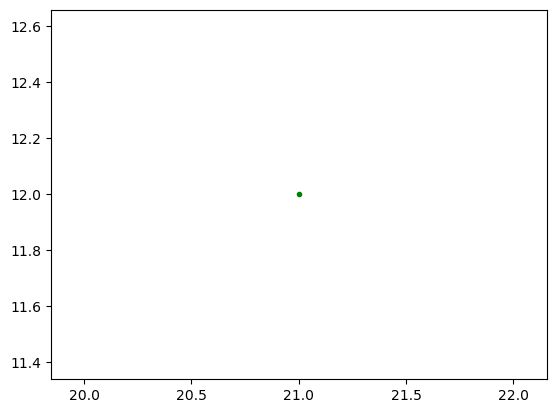

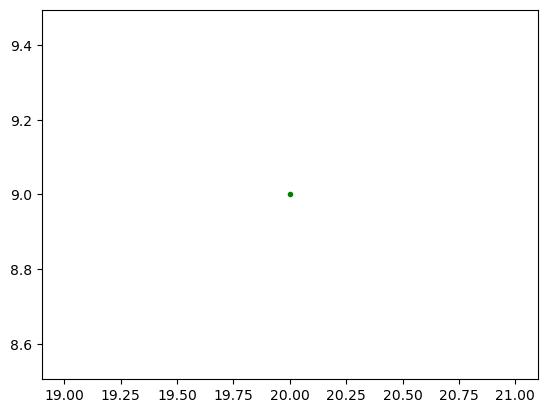

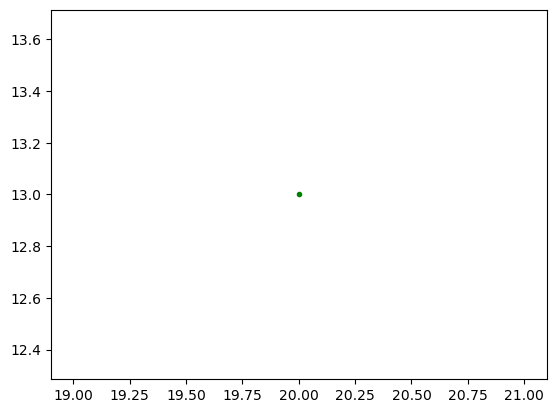

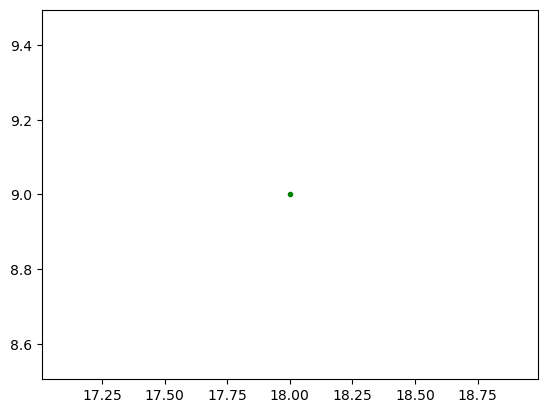

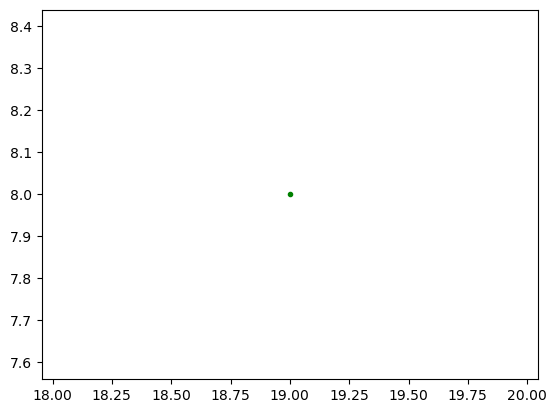

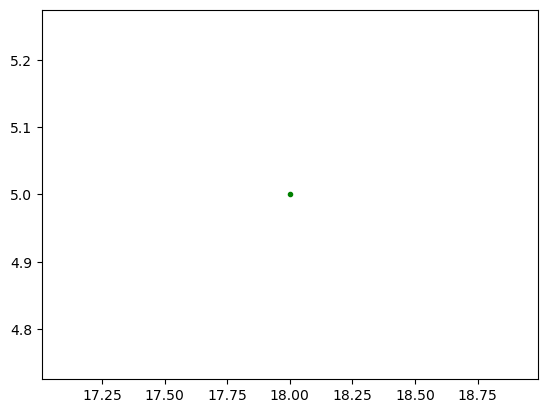

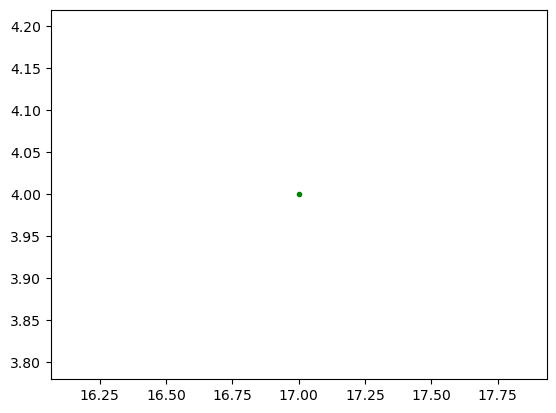

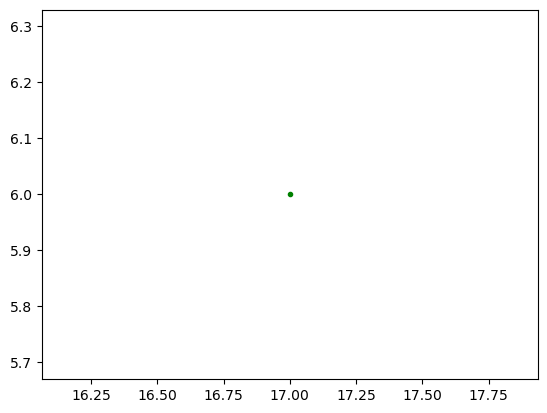

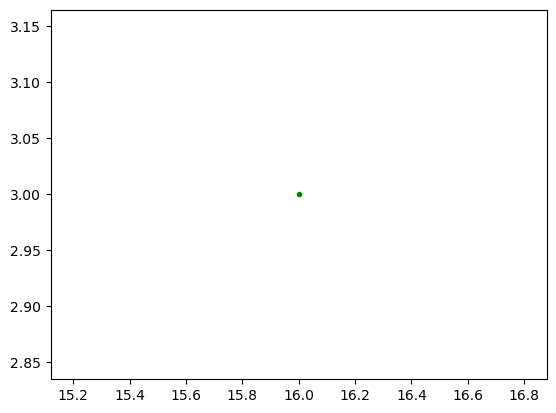

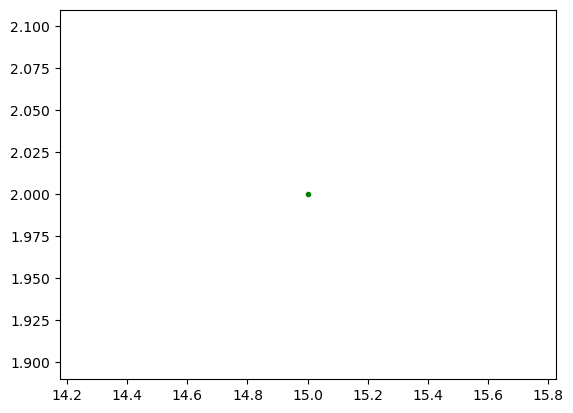

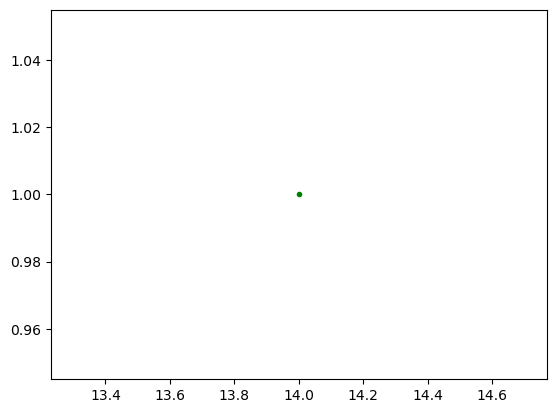

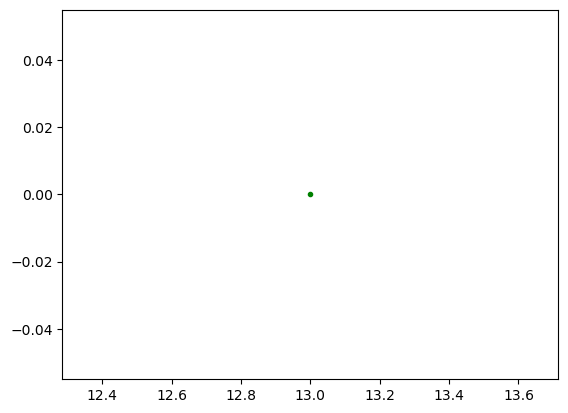

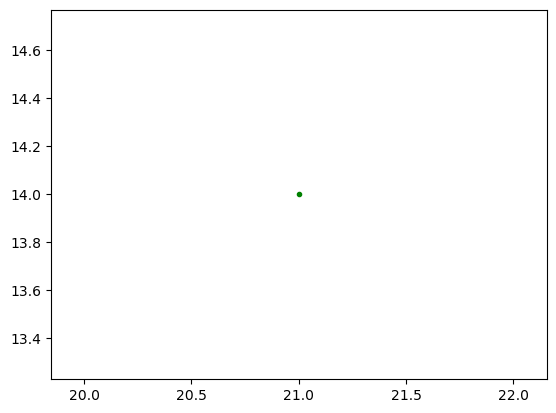

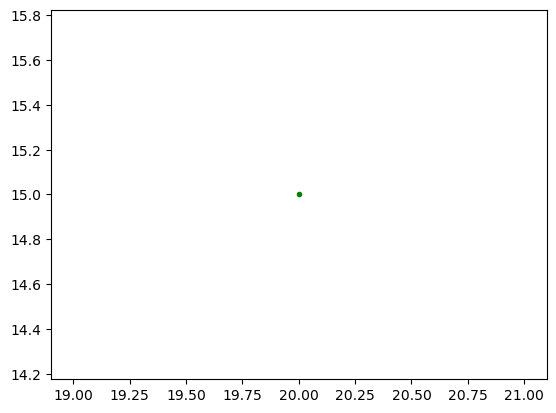

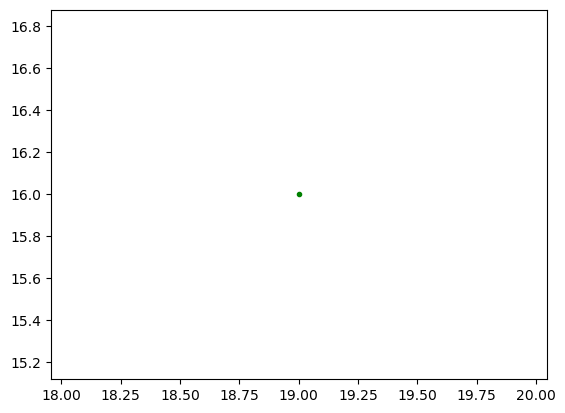

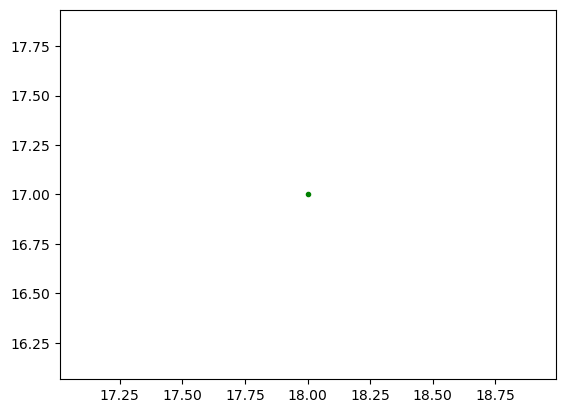

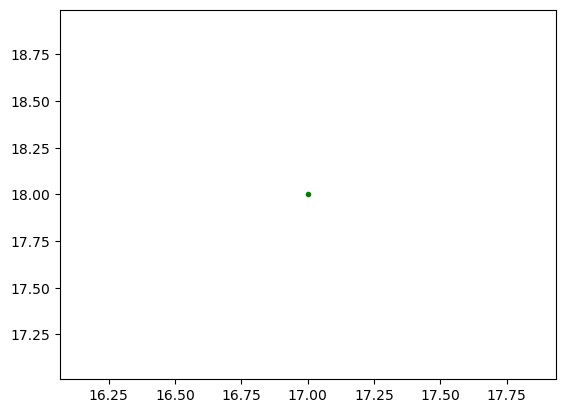

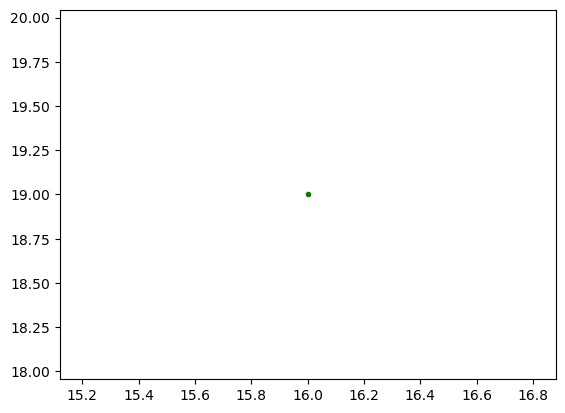

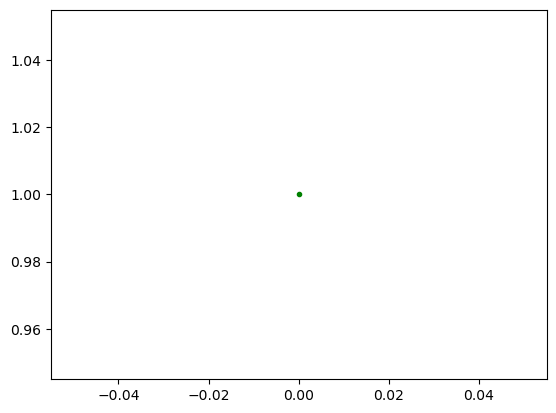

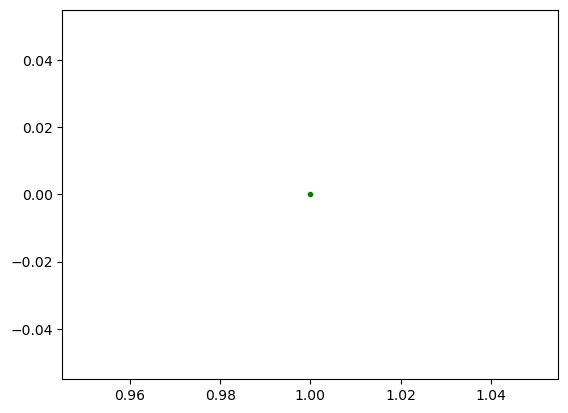

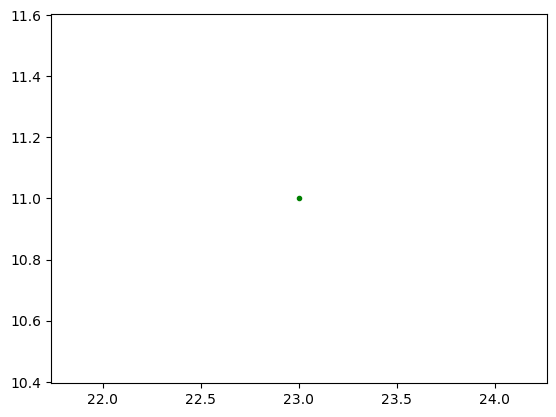

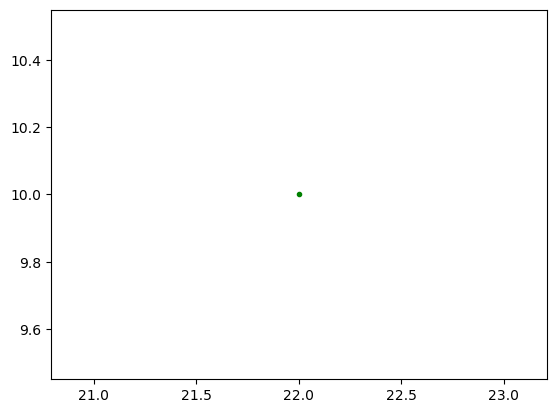

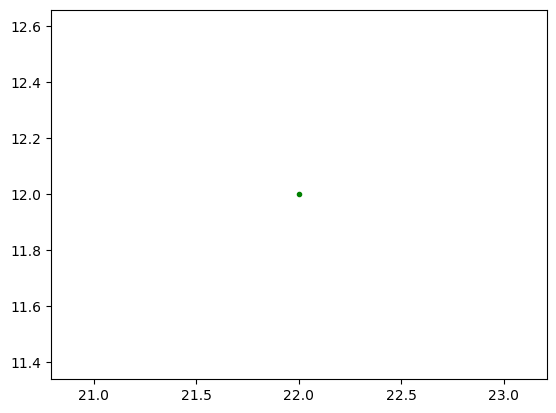

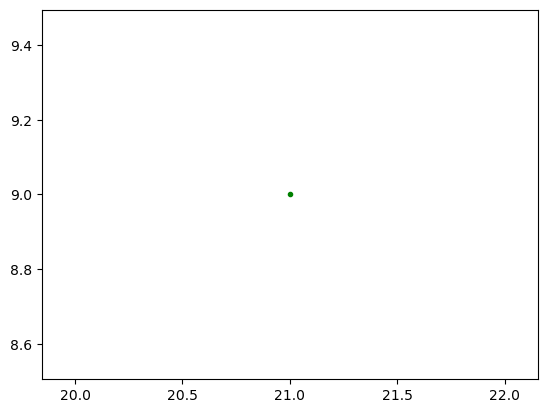

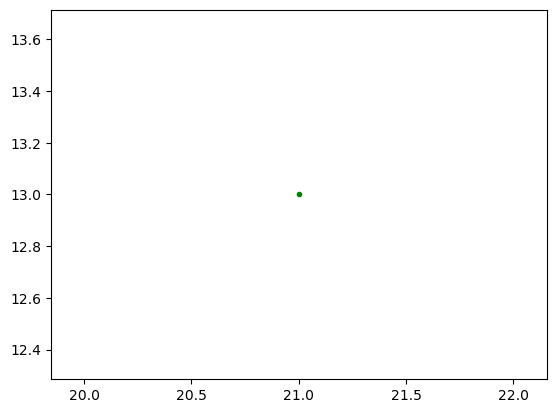

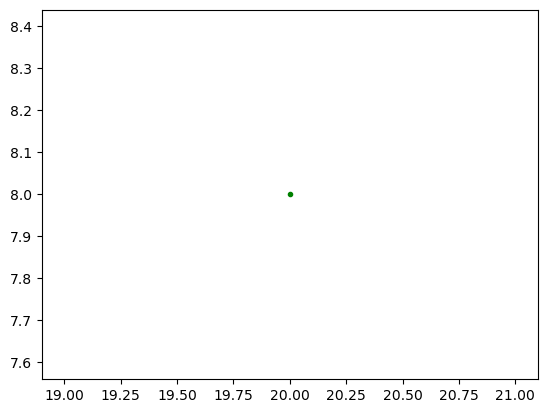

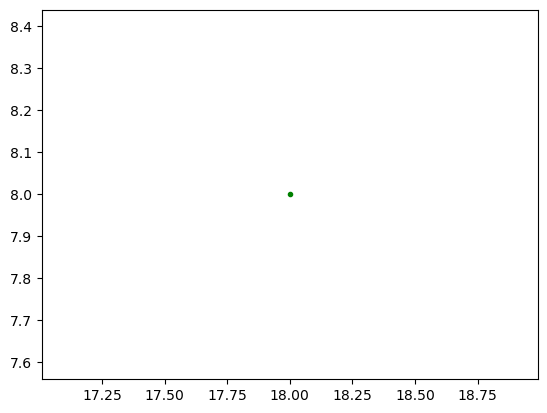

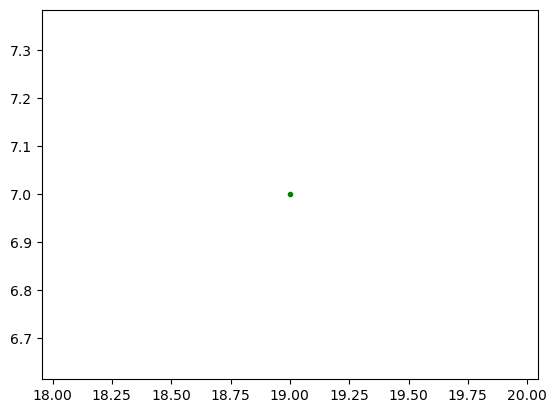

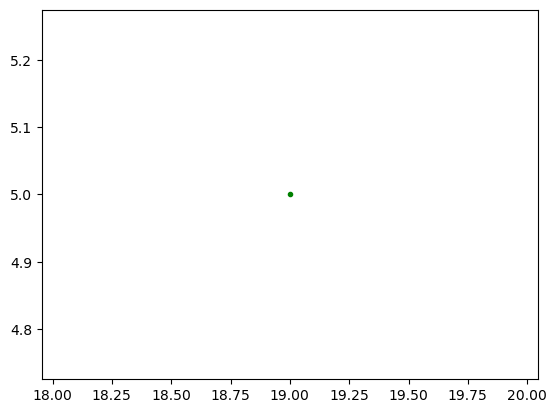

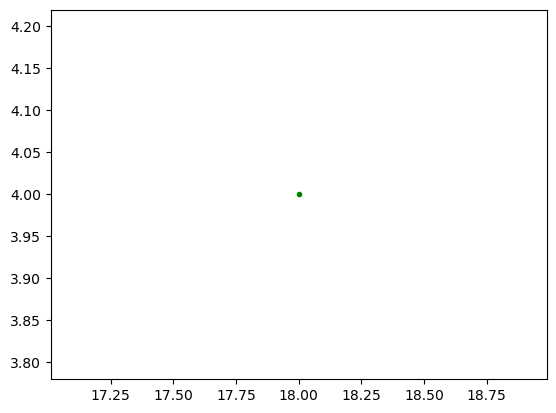

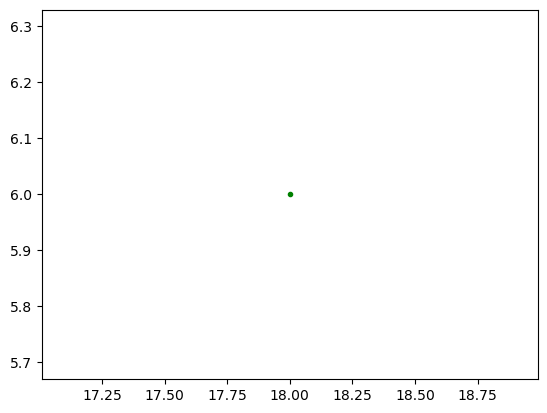

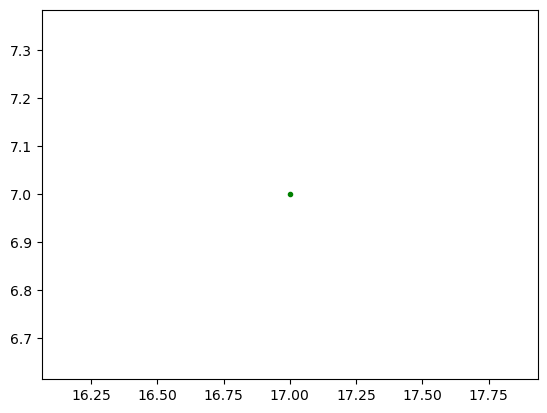

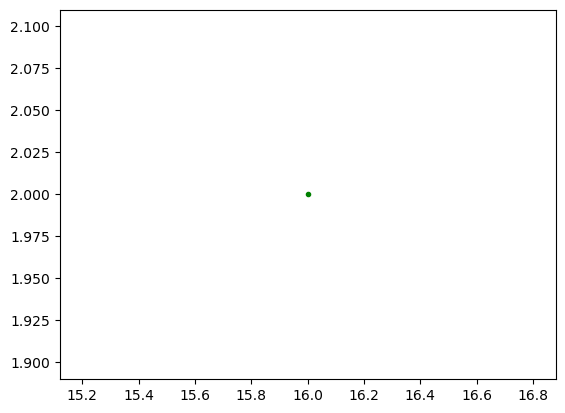

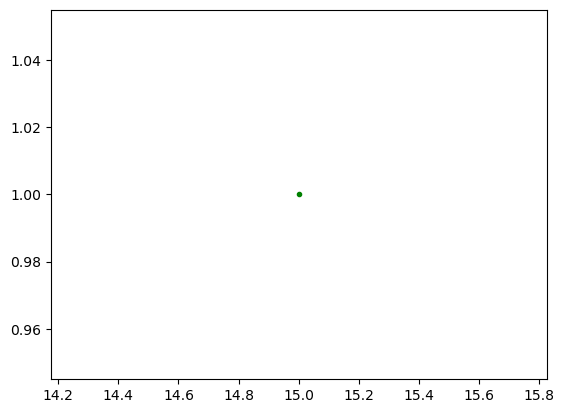

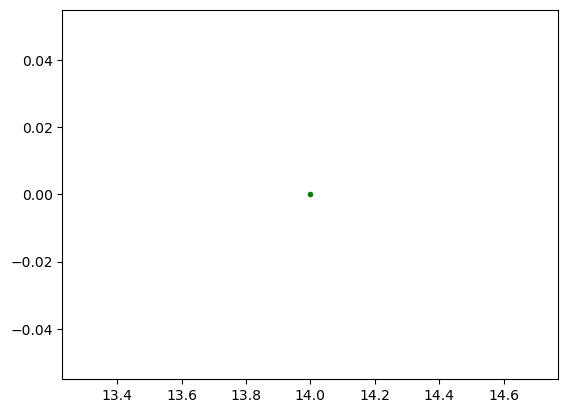

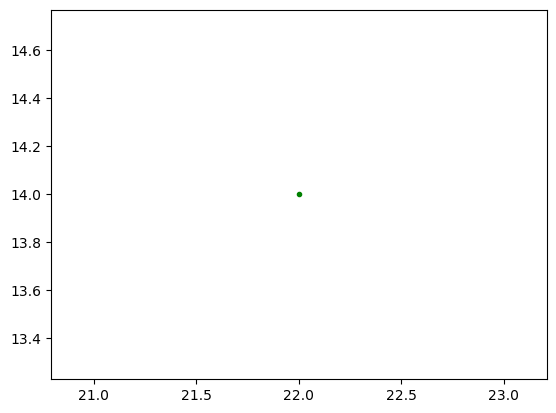

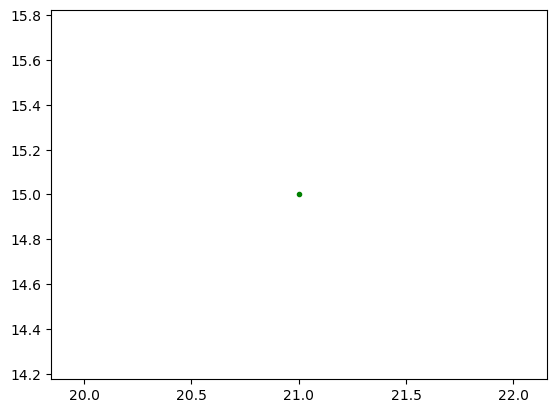

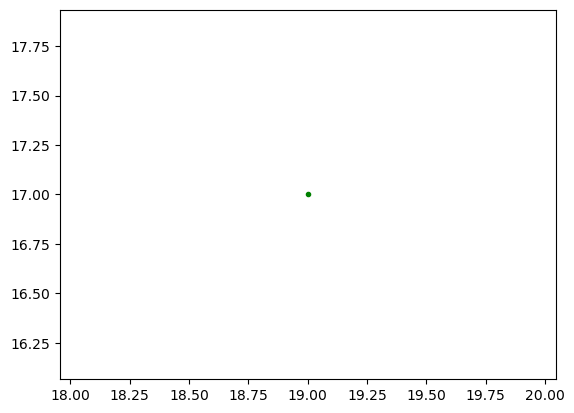

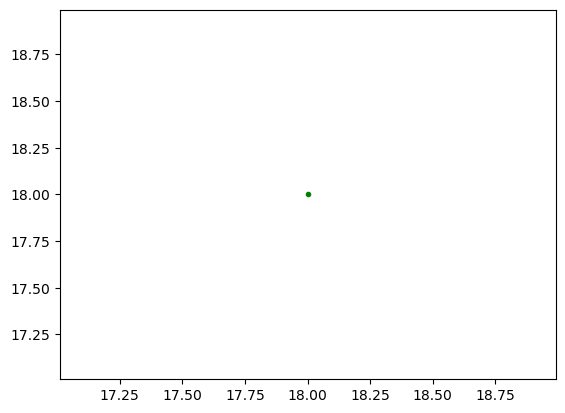

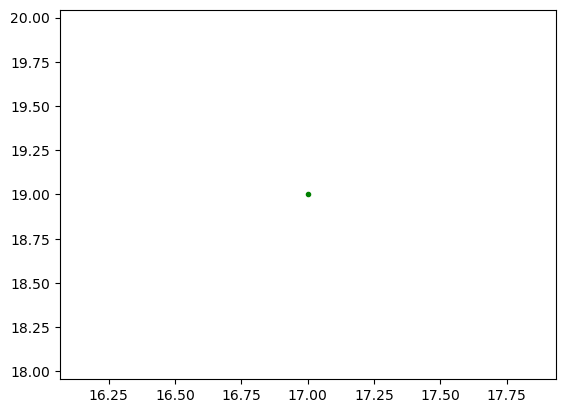

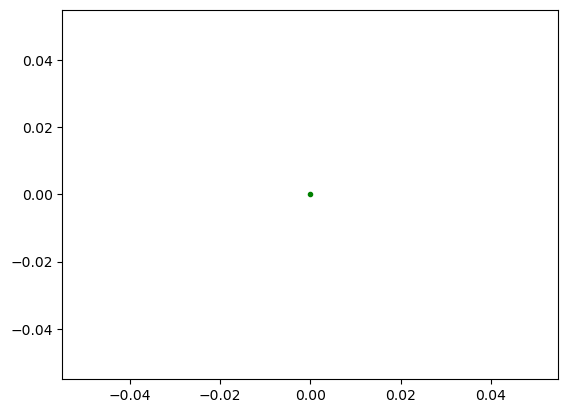

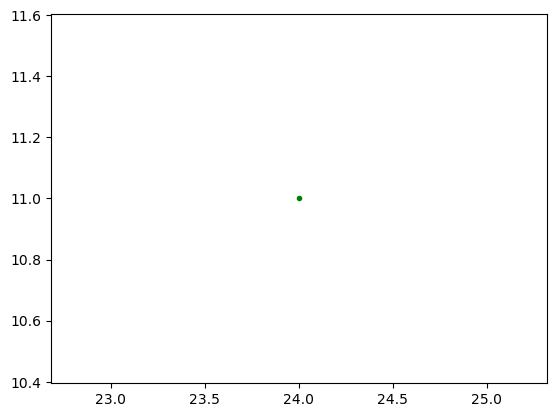

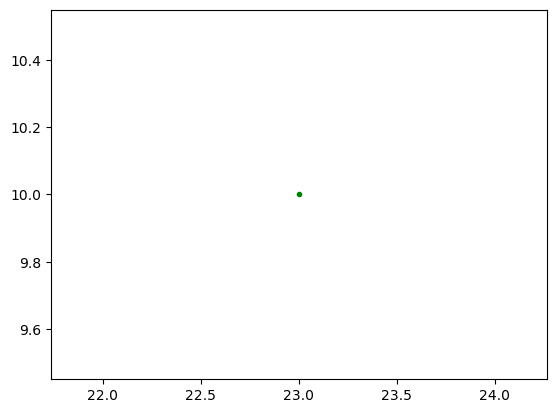

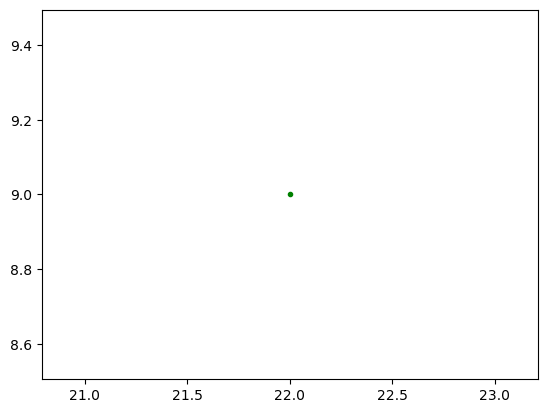

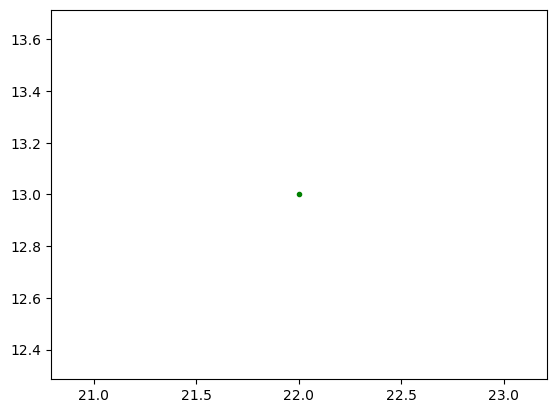

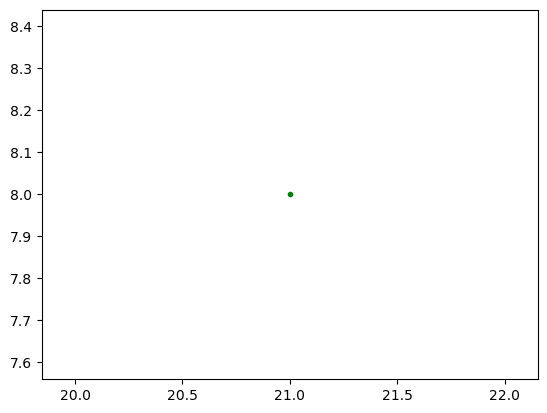

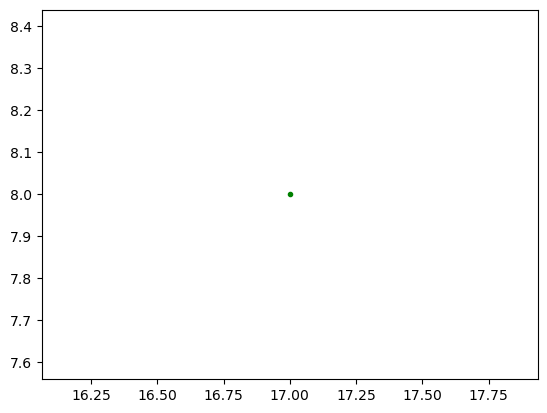

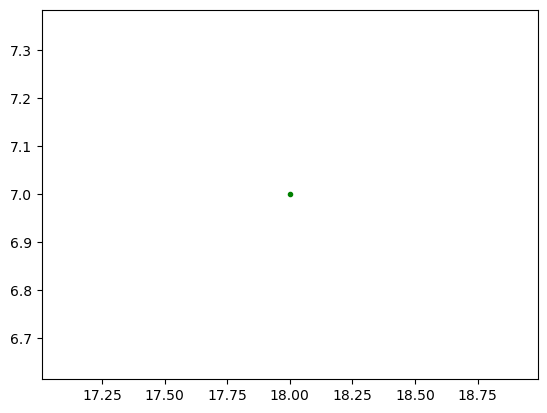

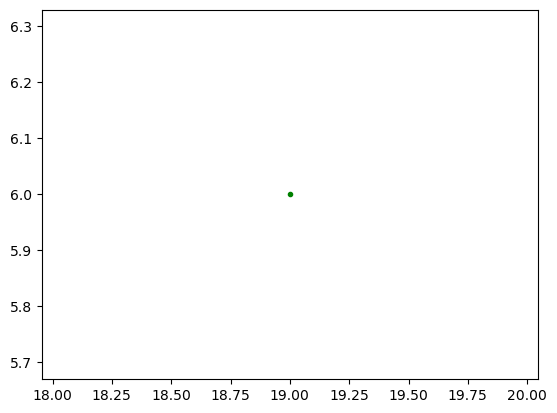

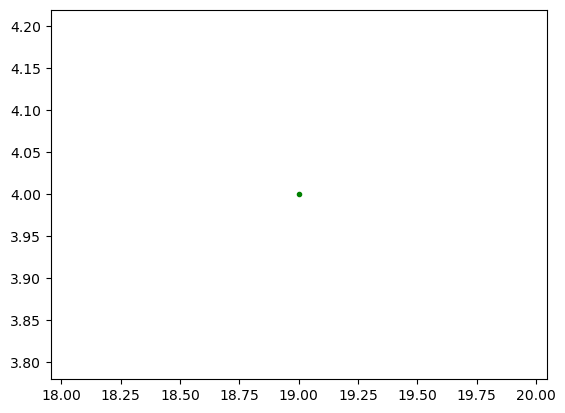

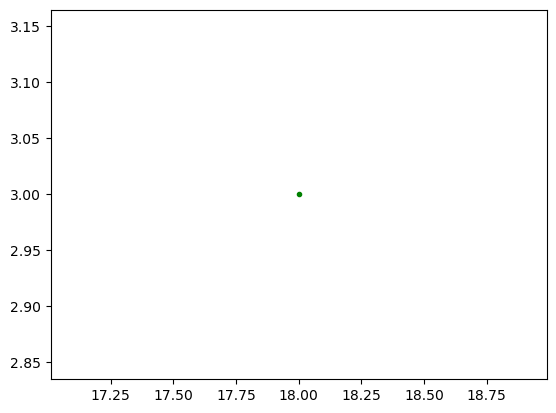

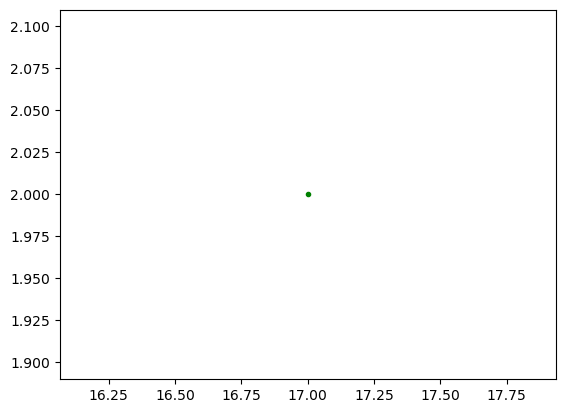

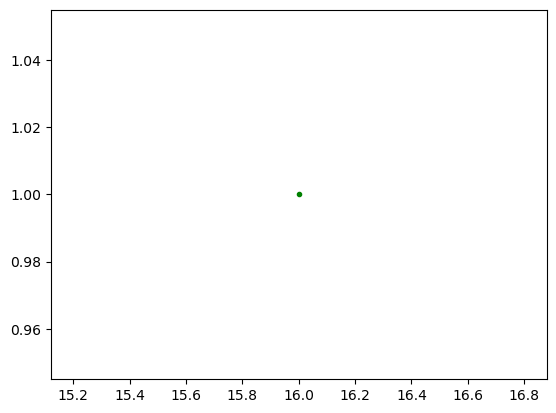

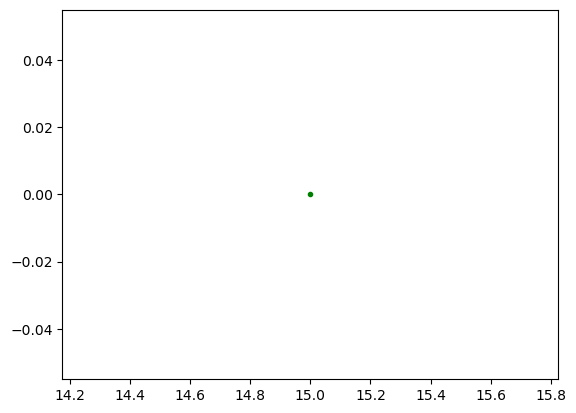

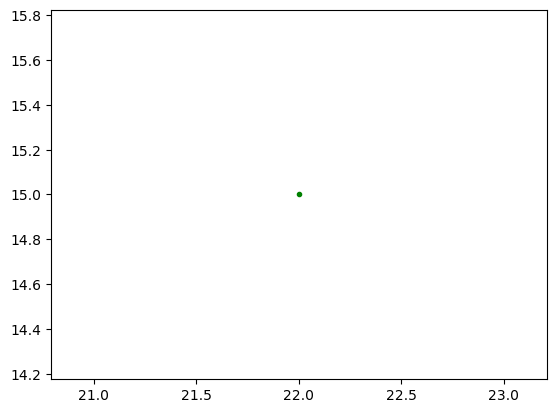

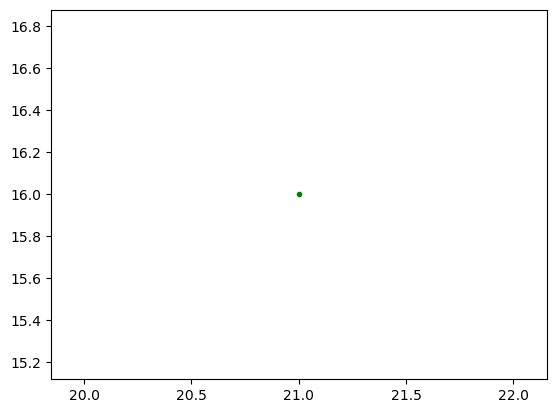

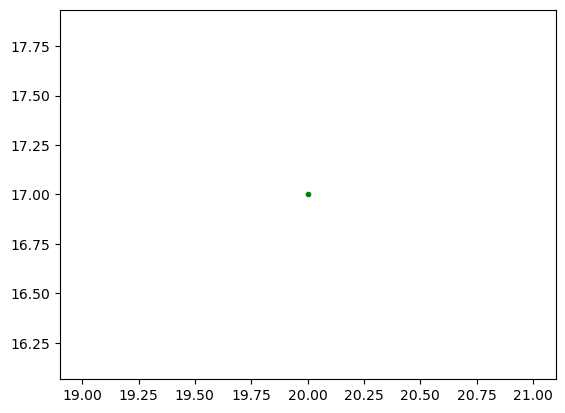

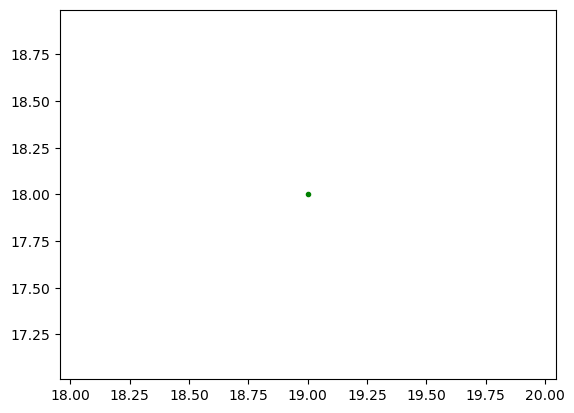

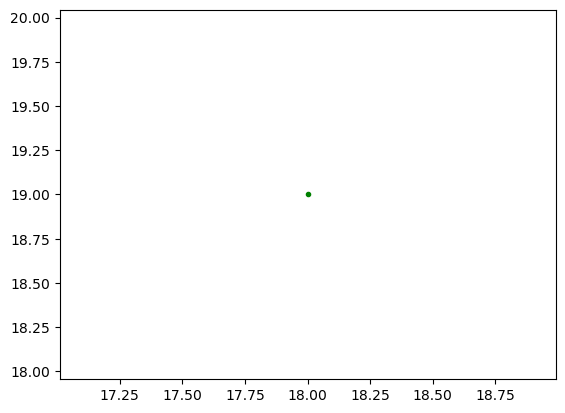

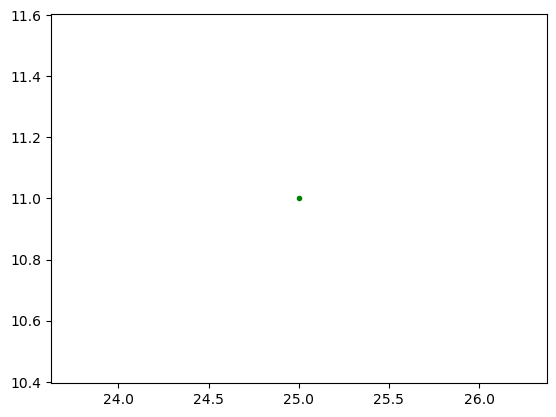

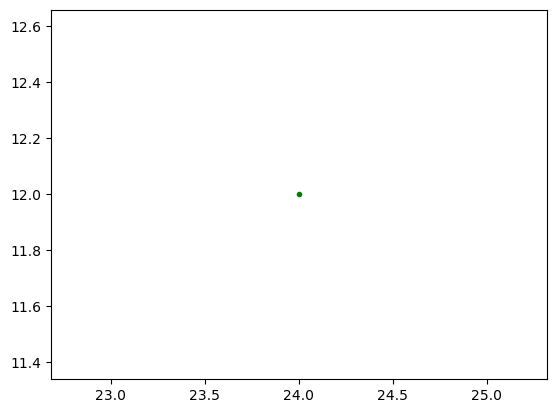

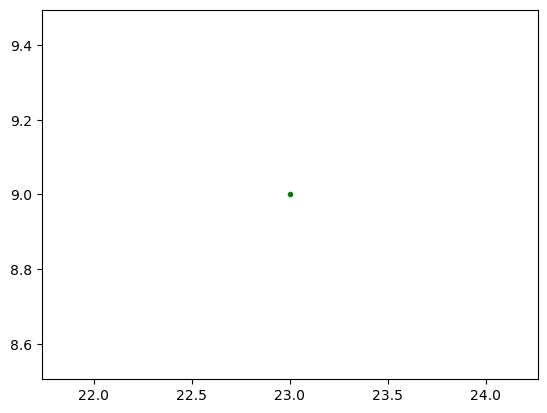

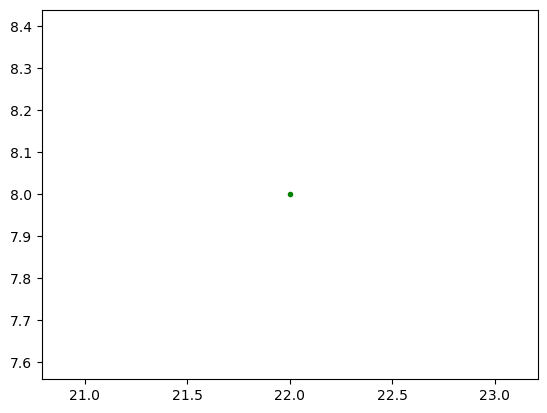

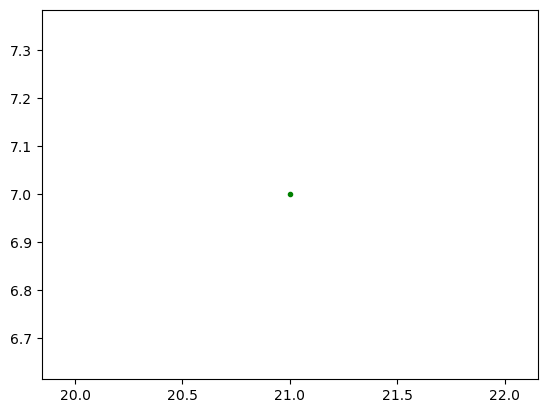

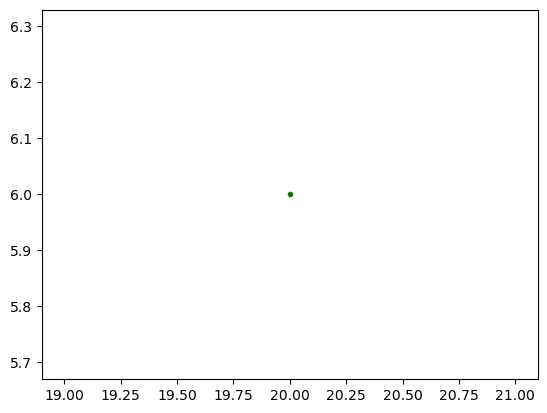

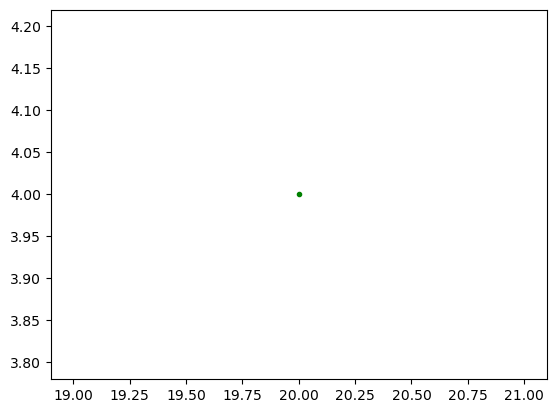

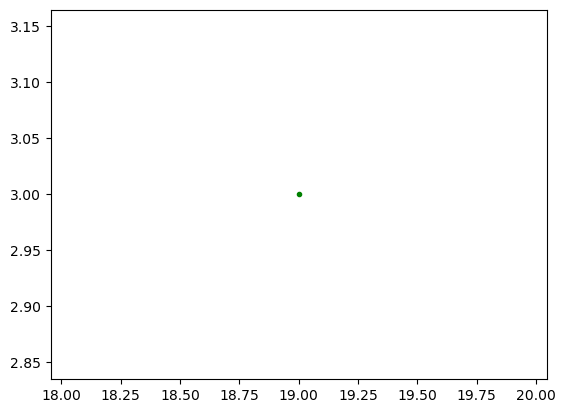

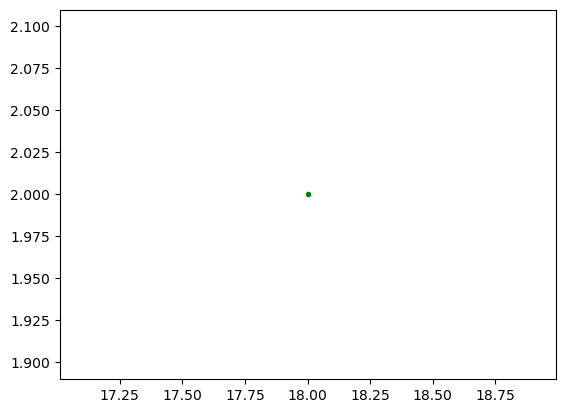

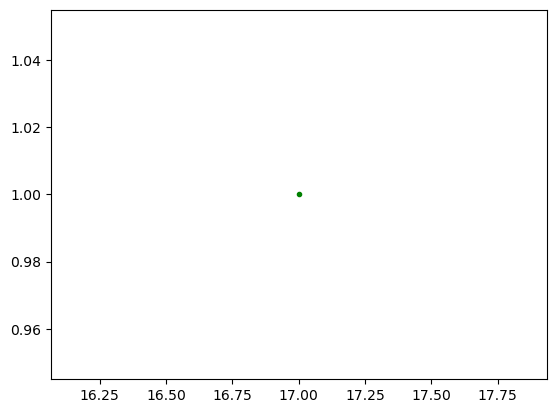

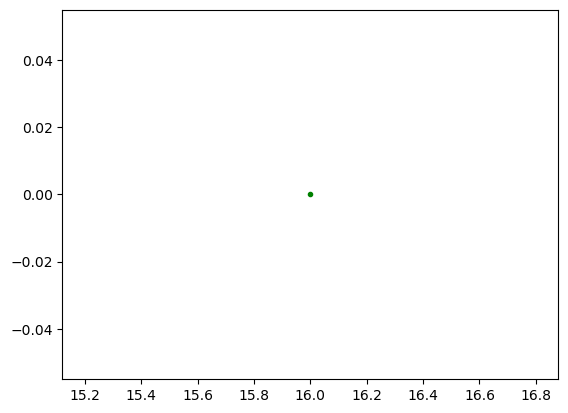

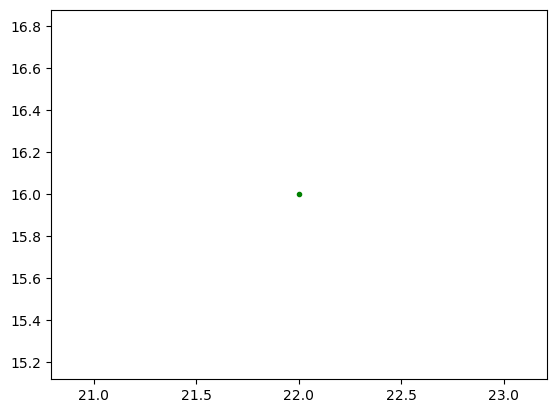

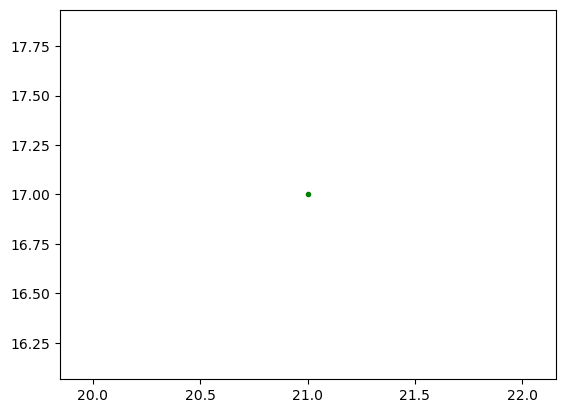

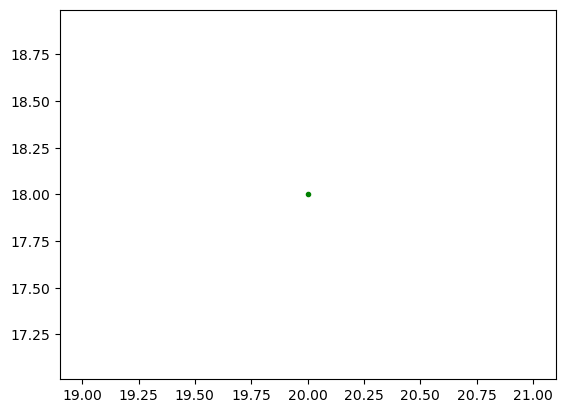

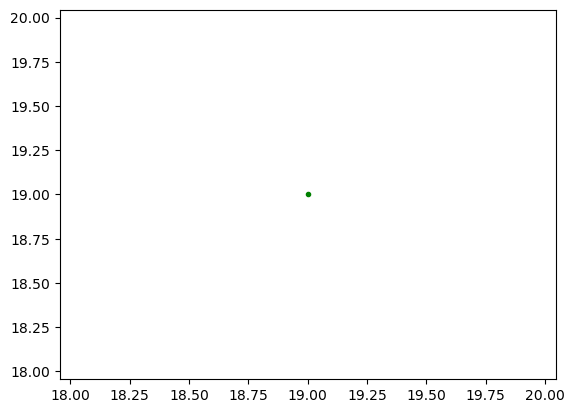

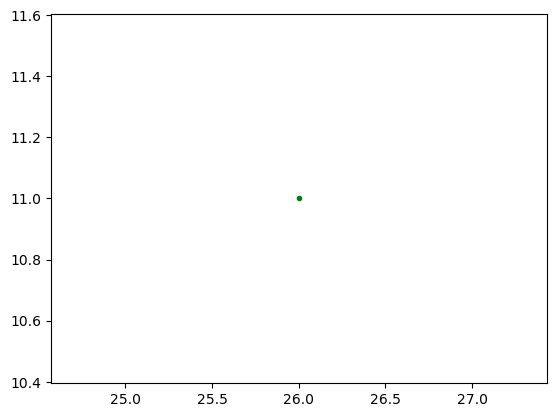

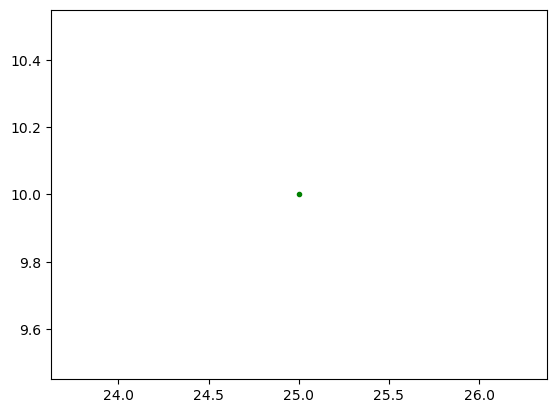

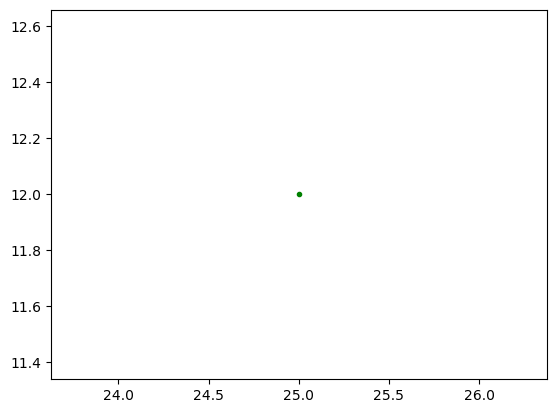

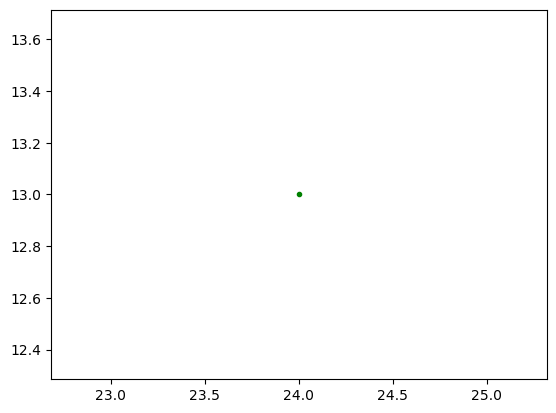

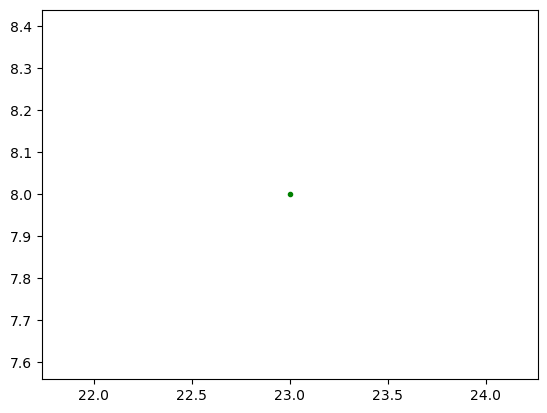

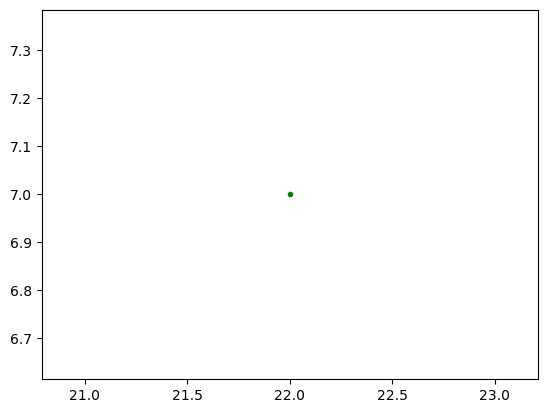

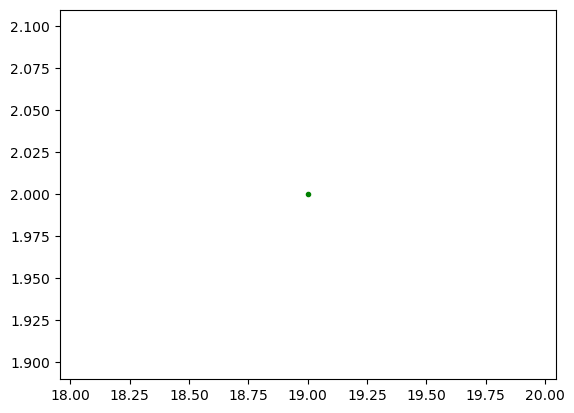

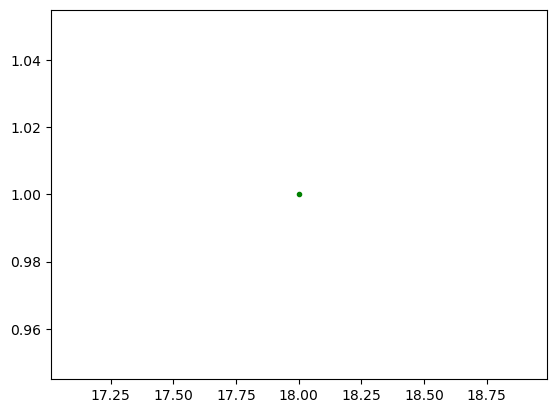

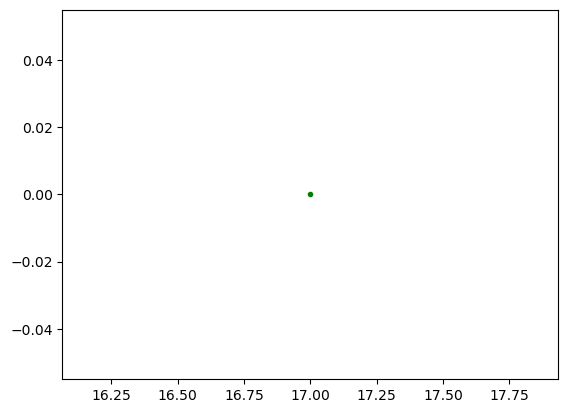

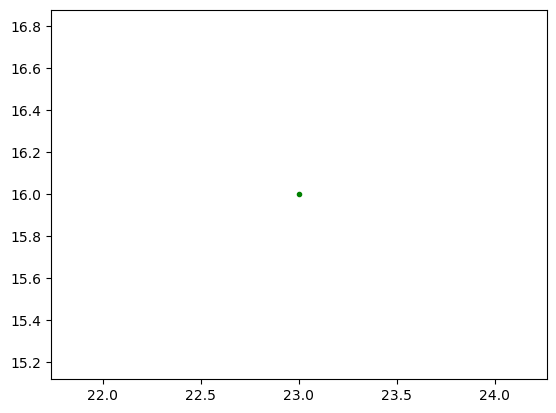

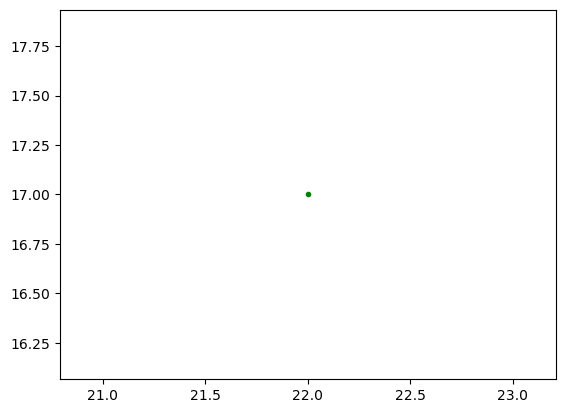

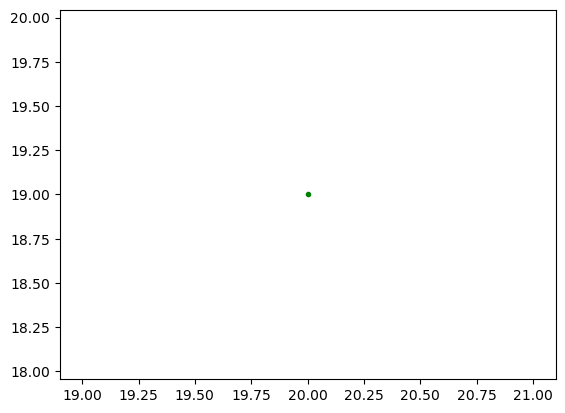

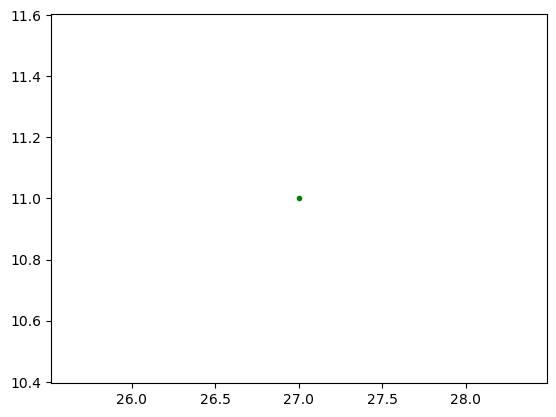

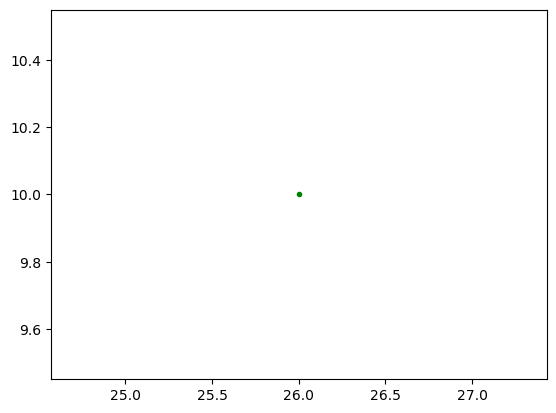

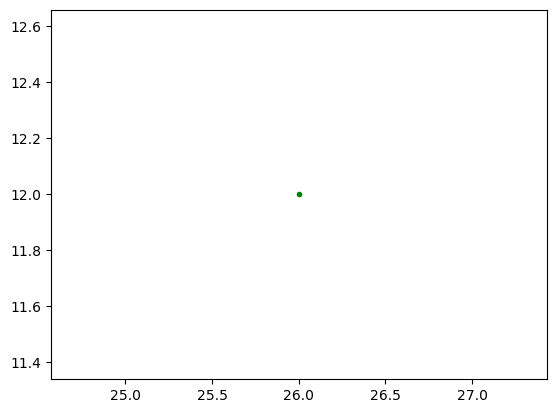

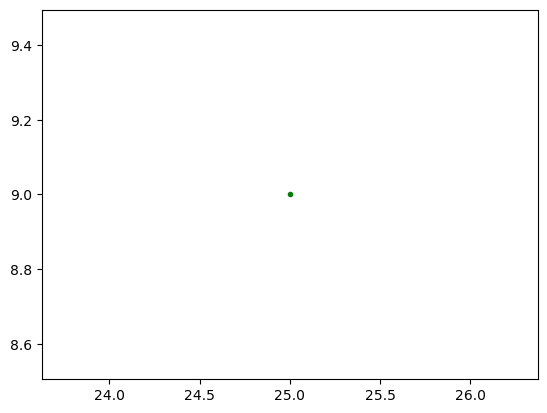

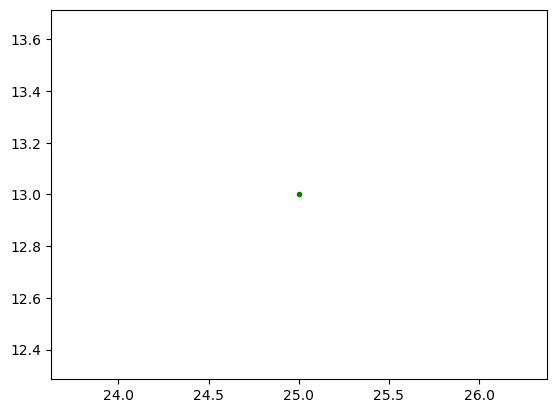

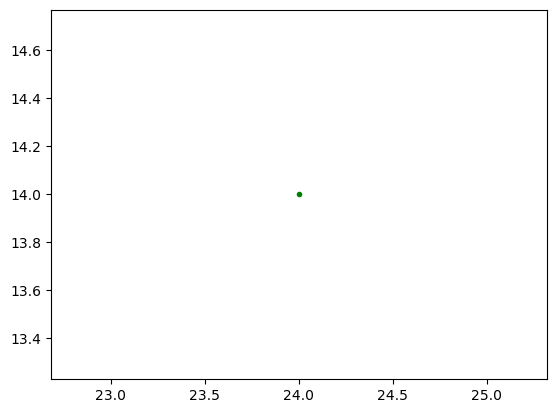

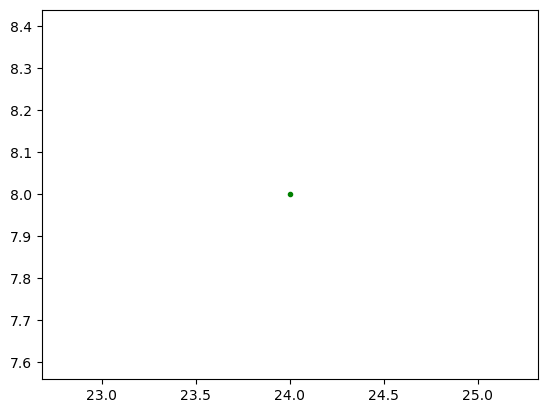

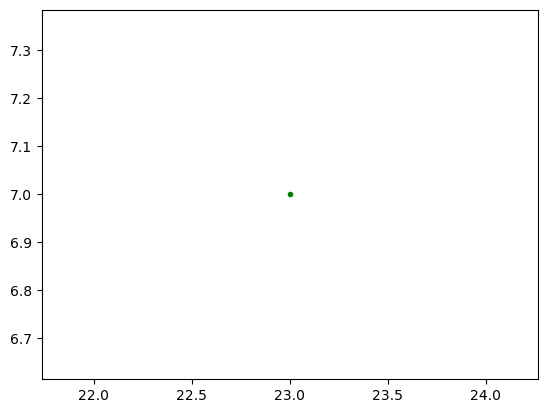

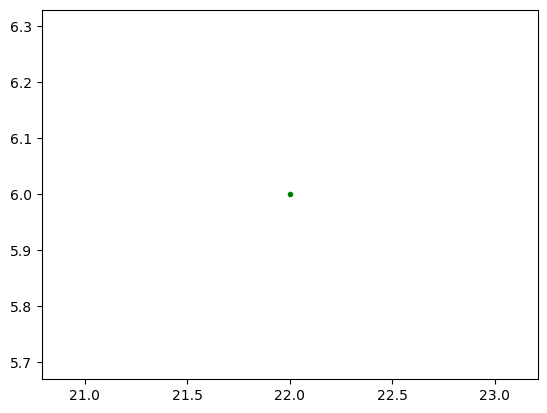

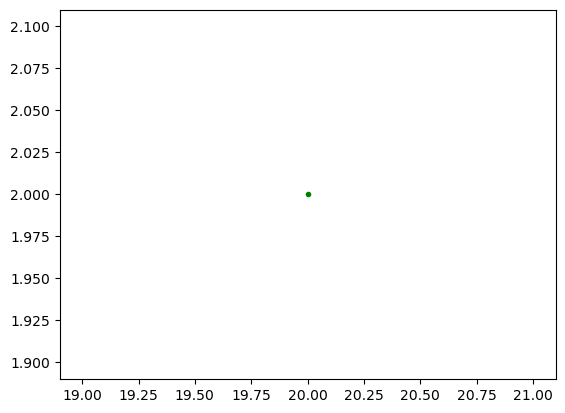

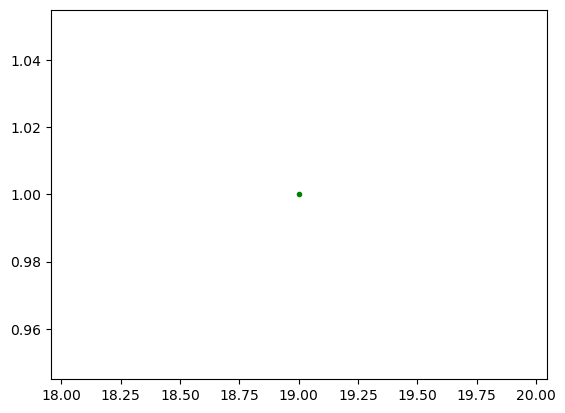

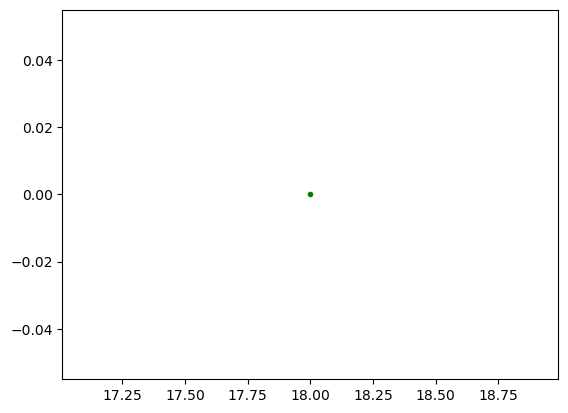

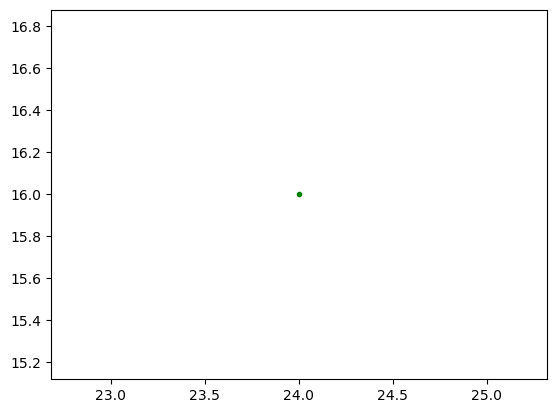

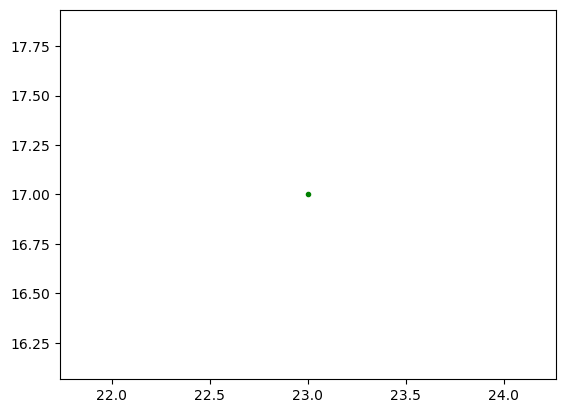

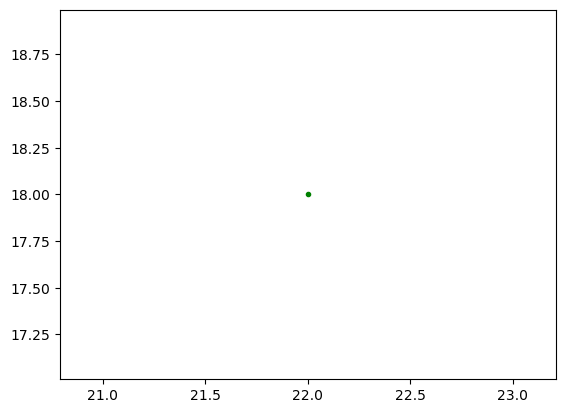

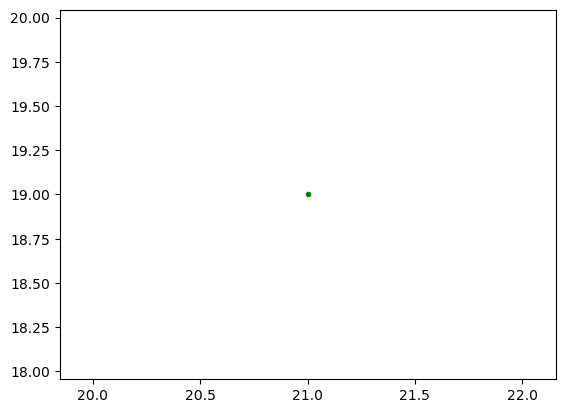

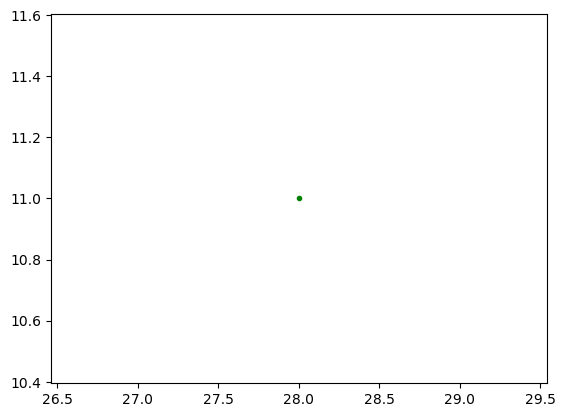

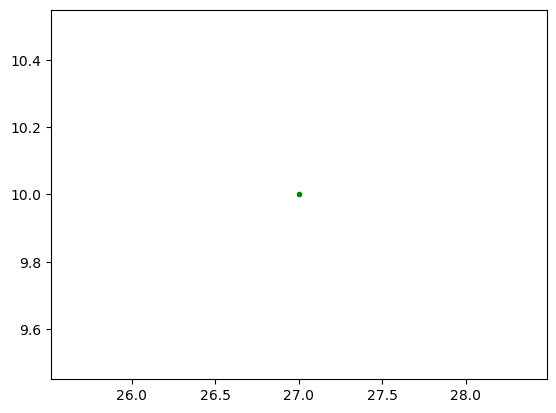

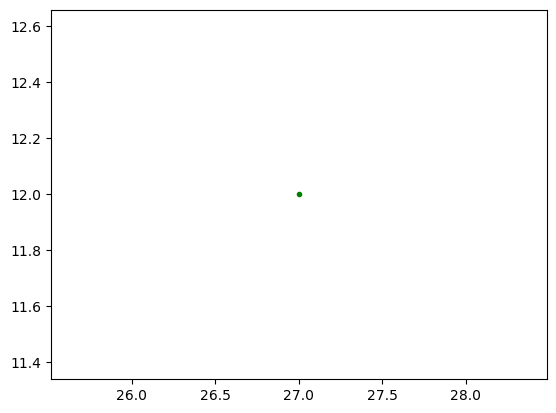

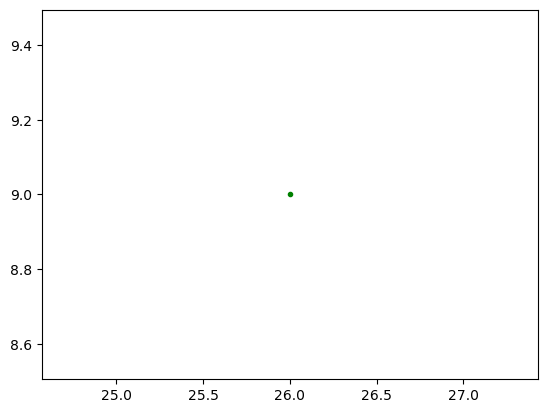

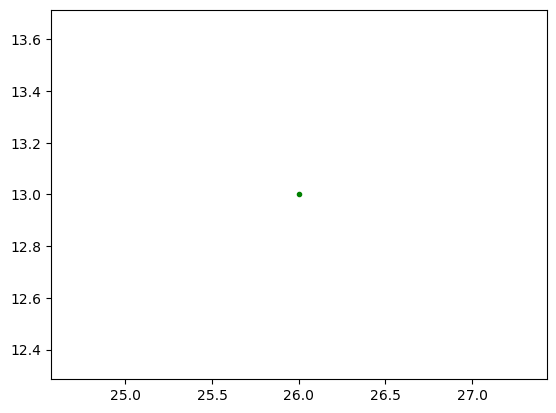

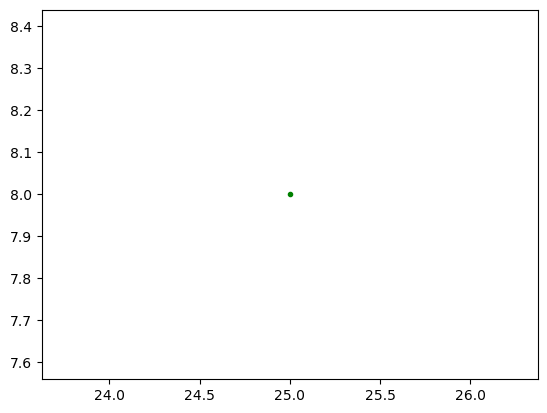

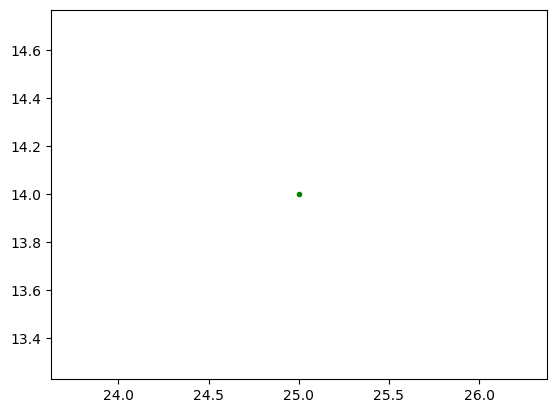

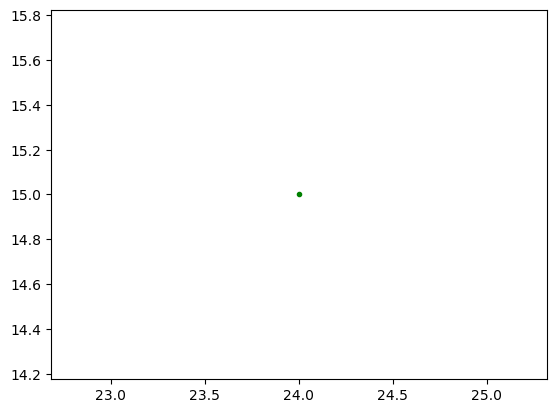

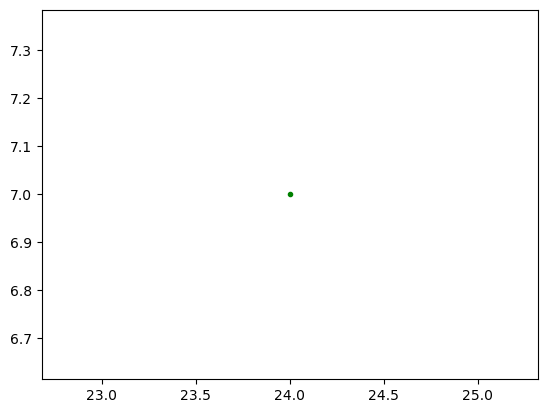

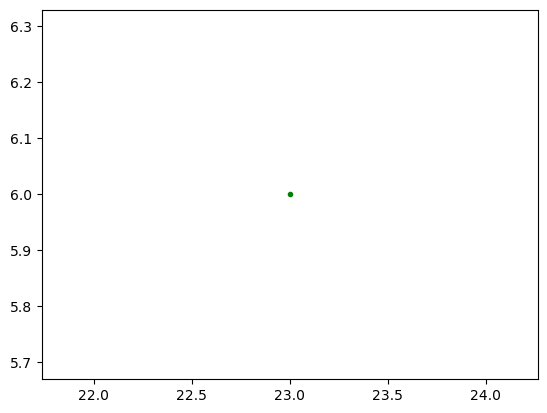

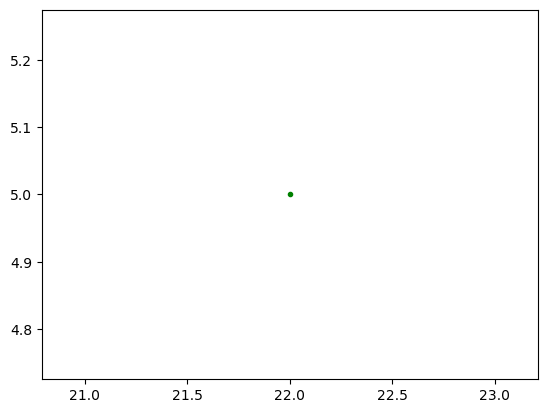

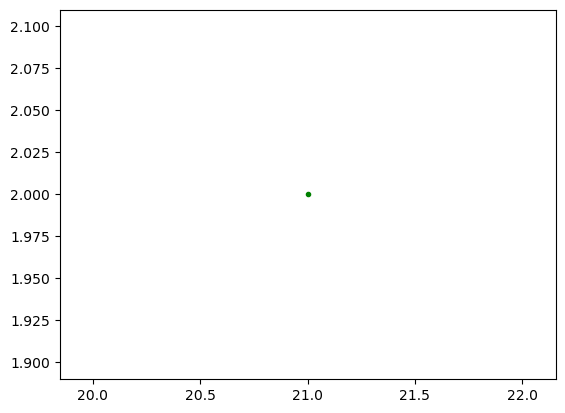

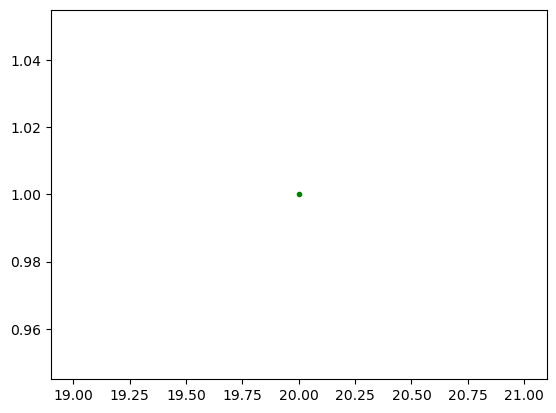

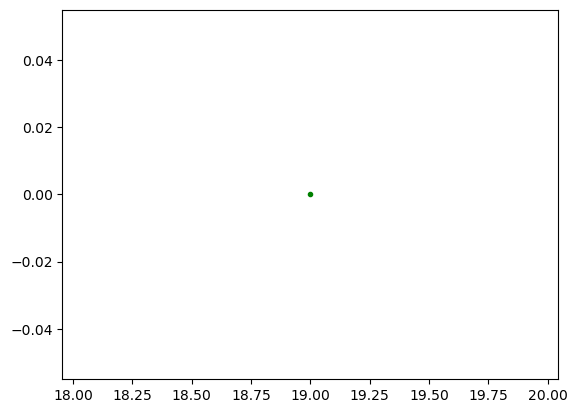

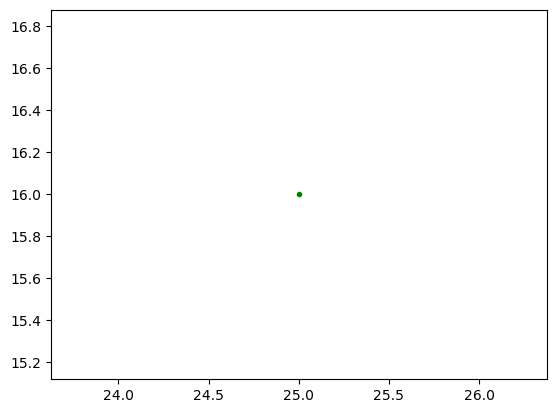

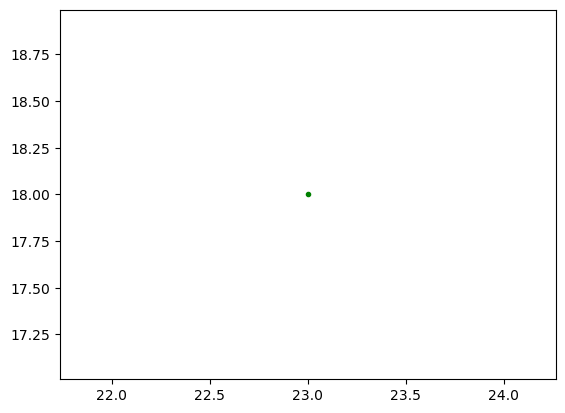

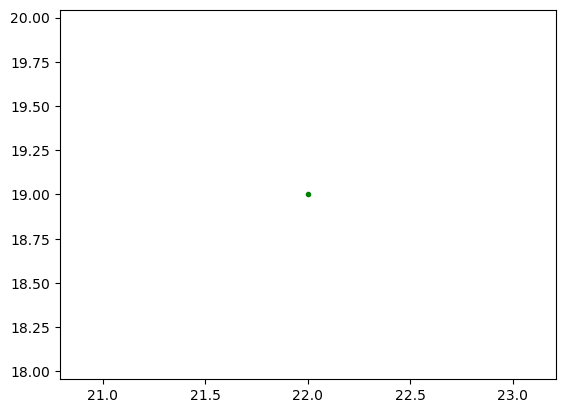

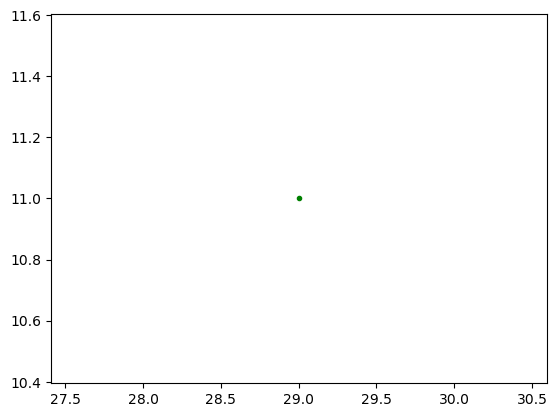

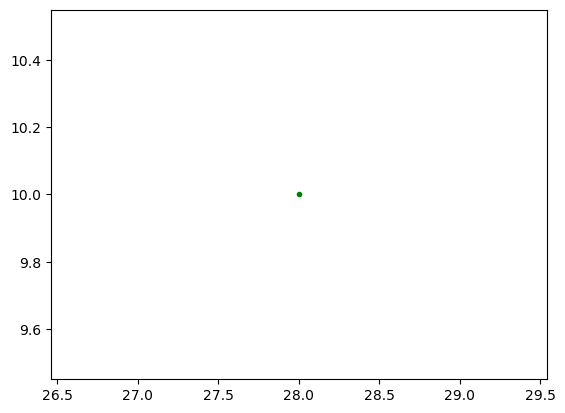

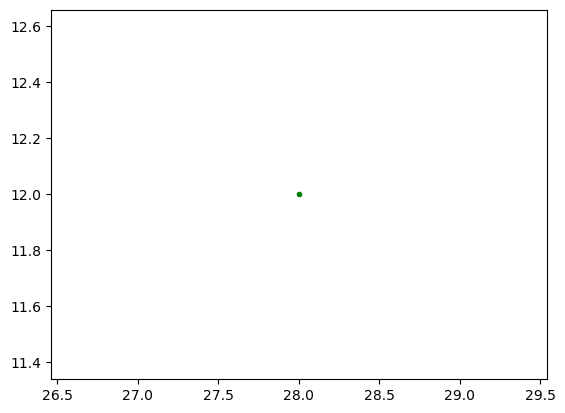

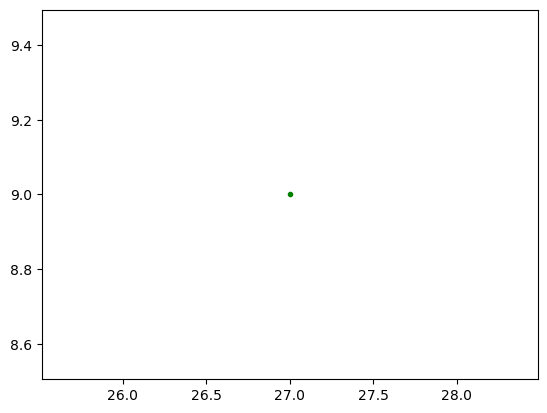

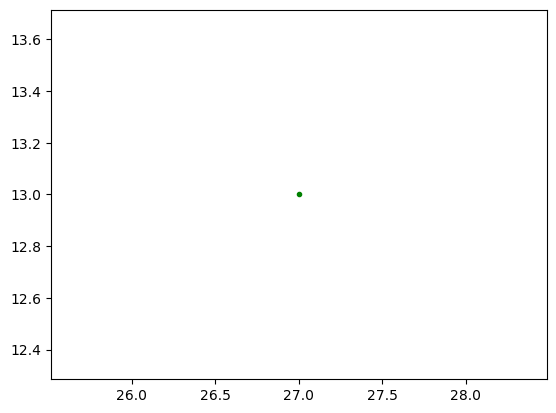

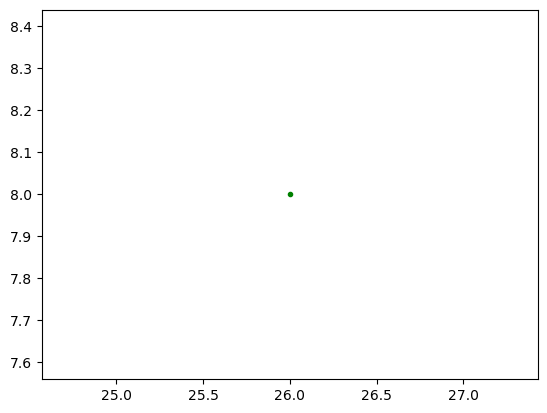

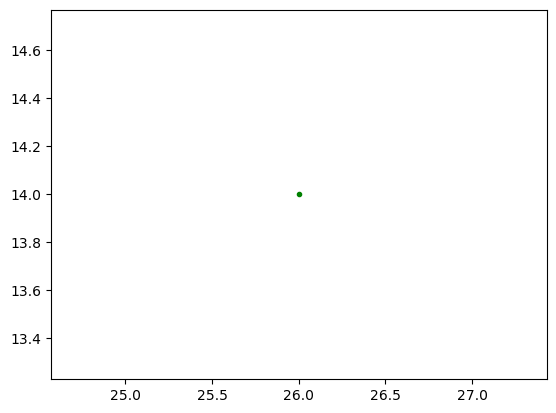

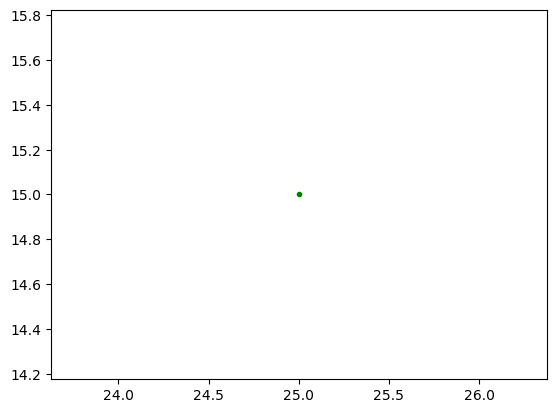

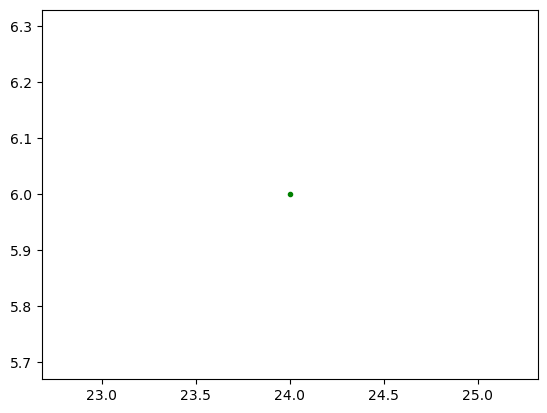

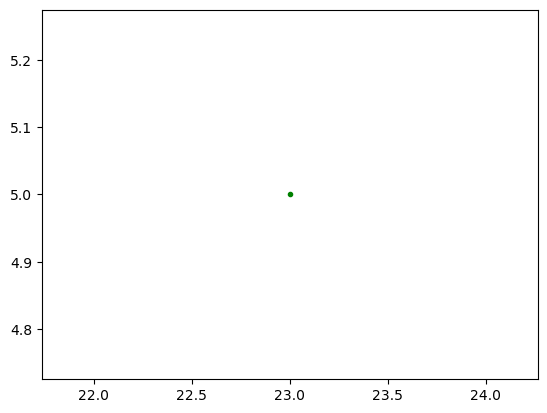

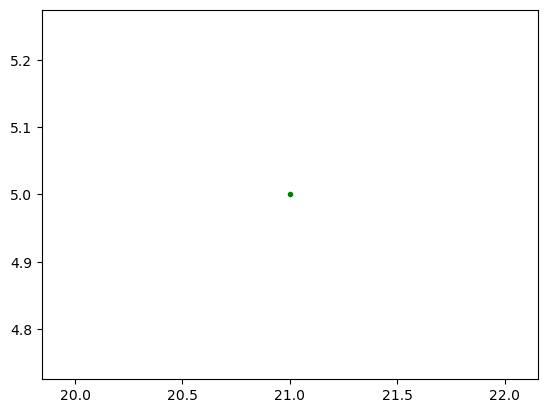

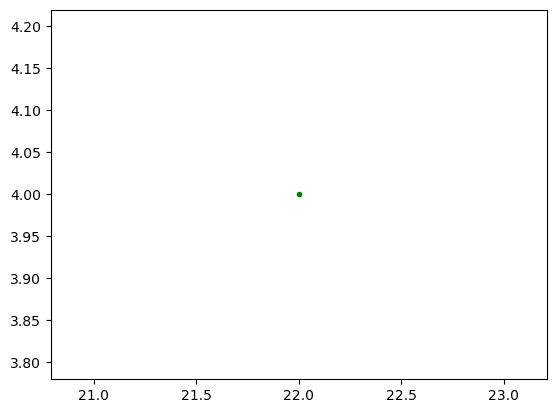

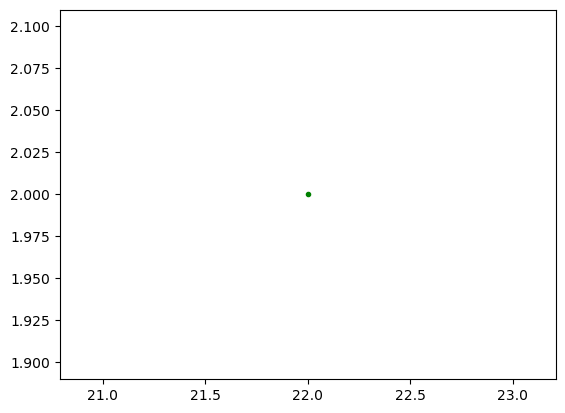

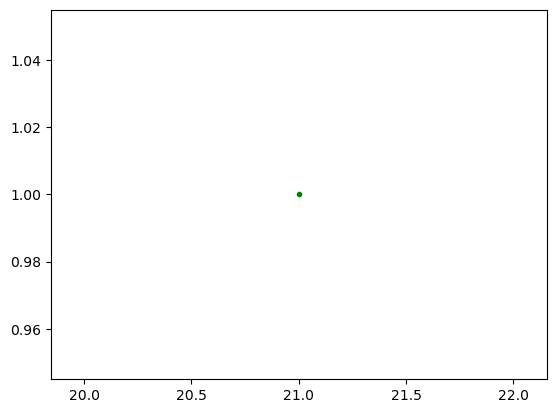

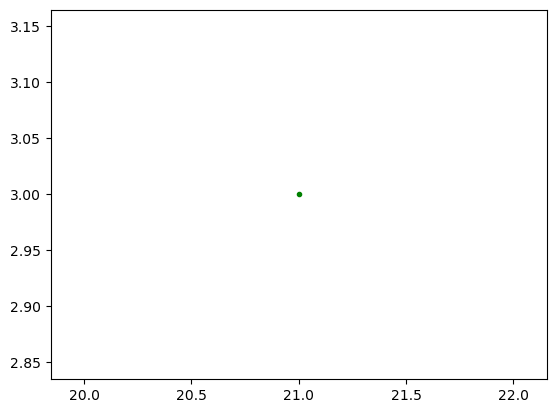

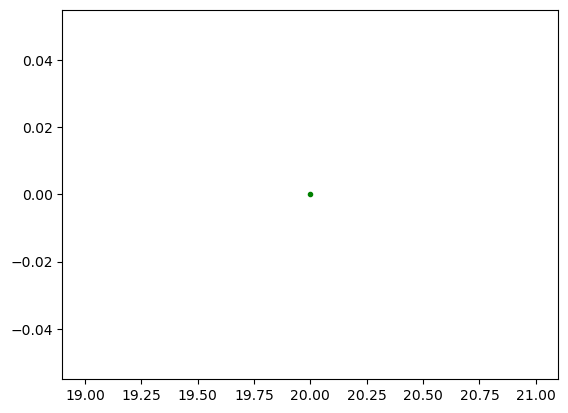

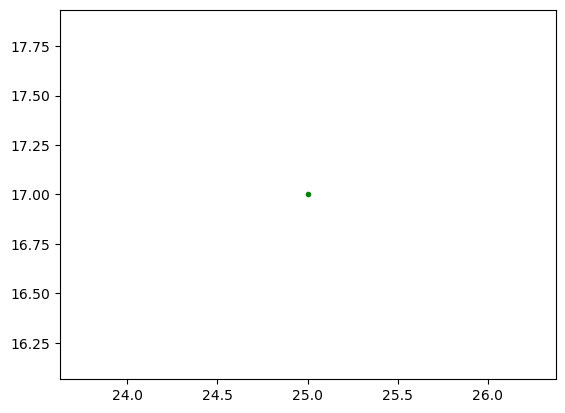

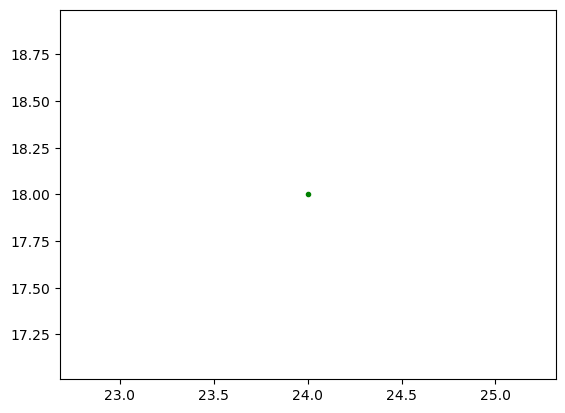

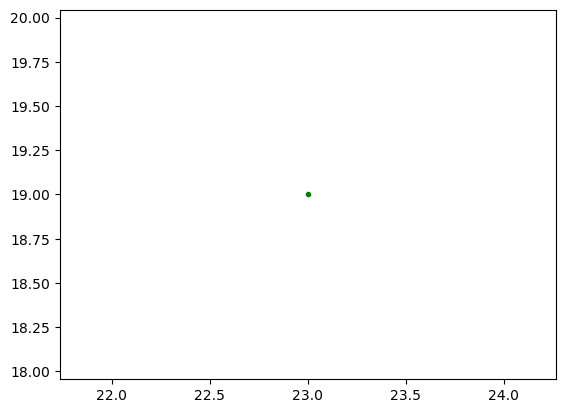

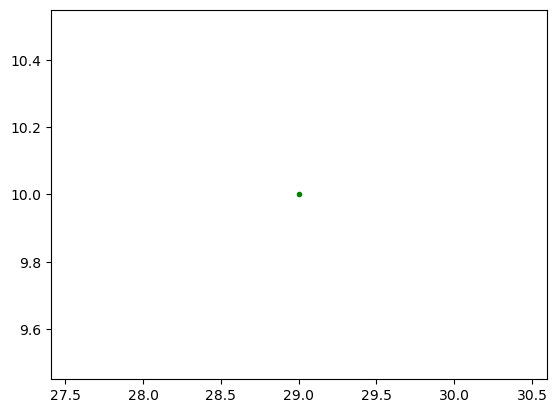

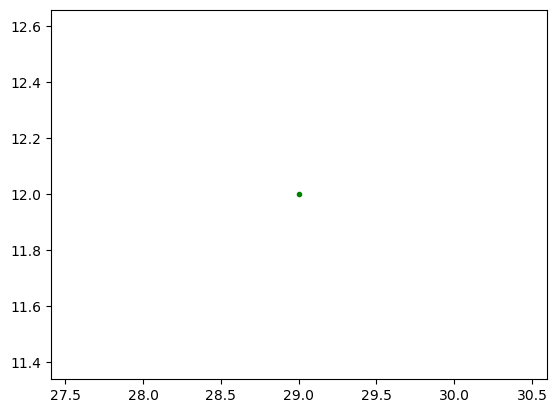

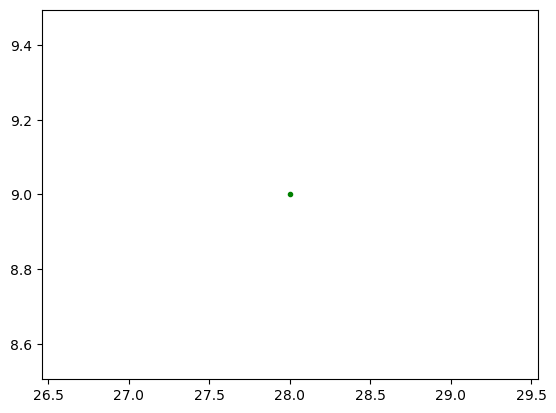

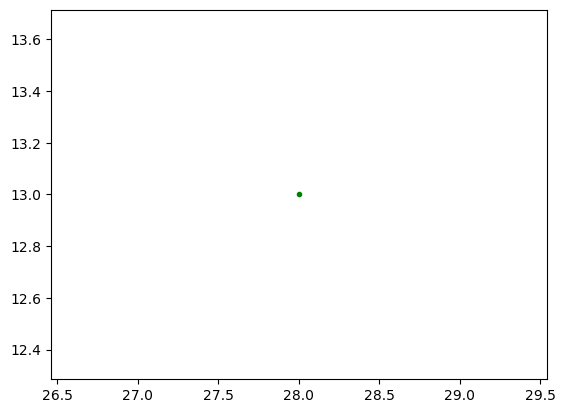

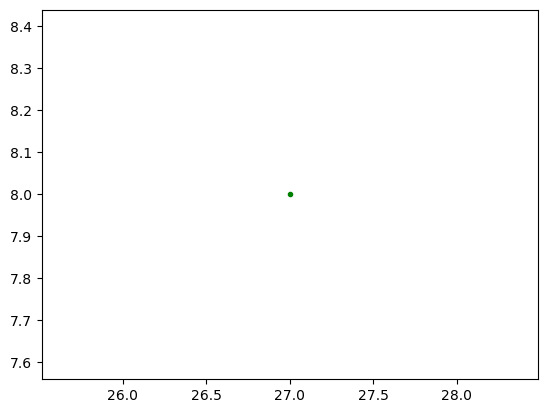

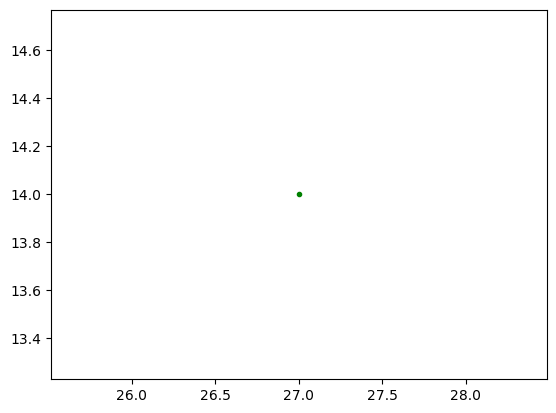

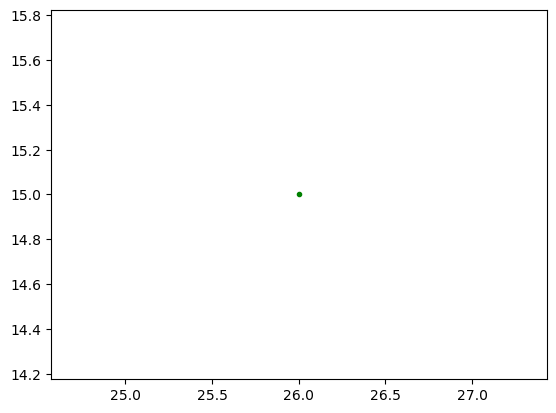

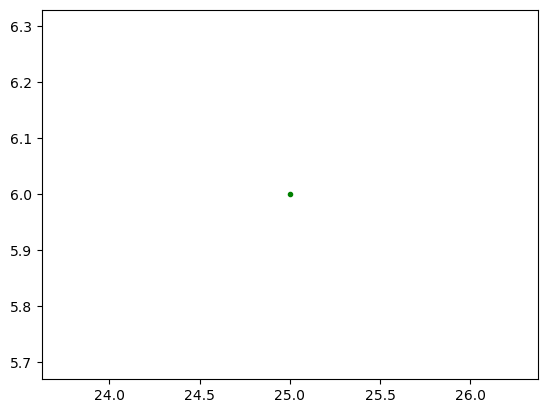

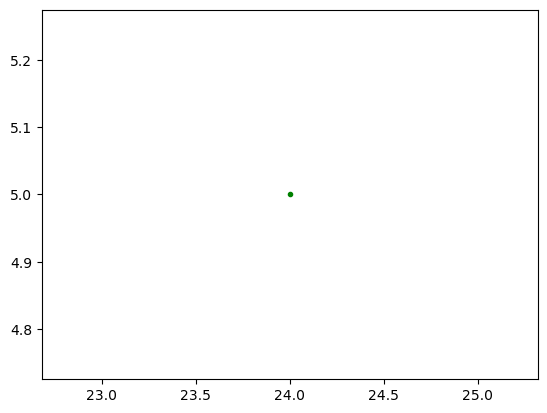

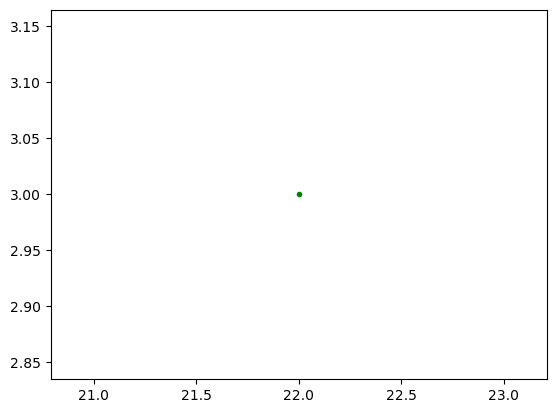

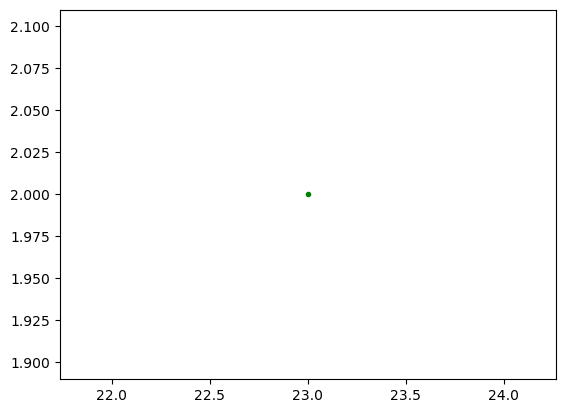

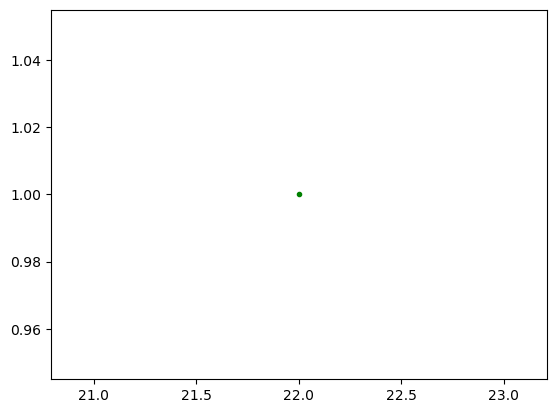

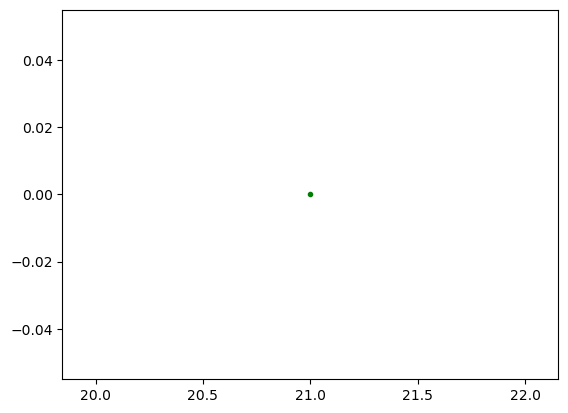

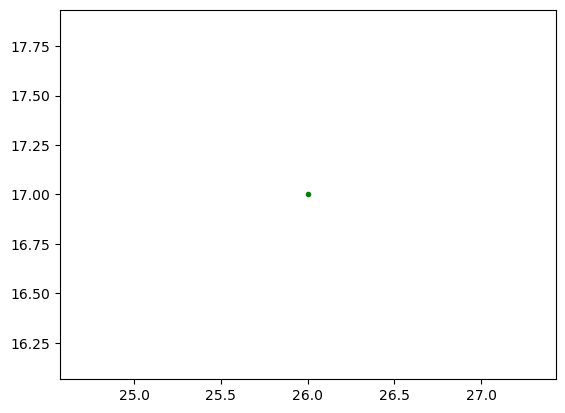

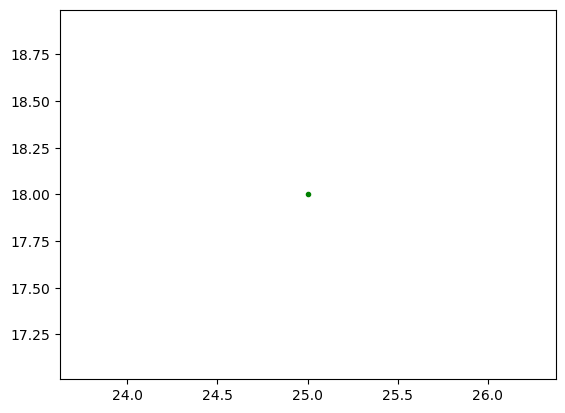

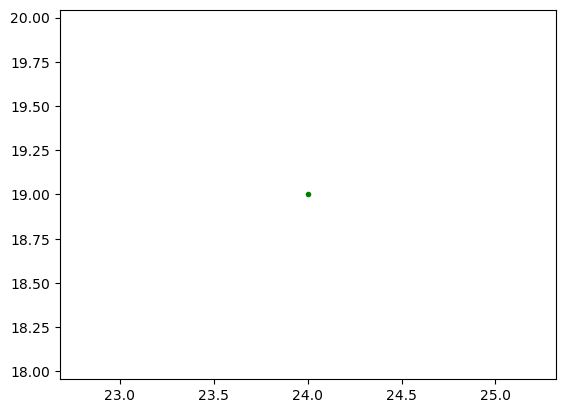

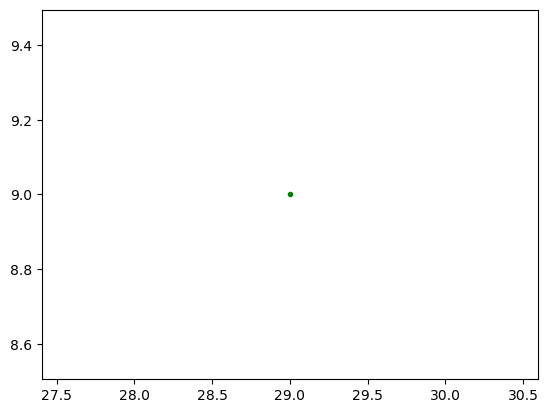

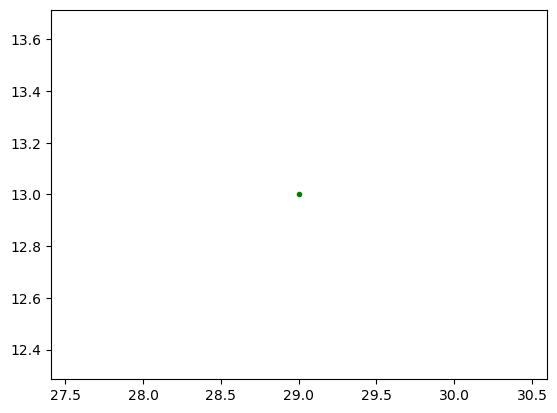

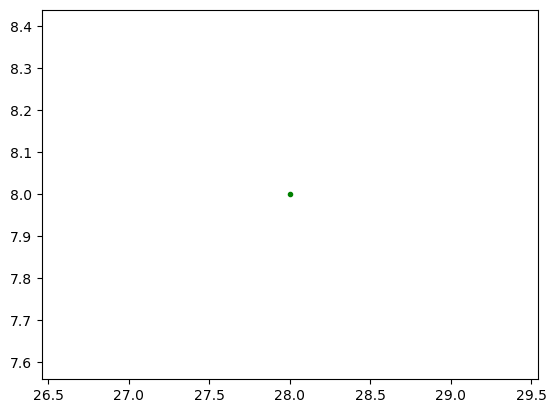

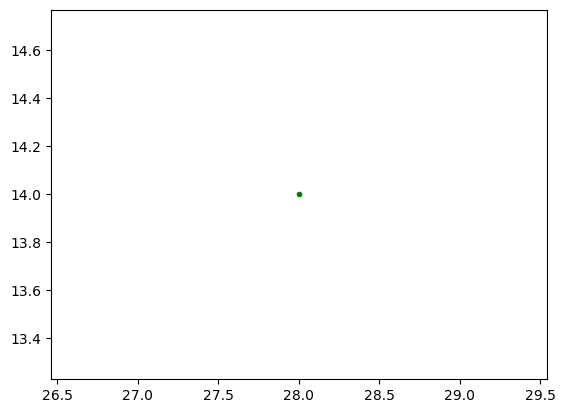

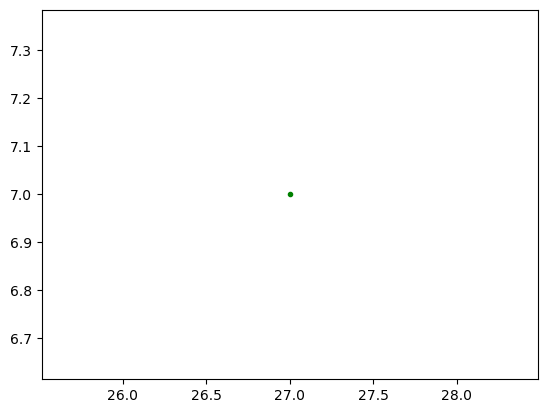

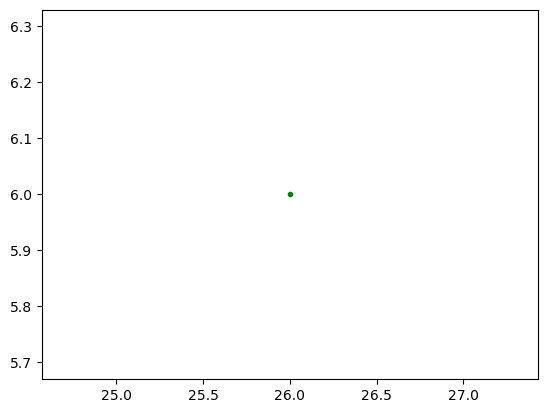

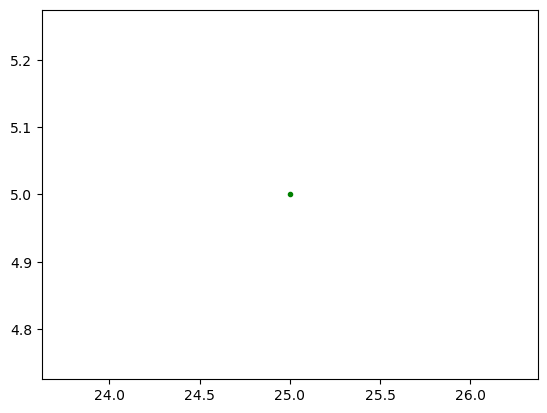

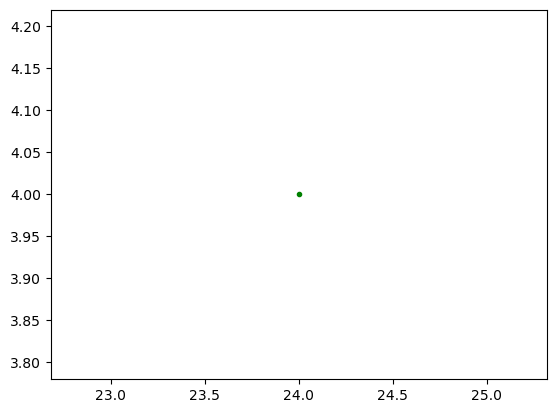

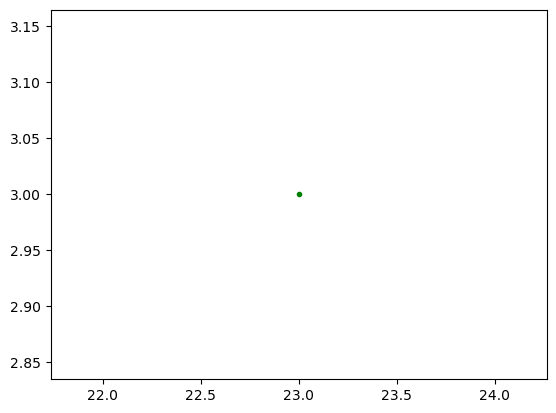

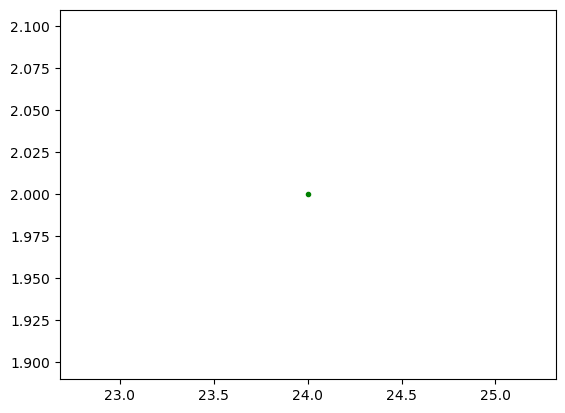

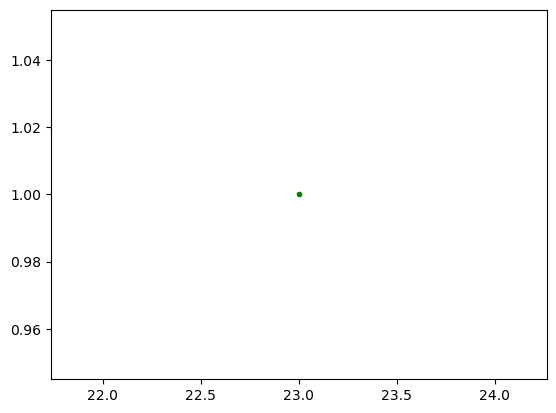

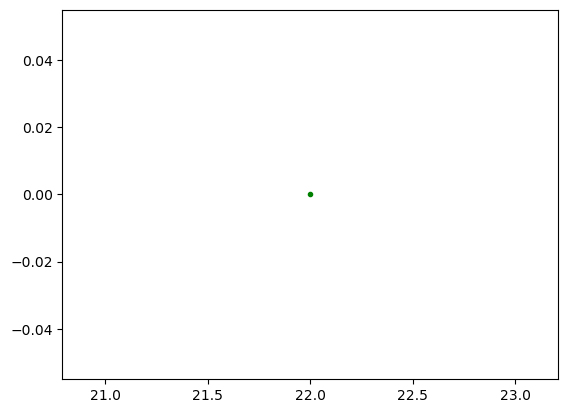

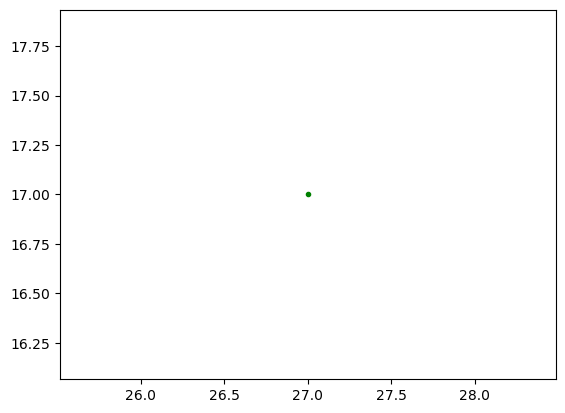

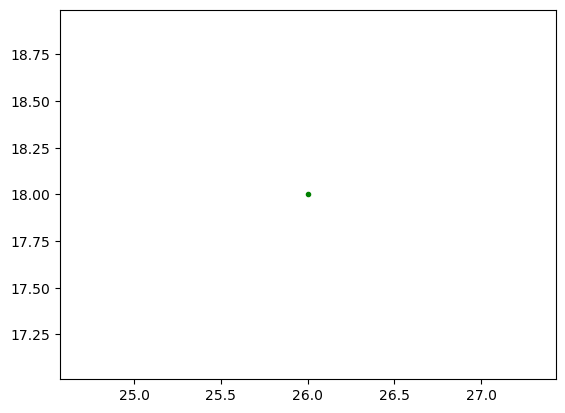

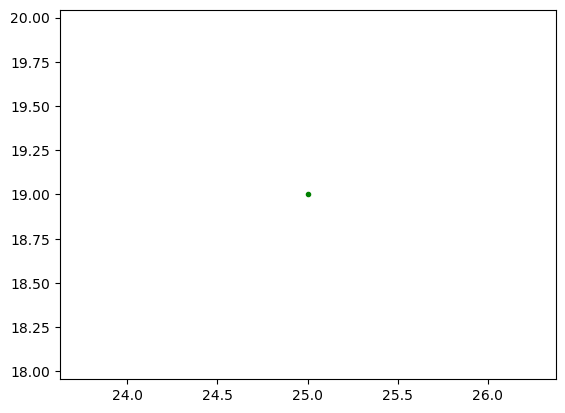

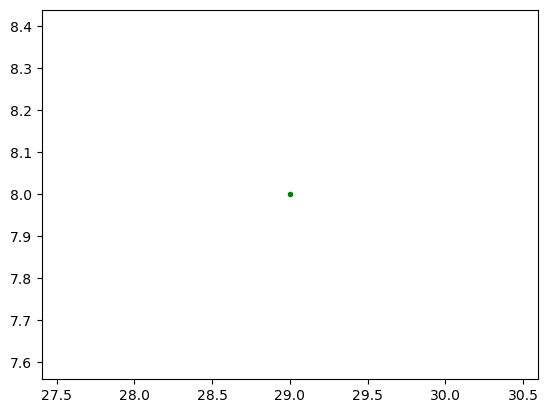

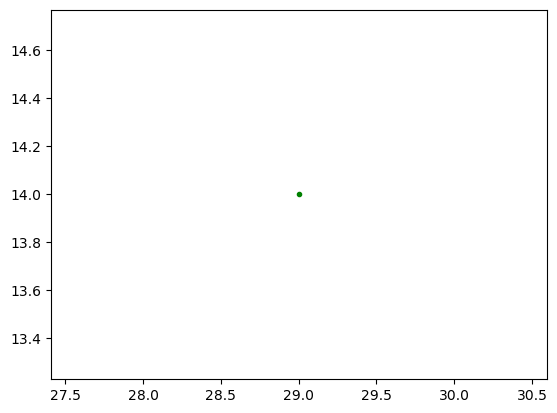

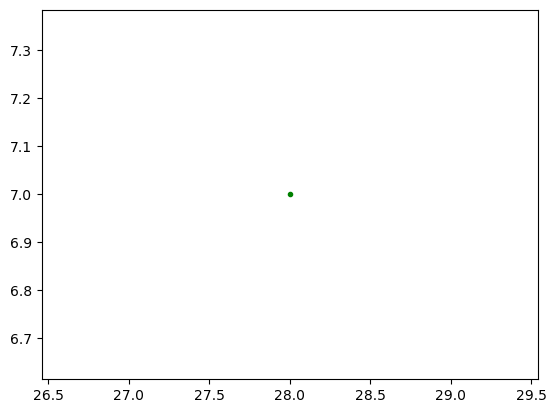

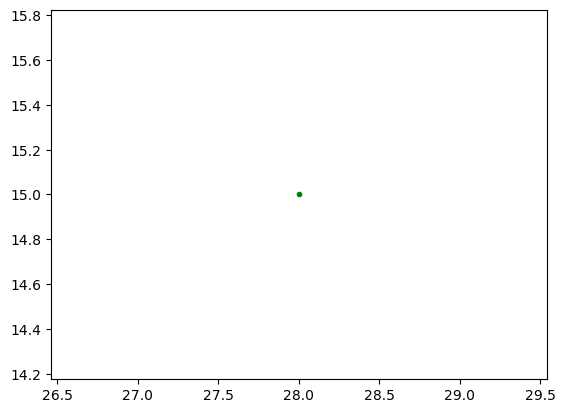

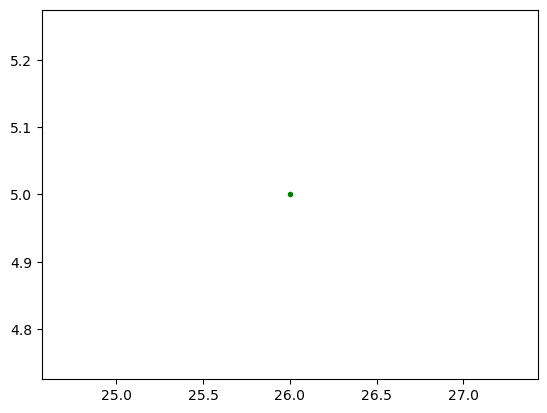

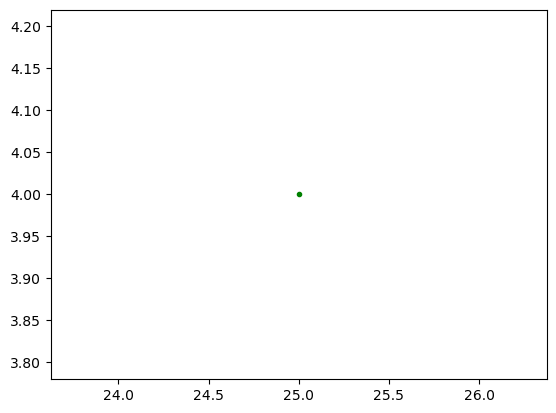

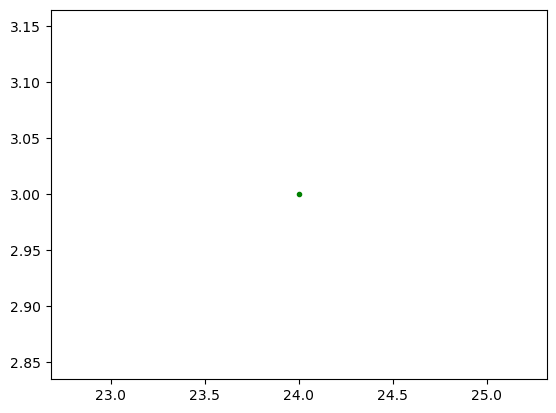

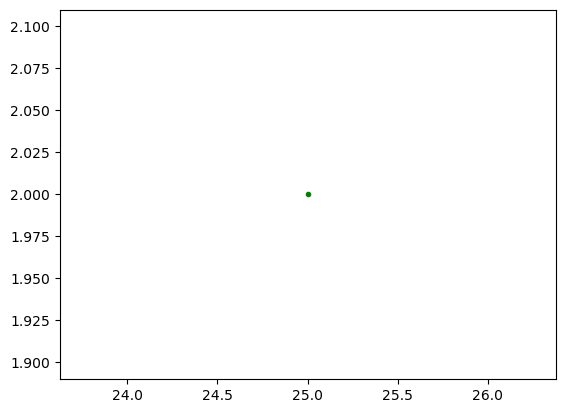

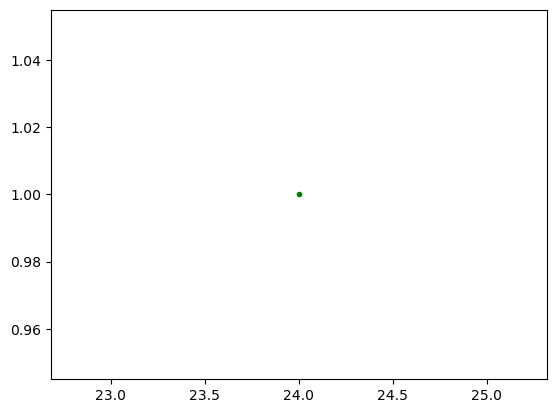

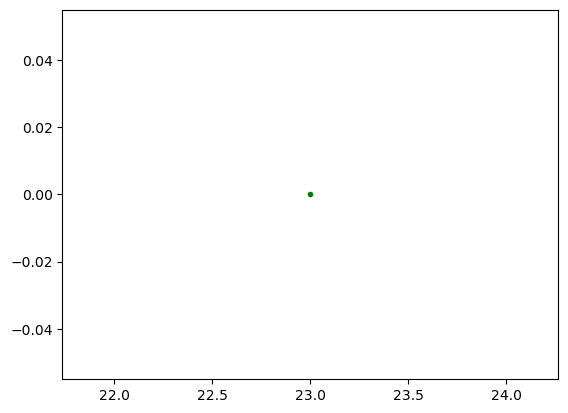

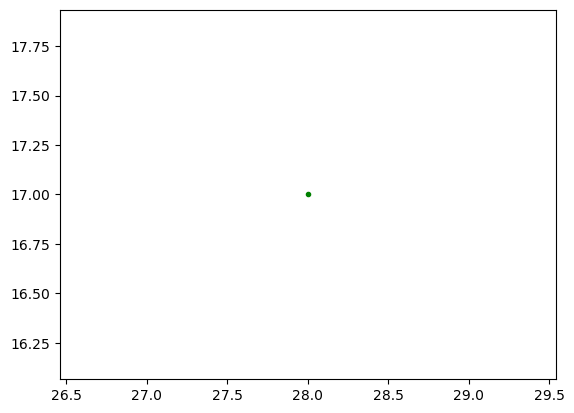

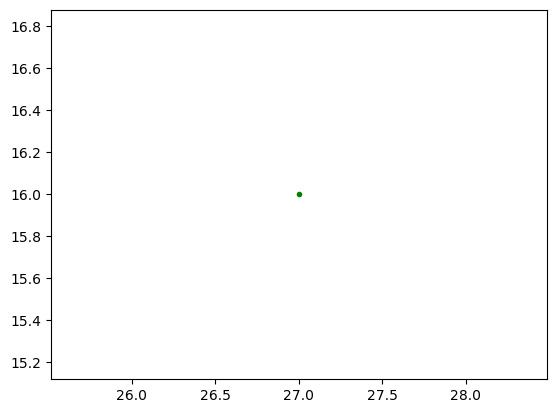

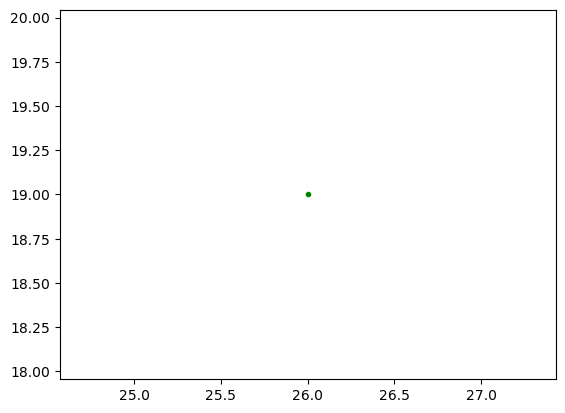

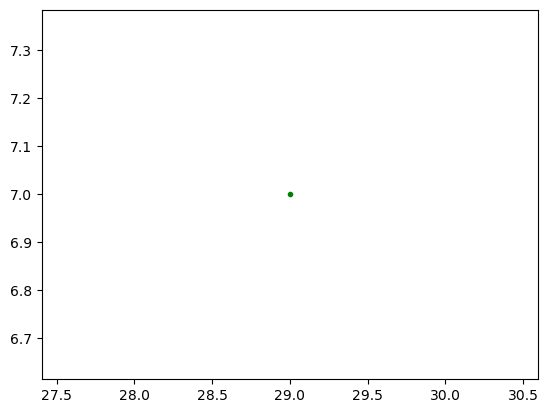

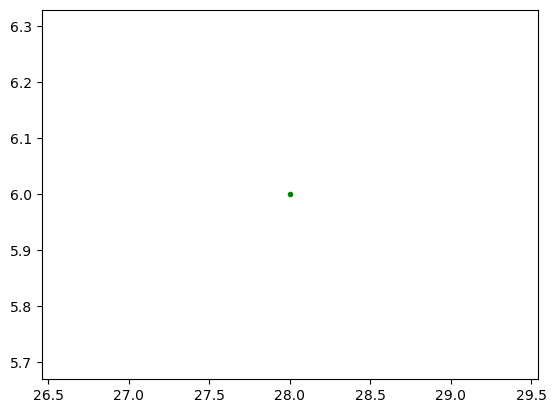

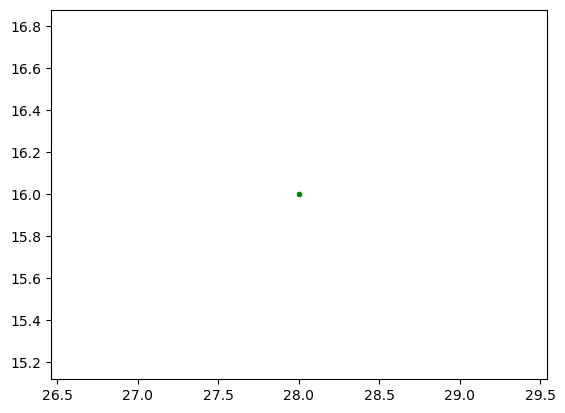

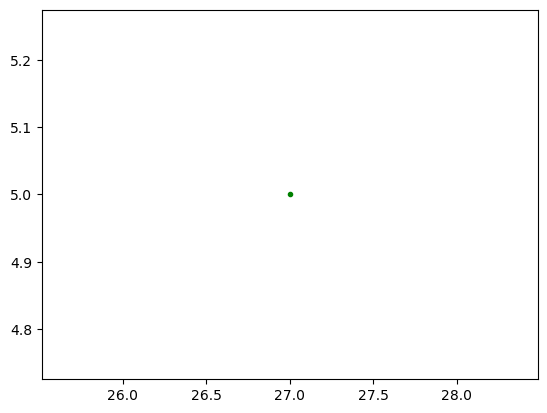

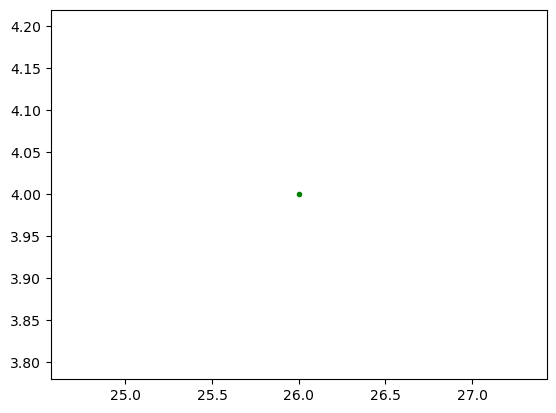

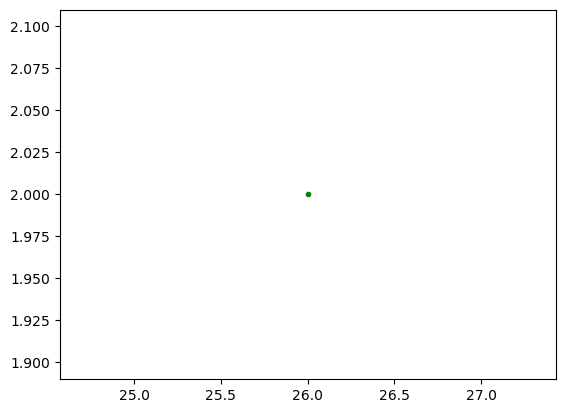

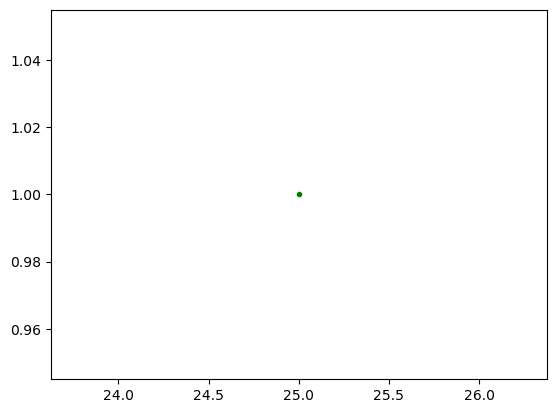

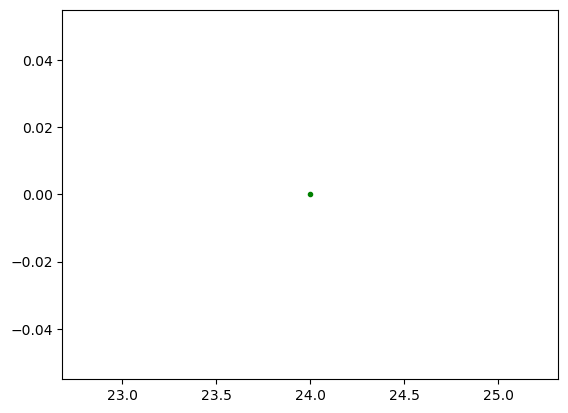

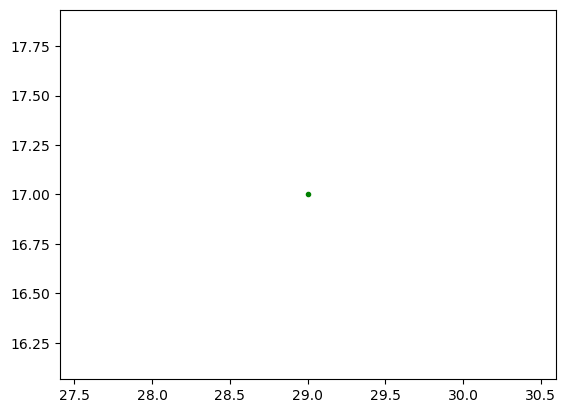

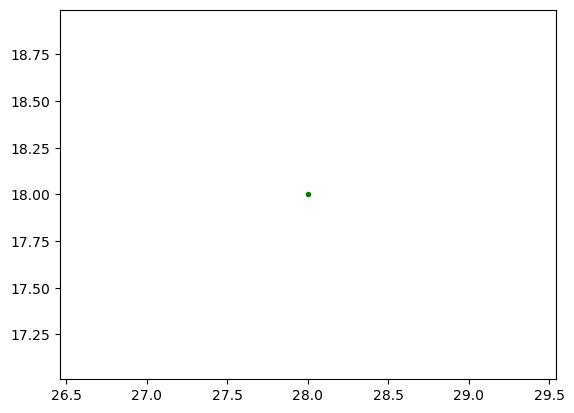

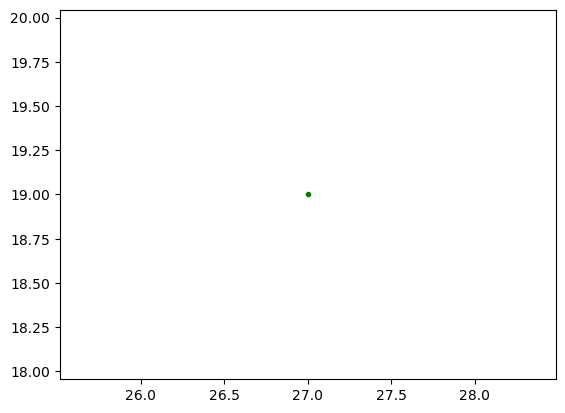

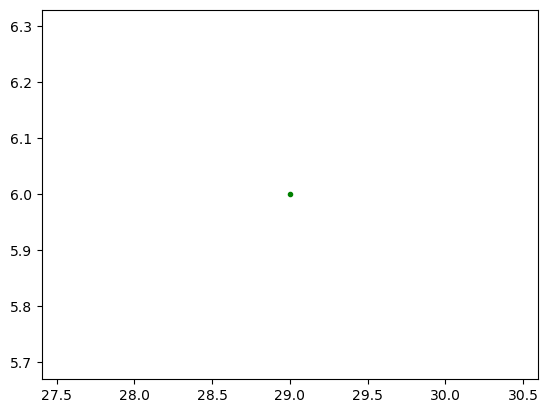

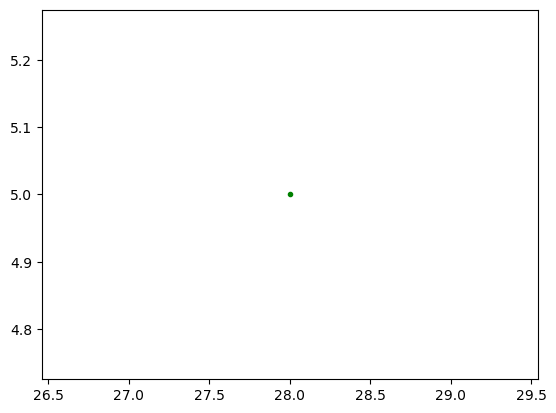

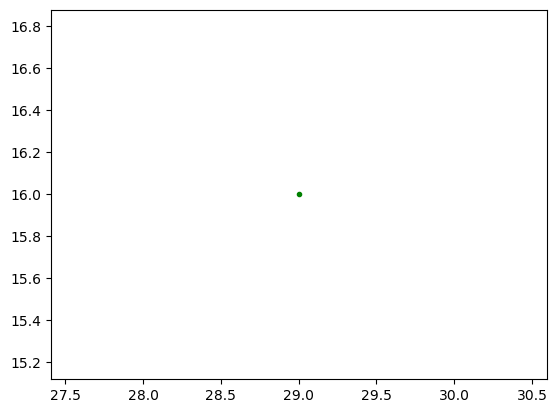

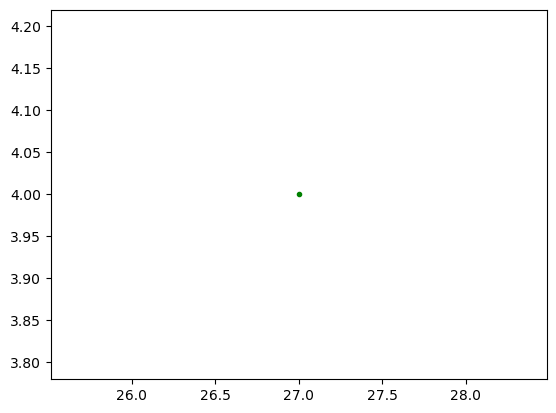

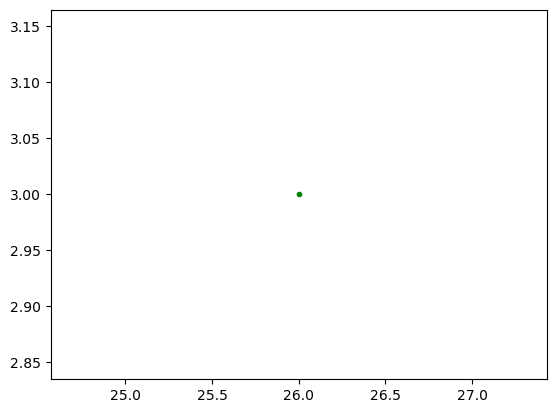

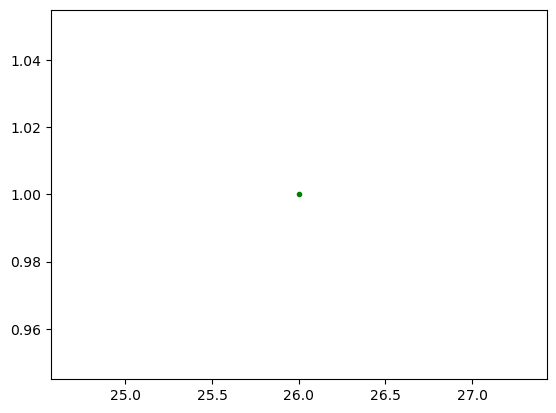

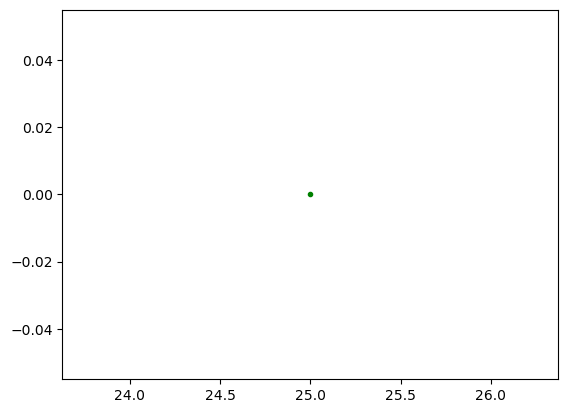

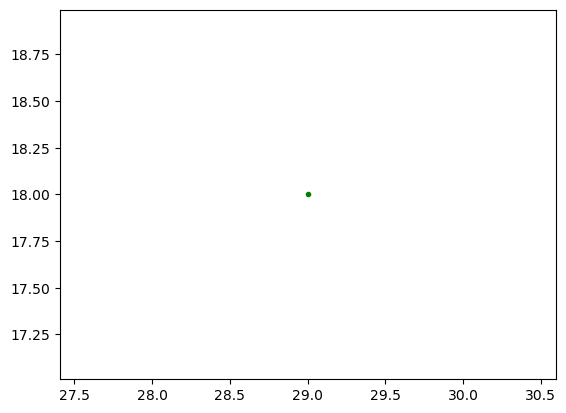

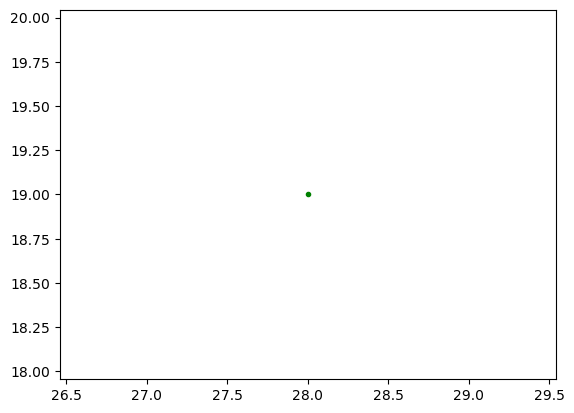

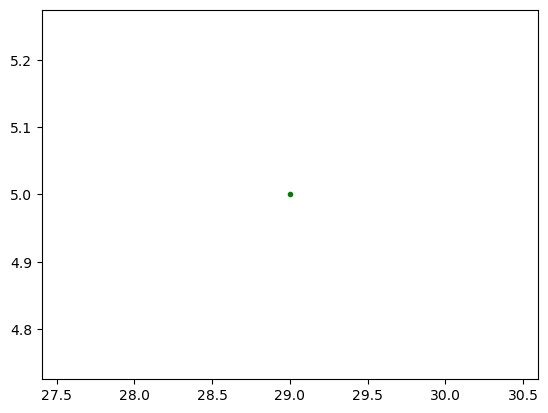

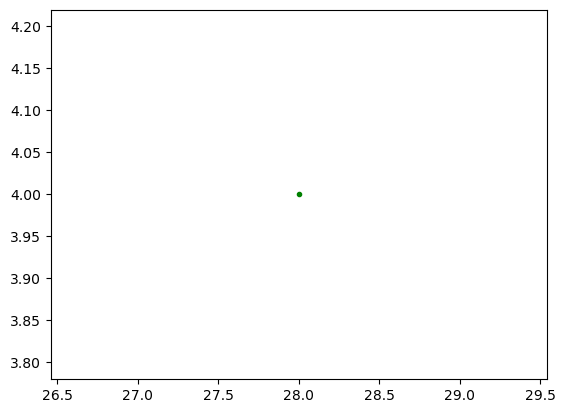

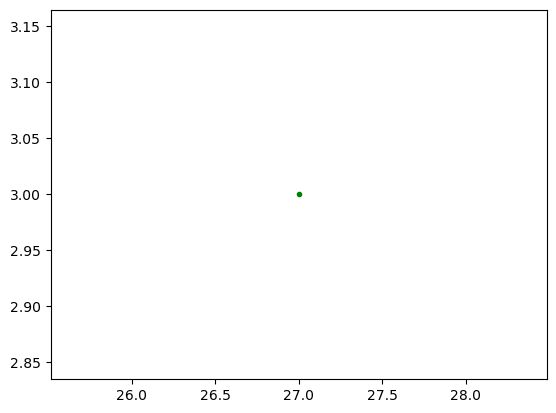

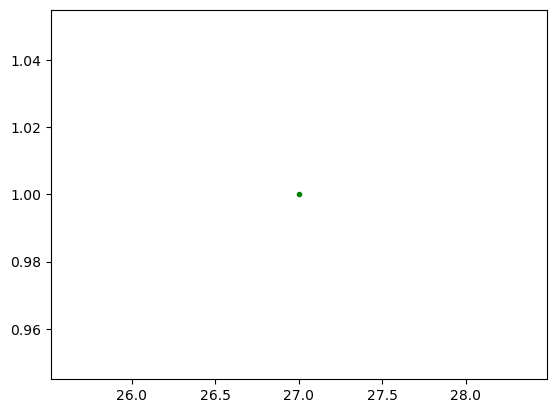

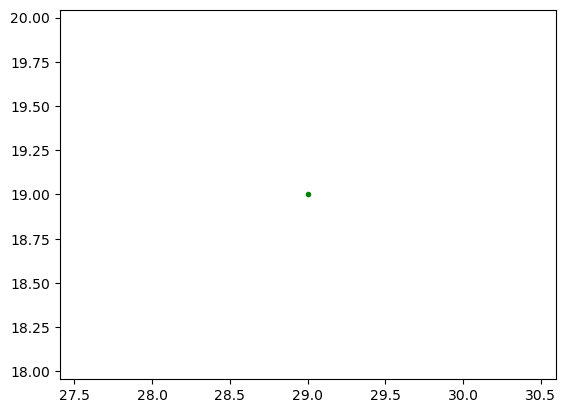

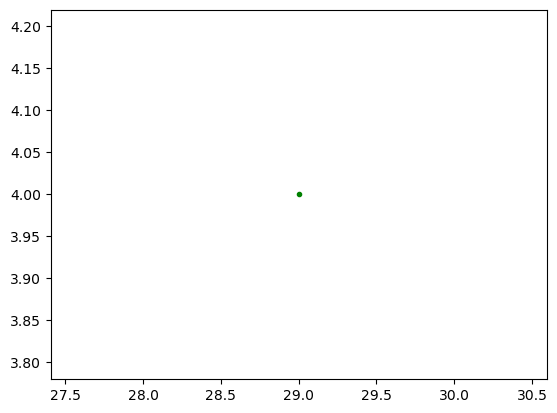

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# Generate a random 20x30 grid map with 10% occupancy
rows = 20
cols = 30
grid_map = np.random.rand(rows, cols) < 0.1

# Random start and goal points
start = (np.random.randint(0, rows), np.random.randint(0, cols))
goal = (np.random.randint(0, rows), np.random.randint(0, cols))

# Ensure start and goal are navigable
while grid_map[start] or grid_map[goal]:
    start = (np.random.randint(0, rows), np.random.randint(0, cols))
    goal = (np.random.randint(0, rows), np.random.randint(0, cols))

# Neighborhood function: Returns neighbors of a cell
def getNeighbors(pos):
    directions = [(0, 1), (0, -1), (-1, 0), (1, 0)]  # Right, Left, Up, Down
    neighbors = []
    for di, dj in directions:
        ni, nj = pos[0] + di, pos[1] + dj
        if 0 <= ni < rows and 0 <= nj < cols and not grid_map[ni, nj]:  # Check bounds and navigability
            neighbors.append((ni, nj))
    return neighbors

# BFS implementation
def bfs(grid_map, start, goal):
    queue = deque([start])  # Queue for BFS
    visited = set()  # Track visited nodes
    predecessors = {start: None}  # Store predecessors

    # Visualization setup
    plt.imshow(grid_map, cmap='gray')
    plt.ion()  # Interactive mode ON
    plt.plot(goal[1], goal[0], 'y*')  # Mark the goal
    plt.plot(start[1], start[0], 'b*')  # Mark the start

    while queue:
        current = queue.popleft()

        # Visualization: Show progress
        plt.plot(current[1], current[0], 'g.')
        plt.pause(0.000001)

        # Stop if we reach the goal
        if current == goal:
            break

        for neighbor in getNeighbors(current):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
                predecessors[neighbor] = current

    # Trace back the path
    path = []
    if goal in predecessors:  # If goal is reachable
        node = goal
        while node:
            path.append(node)
            node = predecessors[node]
        path.reverse()

        # Visualization: Color the shortest path in red
        for p in path:
            plt.plot(p[1], p[0], 'ro', markersize=5)  # 'ro' for red circles
        plt.pause(0.000001)  # Ensure the red path is updated in the plot
        plt.ioff()  # Turn OFF interactive mode
        plt.show()  # Show final result

    return path

# Run the BFS algorithm
path = bfs(grid_map, start, goal)

# Output the result
if path:
    print("Shortest path found:", path)
else:
    print("No path found between", start, "and", goal)
